## hisplot直方图

In [1]:
import seaborn as sns  # 导入 seaborn 库，用于高级数据可视化，基于 matplotlib
import matplotlib.pyplot as plt  # 导入 matplotlib.pyplot 模块，用于创建和自定义图表
import pandas as pd  # 导入 pandas 库，用于数据处理，提供 DataFrame 数据结构
import numpy as np  # 导入 numpy 库，用于数值计算和数组操作

# 设置中文显示和样式
plt.rcParams['axes.unicode_minus'] = False  # 确保负号在中文环境下正确显示，避免显示为方块
sns.set_style("whitegrid")  # 设置 seaborn 风格为 whitegrid，白色背景带网格线
plt.rcParams['font.family'] = ['Times New Roman',
                               'STSong']  # 设置字体为 Times New Roman 和宋体，支持中英文

# 加载数据集
penguins = sns.load_dataset('penguins').dropna()  # 加载企鹅数据集并删除缺失值，包含物种、岛屿、体重等
tips = sns.load_dataset('tips')  # 加载 tips 数据集，包含餐厅小费相关数据

print(f"数据集形状: {penguins.shape}")  # 打印企鹅数据集的行数和列数
print(f"\nHistplot特点: 直方图，展示数值分布")  # 说明 histplot 的功能，用于展示连续变量分布
print("适合连续型数值变量")  # 补充说明 histplot 适用于连续型数据的场景
print(
    f"\n体重分布范围: {penguins['body_mass_g'].min()} - {penguins['body_mass_g'].max()} g"
)  # 打印企鹅体重的最小值和最大值，单位为克

数据集形状: (333, 7)

Histplot特点: 直方图，展示数值分布
适合连续型数值变量

体重分布范围: 2700.0 - 6300.0 g


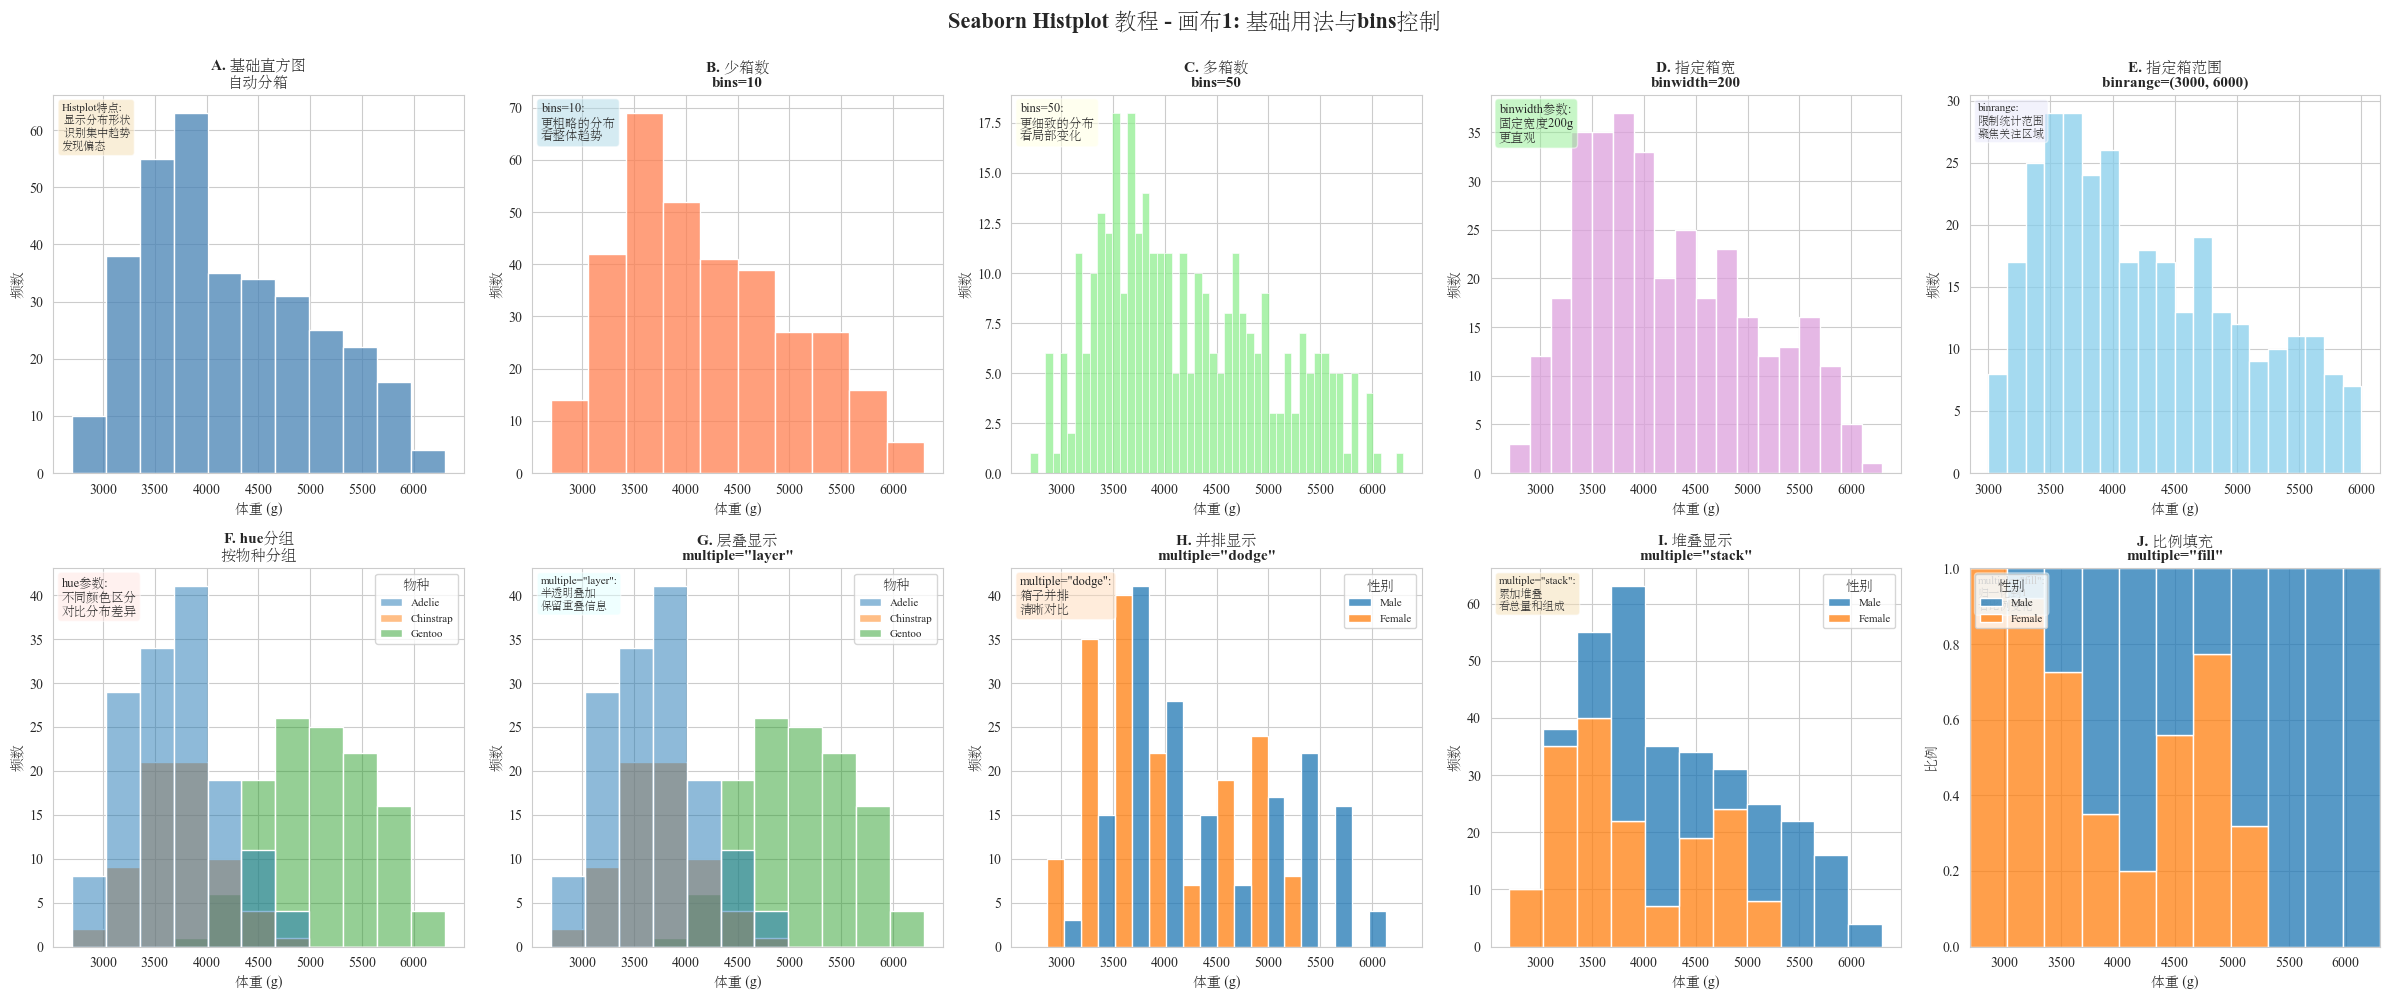

In [3]:
# ============================================================
# 画布 1: 基础用法和bins参数
# ============================================================
fig1, axes1 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2x5子图画布，设置尺寸为24x10英寸
fig1.suptitle('Seaborn Histplot 教程 - 画布1: 基础用法与bins控制',
              fontsize=16,
              fontweight='bold',
              y=0.995)  # 设置画布总标题，字体大小16，加粗，y轴位置0.995

# ========== 子图 A：最基础的直方图 ==========
ax = axes1[0, 0]  # 选择第1行第1列子图
sns.histplot(data=penguins, x='body_mass_g', ax=ax,
             color='steelblue')  # 绘制企鹅体重直方图，x轴为体重，颜色为钢蓝色
ax.set_title('A. 基础直方图\n自动分箱', fontsize=11,
             fontweight='bold')  # 设置子图标题，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签为“频数”，字体大小10
ax.text(0.02,
        0.98,
        'Histplot特点:\n 显示分布形状\n 识别集中趋势\n发现偏态',
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(
            boxstyle='round', facecolor='wheat',
            alpha=0.5))  # 在子图左上角添加文本框，描述histplot特点，相对坐标(0.02,0.98)，字体大小8，带圆角背景

# ========== 子图 B：调整bins数量 ==========
ax = axes1[0, 1]  # 选择第1行第2列子图
sns.histplot(data=penguins, x='body_mass_g', bins=10, ax=ax,
             color='coral')  # 绘制体重直方图，指定10个分箱，颜色为珊瑚色
ax.set_title('B. 少箱数\nbins=10', fontsize=11, fontweight='bold')  # 设置标题，展示少分箱效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签，字体大小10
ax.text(0.02,
        0.98,
        'bins=10:\n更粗略的分布\n看整体趋势',
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue',
                  alpha=0.5))  # 添加文本框，说明bins=10的粗略分布效果

# ========== 子图 C：更多bins ==========
ax = axes1[0, 2]  # 选择第1行第3列子图
sns.histplot(data=penguins,
             x='body_mass_g',
             bins=50,
             ax=ax,
             color='lightgreen')  # 绘制体重直方图，指定50个分箱，颜色为浅绿色
ax.set_title('C. 多箱数\nbins=50', fontsize=11, fontweight='bold')  # 设置标题，展示多分箱效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签，字体大小10
ax.text(0.02,
        0.98,
        'bins=50:\n更细致的分布\n看局部变化',
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow',
                  alpha=0.5))  # 添加文本框，说明bins=50的细致分布效果

# ========== 子图 D：binwidth指定箱宽 ==========
ax = axes1[0, 3]  # 选择第1行第4列子图
sns.histplot(data=penguins, x='body_mass_g', binwidth=200, ax=ax,
             color='plum')  # 绘制体重直方图，指定箱宽200g，颜色为梅紫色
ax.set_title('D. 指定箱宽\nbinwidth=200', fontsize=11,
             fontweight='bold')  # 设置标题，展示固定箱宽效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签，字体大小10
ax.text(0.02,
        0.98,
        'binwidth参数:\n固定宽度200g\n更直观',
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen',
                  alpha=0.5))  # 添加文本框，说明binwidth的直观效果

# ========== 子图 E：binrange指定范围 ==========
ax = axes1[0, 4]  # 选择第1行第5列子图
sns.histplot(data=penguins,
             x='body_mass_g',
             binrange=(3000, 6000),
             bins=20,
             ax=ax,
             color='skyblue')  # 绘制体重直方图，限制范围3000-6000g，分20箱，颜色为天蓝色
ax.set_title('E. 指定箱范围\nbinrange=(3000, 6000)', fontsize=11,
             fontweight='bold')  # 设置标题，展示范围限制效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签，字体大小10
ax.text(0.02,
        0.98,
        'binrange:\n限制统计范围\n聚焦关注区域',
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender',
                  alpha=0.5))  # 添加文本框，说明binrange聚焦效果

# ========== 子图 F：添加hue分组 ==========
ax = axes1[1, 0]  # 选择第2行第1列子图
sns.histplot(data=penguins, x='body_mass_g', hue='species',
             ax=ax)  # 按物种分组绘制体重直方图，自动分配颜色
ax.set_title('F. hue分组\n按物种分组', fontsize=11,
             fontweight='bold')  # 设置标题，展示hue分组效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签，字体大小10
sns.move_legend(ax, loc='upper right', fontsize=8,
                title='物种')  # 移动图例到右上角，设置字体大小和标题
ax.text(0.02,
        0.98,
        'hue参数:\n不同颜色区分\n对比分布差异',
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose',
                  alpha=0.5))  # 添加文本框，说明hue分组效果

# ========== 子图 G：multiple='layer' ==========
ax = axes1[1, 1]  # 选择第2行第2列子图
sns.histplot(data=penguins,
             x='body_mass_g',
             hue='species',
             multiple='layer',
             alpha=0.5,
             ax=ax)  # 按物种分组，层叠显示，透明度0.5
ax.set_title('G. 层叠显示\nmultiple="layer"', fontsize=11,
             fontweight='bold')  # 设置标题，展示层叠效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签，字体大小10
sns.move_legend(ax, loc='upper right', fontsize=8,
                title='物种')  # 移动图例到右上角，设置字体大小和标题
ax.text(0.02,
        0.98,
        'multiple="layer":\n半透明叠加\n保留重叠信息',
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan',
                  alpha=0.5))  # 添加文本框，说明层叠显示效果

# ========== 子图 H：multiple='dodge' ==========
ax = axes1[1, 2]  # 选择第2行第3列子图
sns.histplot(data=penguins,
             x='body_mass_g',
             hue='sex',
             multiple='dodge',
             ax=ax)  # 按性别分组，并排显示直方图
ax.set_title('H. 并排显示\nmultiple="dodge"', fontsize=11,
             fontweight='bold')  # 设置标题，展示并排效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签，字体大小10
sns.move_legend(ax, loc='upper right', fontsize=8,
                title='性别')  # 移动图例到右上角，设置字体大小和标题
ax.text(0.02,
        0.98,
        'multiple="dodge":\n箱子并排\n清晰对比',
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff',
                  alpha=0.5))  # 添加文本框，说明并排显示效果

# ========== 子图 I：multiple='stack' ==========
ax = axes1[1, 3]  # 选择第2行第4列子图
sns.histplot(data=penguins,
             x='body_mass_g',
             hue='sex',
             multiple='stack',
             ax=ax)  # 按性别分组，堆叠显示直方图
ax.set_title('I. 堆叠显示\nmultiple="stack"', fontsize=11,
             fontweight='bold')  # 设置标题，展示堆叠效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签，字体大小10
sns.move_legend(ax, loc='upper right', fontsize=8,
                title='性别')  # 移动图例到右上角，设置字体大小和标题
ax.text(0.02,
        0.98,
        'multiple="stack":\n累加堆叠\n看总量和组成',
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat',
                  alpha=0.5))  # 添加文本框，说明堆叠显示效果

# ========== 子图 J：multiple='fill' ==========
ax = axes1[1, 4]  # 选择第2行第5列子图
sns.histplot(data=penguins, x='body_mass_g', hue='sex', multiple='fill',
             ax=ax)  # 按性别分组，比例填充显示，y轴为比例
ax.set_title('J. 比例填充\nmultiple="fill"', fontsize=11,
             fontweight='bold')  # 设置标题，展示比例填充效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('比例', fontsize=10)  # 设置y轴标签为“比例”，字体大小10
sns.move_legend(ax, loc='upper left', fontsize=8,
                title='性别')  # 移动图例到左上角，设置字体大小和标题
ax.text(0.02,
        0.98,
        'multiple="fill":\n归一化到1\n看比例变化',
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue',
                  alpha=0.5))  # 添加文本框，说明比例填充效果

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示整个画布

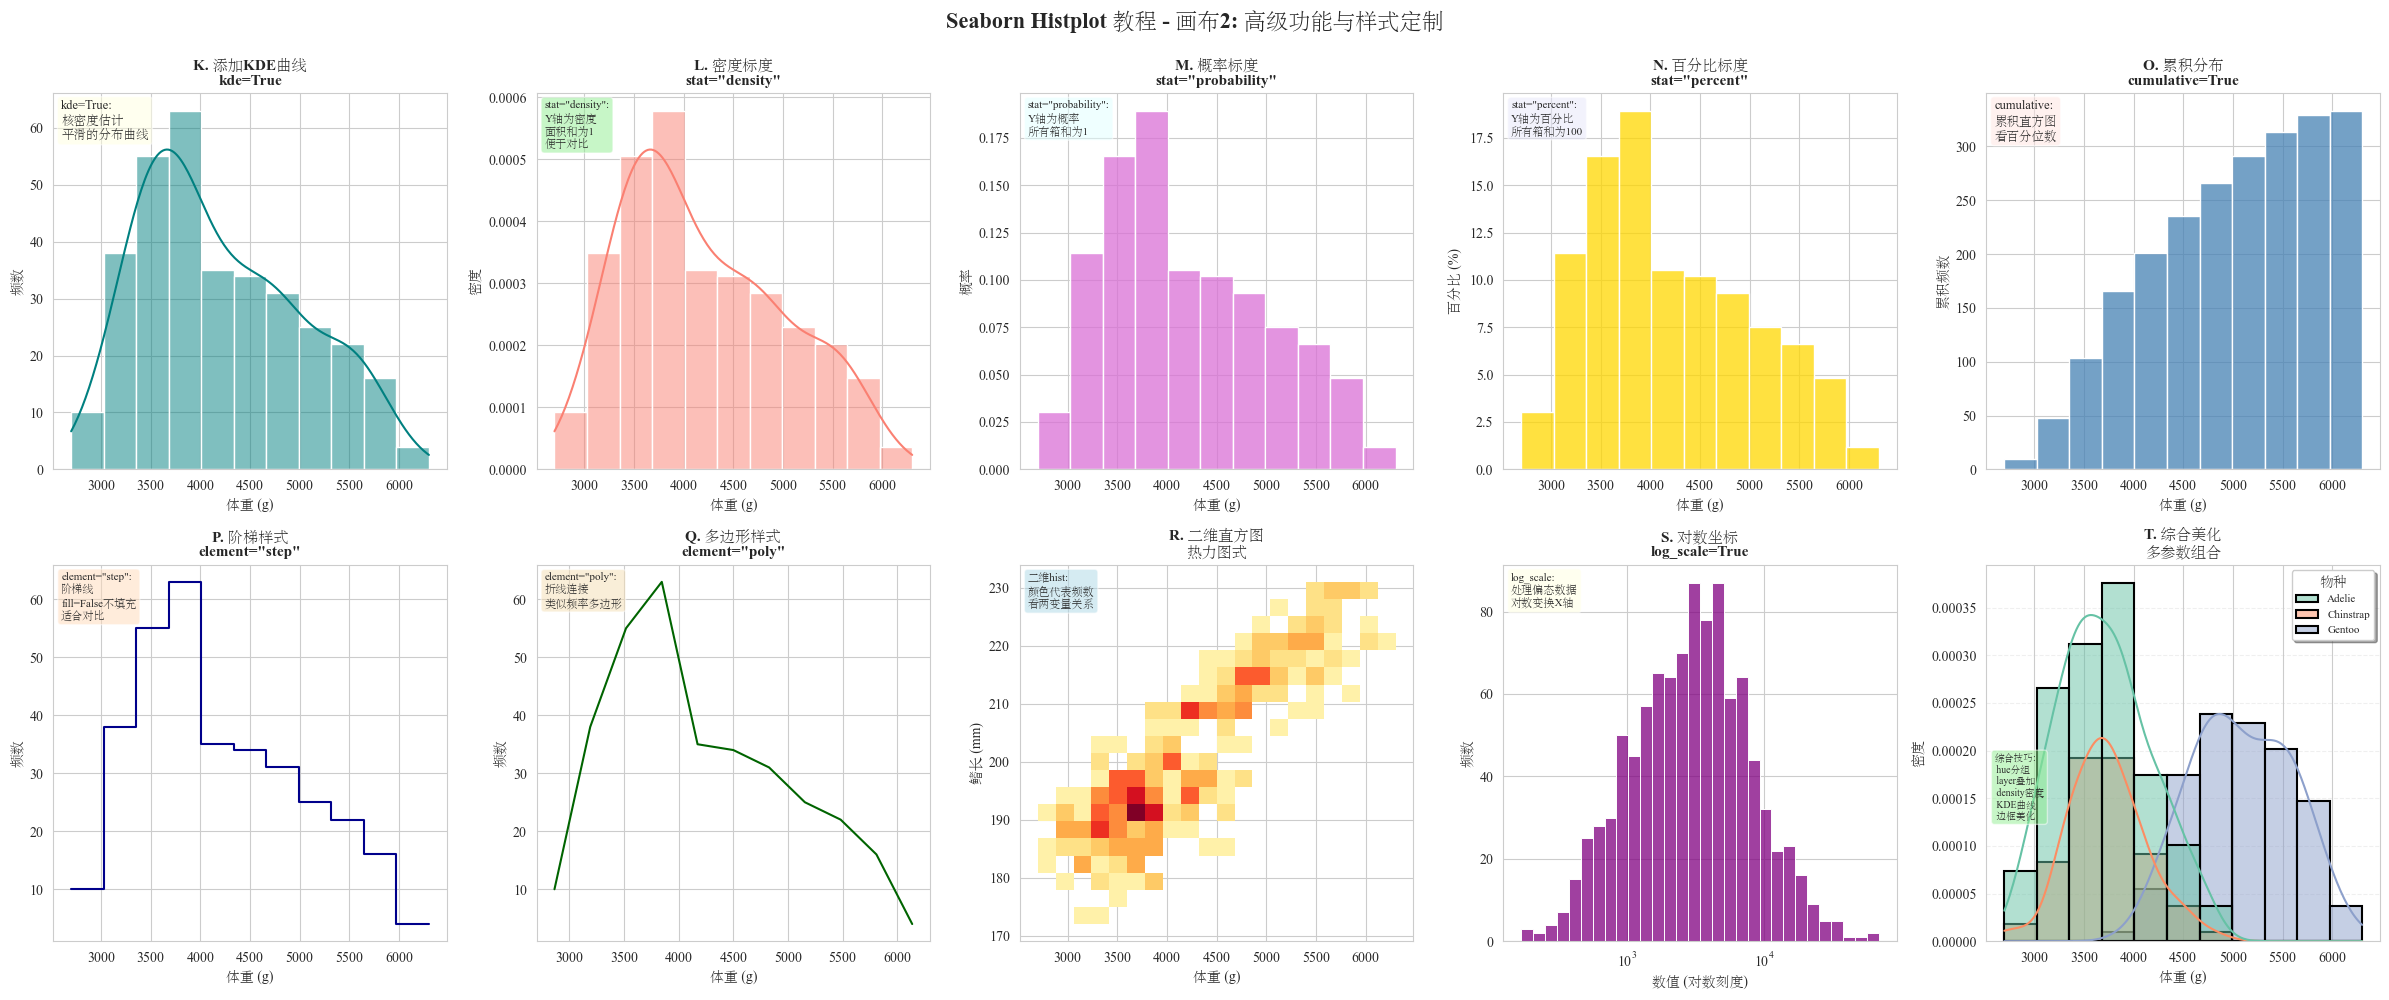

In [4]:
# ============================================================
# 画布 2: 高级功能和样式定制
# ============================================================
fig2, axes2 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2x5子图画布，设置尺寸为24x10英寸
fig2.suptitle('Seaborn Histplot 教程 - 画布2: 高级功能与样式定制',  # 设置画布总标题，展示高级功能
              fontsize=16,  # 标题字体大小16
              fontweight='bold',  # 标题加粗
              y=0.995)  # 标题y轴位置调整到0.995

# ========== 子图 K：添加KDE曲线 ==========
ax = axes2[0, 0]  # 选择第1行第1列子图
sns.histplot(data=penguins, x='body_mass_g', kde=True, ax=ax, color='teal')  # 绘制体重直方图，kde=True添加核密度估计曲线，颜色为青色
ax.set_title('K. 添加KDE曲线\nkde=True', fontsize=11, fontweight='bold')  # 设置标题，展示KDE曲线效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签为“频数”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，相对坐标x=0.02
        0.98,  # 文本框y坐标为0.98，顶部对齐
        'kde=True:\n核密度估计\n平滑的分布曲线',  # 说明kde参数添加平滑曲线效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 文本字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5

# ========== 子图 L：stat='density' ==========
ax = axes2[0, 1]  # 选择第1行第2列子图
sns.histplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             stat='density',  # y轴显示密度，面积和为1
             kde=True,  # 添加核密度估计曲线
             ax=ax,  # 指定子图
             color='salmon')  # 设置颜色为鲑鱼色
ax.set_title('L. 密度标度\nstat="density"', fontsize=11, fontweight='bold')  # 设置标题，展示密度标度效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框
        0.98,  # 顶部对齐
        'stat="density":\nY轴为密度\n面积和为1\n便于对比',  # 说明stat=density的面积归一化效果
        transform=ax.transAxes,  # 使用子图相对坐标
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 圆角背景框，浅绿色，透明度0.5

# ========== 子图 M：stat='probability' ==========
ax = axes2[0, 2]  # 选择第1行第3列子图
sns.histplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             stat='probability',  # y轴显示概率，所有箱和为1
             ax=ax,  # 指定子图
             color='orchid')  # 设置颜色为兰花紫
ax.set_title('M. 概率标度\nstat="probability"', fontsize=11, fontweight='bold')  # 设置标题，展示概率标度效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('概率', fontsize=10)  # 设置y轴标签为“概率”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框
        0.98,  # 顶部对齐
        'stat="probability":\nY轴为概率\n所有箱和为1',  # 说明stat=probability的概率归一化效果
        transform=ax.transAxes,  # 使用子图相对坐标
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 圆角背景框，浅青色，透明度0.5

# ========== 子图 N：stat='percent' ==========
ax = axes2[0, 3]  # 选择第1行第4列子图
sns.histplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             stat='percent',  # y轴显示百分比，所有箱和为100
             ax=ax,  # 指定子图
             color='gold')  # 设置颜色为金色
ax.set_title('N. 百分比标度\nstat="percent"', fontsize=11, fontweight='bold')  # 设置标题，展示百分比标度效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('百分比 (%)', fontsize=10)  # 设置y轴标签为“百分比 (%)”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框
        0.98,  # 顶部对齐
        'stat="percent":\nY轴为百分比\n所有箱和为100',  # 说明stat=percent的百分比归一化效果
        transform=ax.transAxes,  # 使用子图相对坐标
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 圆角背景框，淡紫色，透明度0.5

# ========== 子图 O：cumulative累积分布 ==========
ax = axes2[0, 4]  # 选择第1行第5列子图
sns.histplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             cumulative=True,  # 绘制累积直方图
             ax=ax,  # 指定子图
             color='steelblue')  # 设置颜色为钢蓝色
ax.set_title('O. 累积分布\ncumulative=True', fontsize=11, fontweight='bold')  # 设置标题，展示累积分布效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('累积频数', fontsize=10)  # 设置y轴标签为“累积频数”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框
        0.98,  # 顶部对齐
        'cumulative:\n累积直方图\n看百分位数',  # 说明cumulative=True的累积分布效果
        transform=ax.transAxes,  # 使用子图相对坐标
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 圆角背景框，薄雾玫瑰色，透明度0.5

# ========== 子图 P：element='step' ==========
ax = axes2[1, 0]  # 选择第2行第1列子图
sns.histplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             element='step',  # 使用阶梯样式绘制直方图
             fill=False,  # 不填充直方图区域
             ax=ax,  # 指定子图
             color='darkblue')  # 设置颜色为深蓝色
ax.set_title('P. 阶梯样式\nelement="step"', fontsize=11, fontweight='bold')  # 设置标题，展示阶梯样式效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签为“频数”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框
        0.98,  # 顶部对齐
        'element="step":\n阶梯线\nfill=False不填充\n适合对比',  # 说明element=step的阶梯线效果
        transform=ax.transAxes,  # 使用子图相对坐标
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 圆角背景框，桃色，透明度0.5

# ========== 子图 Q：element='poly' ==========
ax = axes2[1, 1]  # 选择第2行第2列子图
sns.histplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             element='poly',  # 使用多边形样式绘制直方图
             fill=False,  # 不填充直方图区域
             ax=ax,  # 指定子图
             color='darkgreen')  # 设置颜色为深绿色
ax.set_title('Q. 多边形样式\nelement="poly"', fontsize=11, fontweight='bold')  # 设置标题，展示多边形样式效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签为“频数”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框
        0.98,  # 顶部对齐
        'element="poly":\n折线连接\n类似频率多边形',  # 说明element=poly的折线效果
        transform=ax.transAxes,  # 使用子图相对坐标
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角背景框，小麦色，透明度0.5

# ========== 子图 R：二维直方图 ==========
ax = axes2[1, 2]  # 选择第2行第3列子图
sns.histplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             y='flipper_length_mm',  # y轴为鳍长，绘制二维直方图
             bins=20,  # 设置20个分箱
             cmap='YlOrRd',  # 使用黄橙红渐变色图
             ax=ax)  # 指定子图
ax.set_title('R. 二维直方图\n热力图式', fontsize=11, fontweight='bold')  # 设置标题，展示二维直方图效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # 设置y轴标签为“鳍长 (mm)”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框
        0.98,  # 顶部对齐
        '二维hist:\n颜色代表频数\n看两变量关系',  # 说明二维直方图显示变量关系
        transform=ax.transAxes,  # 使用子图相对坐标
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5

# ========== 子图 S：log_scale对数坐标 ==========
ax = axes2[1, 3]  # 选择第2行第4列子图
# 创建一些有偏态的数据
skewed_data = np.random.lognormal(mean=8, sigma=1, size=1000)  # 生成1000个对数正态分布的偏态数据，均值8，标准差1
sns.histplot(x=skewed_data, log_scale=True, bins=30, ax=ax, color='purple')  # 绘制偏态数据直方图，x轴对数刻度，分30箱，颜色为紫色
ax.set_title('S. 对数坐标\nlog_scale=True', fontsize=11, fontweight='bold')  # 设置标题，展示对数坐标效果
ax.set_xlabel('数值 (对数刻度)', fontsize=10)  # 设置x轴标签为“数值 (对数刻度)”，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签为“频数”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框
        0.98,  # 顶部对齐
        'log_scale:\n处理偏态数据\n对数变换X轴',  # 说明log_scale处理偏态数据的效果
        transform=ax.transAxes,  # 使用子图相对坐标
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5

# ========== 子图 T：综合美化案例 ==========
ax = axes2[1, 4]  # 选择第2行第5列子图
sns.histplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             hue='species',  # 按物种分组，自动分配颜色
             multiple='layer',  # 层叠显示分组直方图
             stat='density',  # y轴显示密度，面积和为1
             kde=True,  # 添加核密度估计曲线
             palette='Set2',  # 使用Set2调色板
             alpha=0.5,  # 设置透明度0.5
             edgecolor='black',  # 设置直方图边框为黑色
             linewidth=1.5,  # 设置边框线宽1.5
             ax=ax)  # 指定子图
ax.set_title('T. 综合美化\n多参数组合', fontsize=11, fontweight='bold')  # 设置标题，展示综合美化效果
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
sns.move_legend(ax,  # 调整图例位置
                loc='upper right',  # 图例放在右上角
                fontsize=8,  # 图例字体大小8
                title='物种',  # 图例标题为“物种”
                frameon=True,  # 显示图例边框
                fancybox=True,  # 使用圆角边框
                shadow=True)  # 添加图例阴影
ax.grid(axis='y', alpha=0.3, linestyle='--')  # 添加y轴网格线，透明度0.3，虚线样式
ax.text(0.02,  # 在子图左中部添加文本框
        0.50,  # y坐标为0.50，顶部对齐
        '综合技巧:\n hue分组\n layer叠加\n density密度\n KDE曲线\n 边框美化',  # 说明综合美化参数组合
        transform=ax.transAxes,  # 使用子图相对坐标
        fontsize=7,  # 字体大小7
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 圆角背景框，浅绿色，透明度0.5

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示整个画布


额外演示: discrete参数处理离散数据


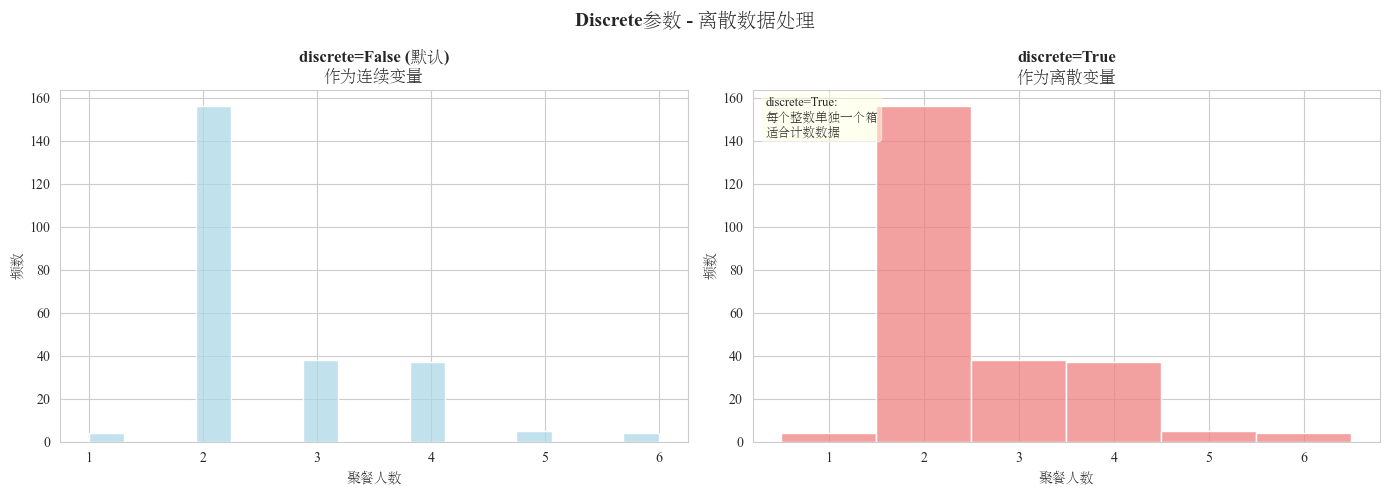

In [5]:
# ============================================================
# 额外演示：discrete离散数据
# ============================================================
print("\n" + "=" * 60)  # 打印60个等号作为分隔线，前面加换行符
print("额外演示: discrete参数处理离散数据")  # 打印说明，介绍discrete参数用于离散数据
print("=" * 60)  # 打印60个等号作为分隔线

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))  # 创建1x2子图画布，尺寸为14x5英寸
fig3.suptitle('Discrete参数 - 离散数据处理', fontsize=14, fontweight='bold')  # 设置画布总标题，字体大小14，加粗

# 左图：连续处理（默认）
ax = axes3[0]  # 选择第1个子图（左图）
sns.histplot(data=tips, x='size', ax=ax, color='lightblue')  # 绘制tips数据集的聚餐人数直方图，默认连续处理，颜色为浅蓝色
ax.set_title('discrete=False (默认)\n作为连续变量', fontsize=12, fontweight='bold')  # 设置标题，说明默认continuous处理，字体大小12，加粗
ax.set_xlabel('聚餐人数', fontsize=10)  # 设置x轴标签为“聚餐人数”，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签为“频数”，字体大小10

# 右图：离散处理
ax = axes3[1]  # 选择第2个子图（右图）
sns.histplot(data=tips, x='size', discrete=True, ax=ax, color='lightcoral')  # 绘制聚餐人数直方图，discrete=True按离散值分箱，颜色为浅珊瑚色
ax.set_title('discrete=True\n作为离散变量', fontsize=12, fontweight='bold')  # 设置标题，说明离散处理效果，字体大小12，加粗
ax.set_xlabel('聚餐人数', fontsize=10)  # 设置x轴标签为“聚餐人数”，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签为“频数”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'discrete=True:\n每个整数单独一个箱\n适合计数数据',  # 说明discrete=True的离散分箱效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示整个画布


Histplot vs KDE 对比


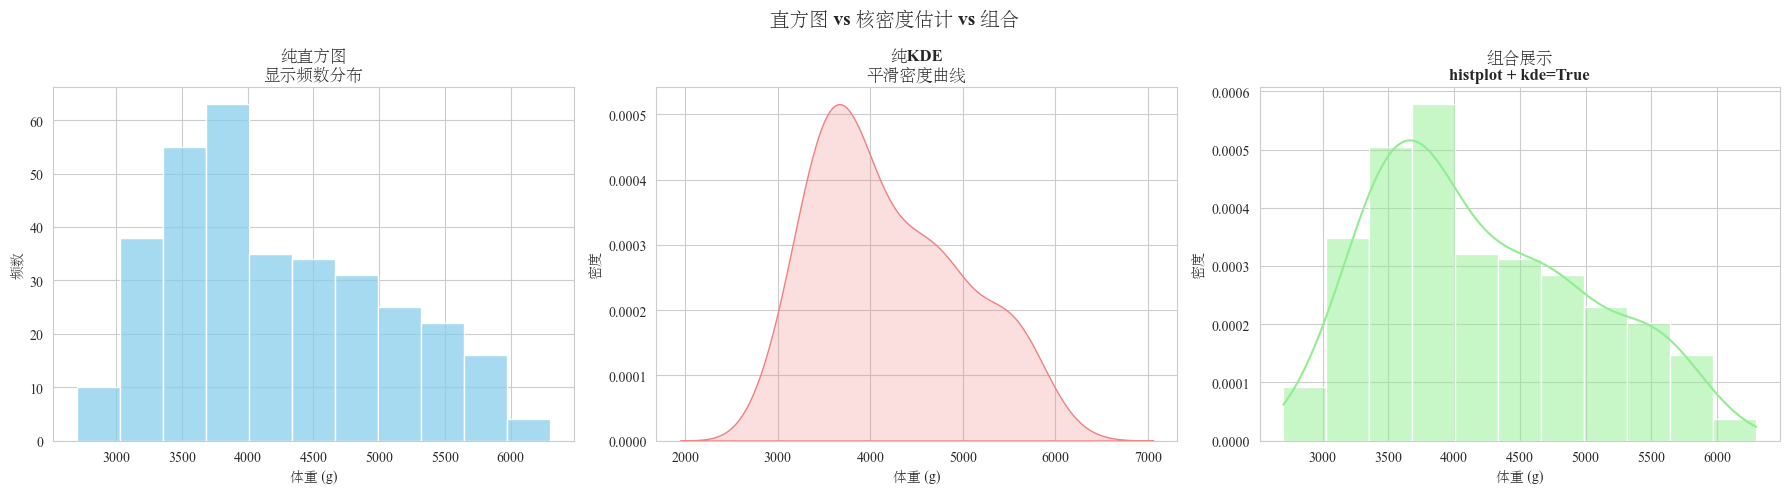

In [6]:
# ============================================================
# Histplot vs KDE对比
# ============================================================
print("\n" + "=" * 60)  # 打印60个等号作为分隔线，前面加换行符
print("Histplot vs KDE 对比")  # 打印说明，介绍直方图与核密度估计的对比
print("=" * 60)  # 打印60个等号作为分隔线

fig4, axes4 = plt.subplots(1, 3, figsize=(18, 5))  # 创建1x3子图画布，尺寸为18x5英寸
fig4.suptitle('直方图 vs 核密度估计 vs 组合', fontsize=14, fontweight='bold')  # 设置画布总标题，字体大小14，加粗

# 纯直方图
ax = axes4[0]  # 选择第1个子图（左图）
sns.histplot(data=penguins, x='body_mass_g', ax=ax, color='skyblue')  # 绘制企鹅体重直方图，默认频数统计，颜色为天蓝色
ax.set_title('纯直方图\n显示频数分布', fontsize=12, fontweight='bold')  # 设置标题，说明纯直方图显示频数，字体大小12，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签为“频数”，字体大小10

# 纯KDE
ax = axes4[1]  # 选择第2个子图（中图）
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            fill=True,  # 填充核密度曲线下的区域
            ax=ax,  # 指定子图
            color='lightcoral')  # 设置颜色为浅珊瑚色
ax.set_title('纯KDE\n平滑密度曲线', fontsize=12, fontweight='bold')  # 设置标题，说明纯KDE显示平滑密度，字体大小12，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10

# 组合
ax = axes4[2]  # 选择第3个子图（右图）
sns.histplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             stat='density',  # y轴显示密度，面积和为1
             kde=True,  # 添加核密度估计曲线
             ax=ax,  # 指定子图
             color='lightgreen')  # 设置颜色为浅绿色
ax.set_title('组合展示\nhistplot + kde=True', fontsize=12, fontweight='bold')  # 设置标题，说明直方图与KDE组合，字体大小12，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示整个画布

In [7]:
# ============================================================
# 打印重要参数总结
# ============================================================
print("\n" + "="*60)
print("Seaborn histplot 核心参数总结 (v0.13.2+)")
print("="*60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x: 数值变量(必需)
   - y: 第二个数值变量(可选，创建二维直方图)
   - hue: 分组变量

2. 分箱控制: ⭐⭐⭐
   - bins: 箱数量
     * 整数: 具体箱数
     * 'auto', 'sturges', 'fd', 'scott': 自动算法
   - binwidth: 箱宽度(与bins互斥)
   - binrange: 箱范围 (min, max)
   - discrete: 离散数据处理(True/False)

3. 统计类型: ⭐⭐⭐
   - stat: Y轴统计量
     * 'count': 频数(默认)
     * 'frequency': 频率
     * 'probability': 概率(和为1)
     * 'percent': 百分比(和为100)
     * 'density': 密度(面积为1)

4. 多组处理: ⭐⭐⭐
   - multiple: 多个hue组的处理方式
     * 'layer': 层叠(默认)
     * 'dodge': 并排
     * 'stack': 堆叠
     * 'fill': 比例填充

5. 累积分布:
   - cumulative: 累积分布(True/False)
   - element: 显示元素
     * 'bars': 柱状(默认)
     * 'step': 阶梯线
     * 'poly': 多边形

6. 密度估计:
   - kde: 添加核密度曲线(True/False)
   - kde_kws: KDE参数字典

7. 样式参数:
   - color: 单一颜色
   - palette: 调色板(配合hue)
   - fill: 是否填充(True/False)
   - alpha: 透明度(0-1)
   - edgecolor: 边框颜色
   - linewidth: 边框宽度

8. 坐标轴:
   - log_scale: 对数坐标(True/False或(x_bool, y_bool))
   - thresh: 计数阈值(小于此值不显示)

9. 二维直方图特有:
   - cmap: 颜色映射
   - cbar: 显示颜色条(True/False)
   - cbar_kws: 颜色条参数

10. 其他参数:
   - weights: 权重数组
   - common_bins: 多组共享箱边界(True/False)
   - common_norm: 多组共享归一化(True/False)
   - shrink: 收缩因子(0-1)

11. stat参数选择建议:
   - 看绝对数量 → count(默认)
   - 对比不同数据集 → density/probability
   - 百分比报告 → percent
   - 面积解释 → density

12. multiple参数选择:
   - 看重叠区域 → layer(半透明)
   - 清晰对比 → dodge(并排)
   - 看组成部分 → stack(堆叠)
   - 看比例变化 → fill(归一化)

13. bins选择建议:
   - 数据量小(<50) → bins=5-10
   - 数据量中(50-500) → bins=15-30
   - 数据量大(>500) → bins=30-50
   - 或使用自动算法: bins='auto'

14. 使用场景:
   ✓ 探索单变量分布形状
   ✓ 识别数据的集中趋势
   ✓ 发现偏态和异常值
   ✓ 对比多组数据分布
   ✓ 检查数据的正态性
   ✓ 二维直方图看相关性

15. 最佳实践:
   ⭐ 尝试不同bins数找到最佳展示
   ⭐ 使用kde=True添加平滑曲线
   ⭐ 对比时使用stat='density'
   ⭐ 多组数据选择合适的multiple
   ⭐ 偏态数据考虑log_scale
""")


Seaborn histplot 核心参数总结 (v0.13.2+)

1. 基础参数:
   - data: 数据源(DataFrame)
   - x: 数值变量(必需)
   - y: 第二个数值变量(可选，创建二维直方图)
   - hue: 分组变量

2. 分箱控制: ⭐⭐⭐
   - bins: 箱数量
     * 整数: 具体箱数
     * 'auto', 'sturges', 'fd', 'scott': 自动算法
   - binwidth: 箱宽度(与bins互斥)
   - binrange: 箱范围 (min, max)
   - discrete: 离散数据处理(True/False)

3. 统计类型: ⭐⭐⭐
   - stat: Y轴统计量
     * 'count': 频数(默认)
     * 'frequency': 频率
     * 'probability': 概率(和为1)
     * 'percent': 百分比(和为100)
     * 'density': 密度(面积为1)

4. 多组处理: ⭐⭐⭐
   - multiple: 多个hue组的处理方式
     * 'layer': 层叠(默认)
     * 'dodge': 并排
     * 'stack': 堆叠
     * 'fill': 比例填充

5. 累积分布:
   - cumulative: 累积分布(True/False)
   - element: 显示元素
     * 'bars': 柱状(默认)
     * 'step': 阶梯线
     * 'poly': 多边形

6. 密度估计:
   - kde: 添加核密度曲线(True/False)
   - kde_kws: KDE参数字典

7. 样式参数:
   - color: 单一颜色
   - palette: 调色板(配合hue)
   - fill: 是否填充(True/False)
   - alpha: 透明度(0-1)
   - edgecolor: 边框颜色
   - linewidth: 边框宽度

8. 坐标轴:
   - log_scale: 对数坐标(True/False或(x_bool, y_bool))
   - thresh: 

## kdeplot

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 加载数据集
penguins = sns.load_dataset('penguins').dropna()
tips = sns.load_dataset('tips')

print(f"数据集形状: {penguins.shape}")
print(f"\nKDEplot特点: 核密度估计，平滑的密度曲线")
print("适合展示连续型数据的分布形状")
print(
    f"\n体重分布范围: {penguins['body_mass_g'].min()} - {penguins['body_mass_g'].max()} g"
)

数据集形状: (333, 7)

KDEplot特点: 核密度估计，平滑的密度曲线
适合展示连续型数据的分布形状

体重分布范围: 2700.0 - 6300.0 g


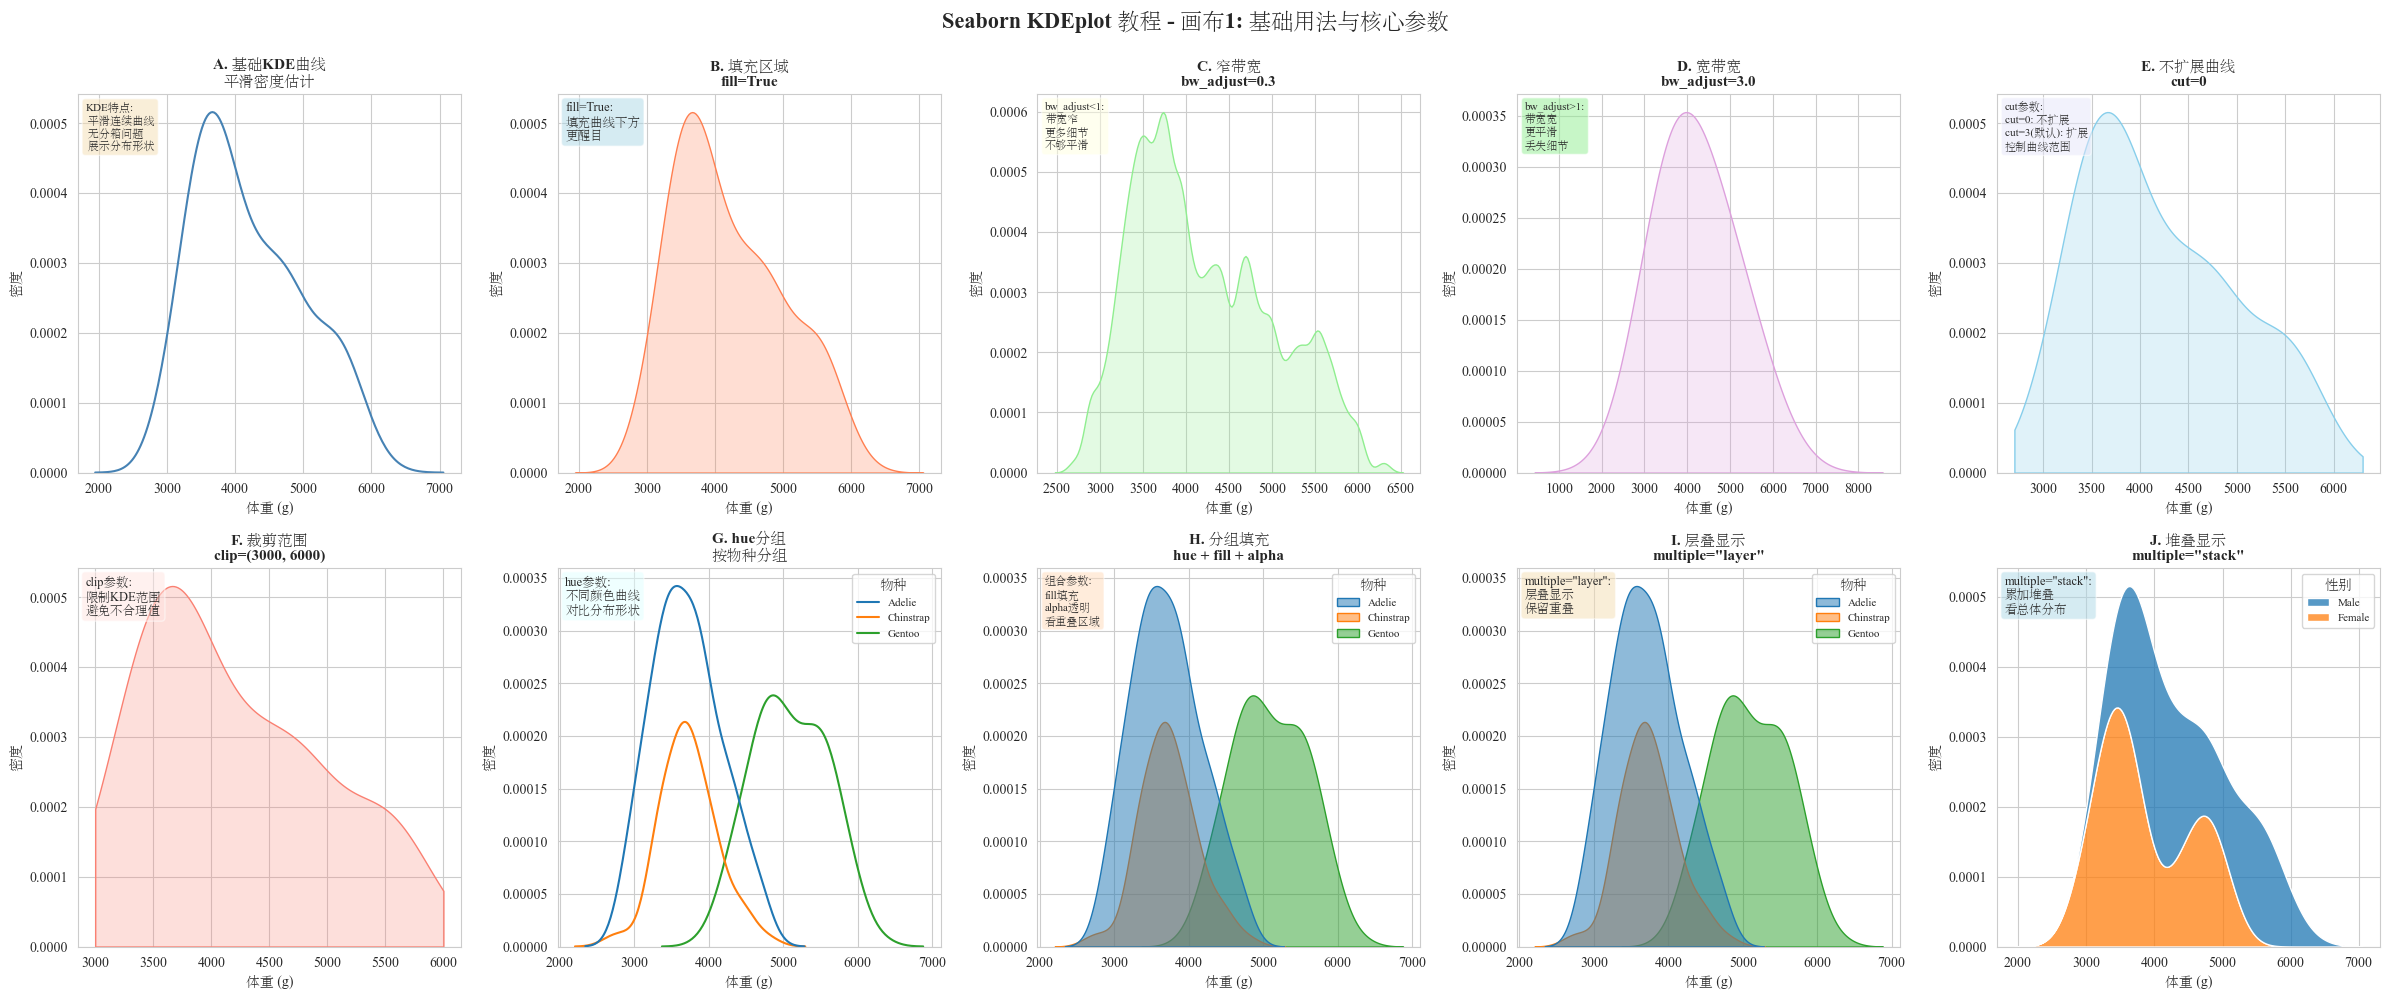

In [9]:
# ============================================================
# 画布 1: 基础用法和核心参数
# ============================================================
fig1, axes1 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2x5子图画布，尺寸为24x10英寸
fig1.suptitle('Seaborn KDEplot 教程 - 画布1: 基础用法与核心参数', fontsize=16, fontweight='bold', y=0.995)  # 设置画布总标题，字体大小16，加粗，y轴位置0.995

# ========== 子图 A：最基础的KDE ==========
ax = axes1[0, 0]  # 选择第1行第1列子图
sns.kdeplot(data=penguins, x='body_mass_g', ax=ax, color='steelblue')  # 绘制企鹅体重KDE曲线，默认带宽，颜色为钢蓝色
ax.set_title('A. 基础KDE曲线\n平滑密度估计', fontsize=11, fontweight='bold')  # 设置标题，说明基本KDE效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'KDE特点:\n 平滑连续曲线\n 无分箱问题\n 展示分布形状',  # 说明KDE的平滑曲线特性
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角背景框，小麦色，透明度0.5

# ========== 子图 B：fill填充 ==========
ax = axes1[0, 1]  # 选择第1行第2列子图
sns.kdeplot(data=penguins, x='body_mass_g', fill=True, ax=ax, color='coral')  # 绘制体重KDE曲线，fill=True填充曲线下区域，颜色为珊瑚色
ax.set_title('B. 填充区域\nfill=True', fontsize=11, fontweight='bold')  # 设置标题，说明填充效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'fill=True:\n填充曲线下方\n更醒目',  # 说明fill参数的视觉增强效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5

# ========== 子图 C：bw_adjust调整带宽 - 小 ==========
ax = axes1[0, 2]  # 选择第1行第3列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            bw_adjust=0.3,  # 设置带宽调整因子为0.3，窄带宽
            fill=True,  # 填充曲线下区域
            ax=ax,  # 指定子图
            color='lightgreen')  # 设置颜色为浅绿色
ax.set_title('C. 窄带宽\nbw_adjust=0.3', fontsize=11, fontweight='bold')  # 设置标题，说明窄带宽效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'bw_adjust<1:\n带宽窄\n更多细节\n不够平滑',  # 说明窄带宽保留更多细节但较粗糙
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5

# ========== 子图 D：bw_adjust调整带宽 - 大 ==========
ax = axes1[0, 3]  # 选择第1行第4列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            bw_adjust=3.0,  # 设置带宽调整因子为3.0，宽带宽
            fill=True,  # 填充曲线下区域
            ax=ax,  # 指定子图
            color='plum')  # 设置颜色为梅紫色
ax.set_title('D. 宽带宽\nbw_adjust=3.0', fontsize=11, fontweight='bold')  # 设置标题，说明宽带宽效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'bw_adjust>1:\n带宽宽\n更平滑\n丢失细节',  # 说明宽带宽平滑但丢失细节
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 圆角背景框，浅绿色，透明度0.5

# ========== 子图 E：cut参数控制扩展 ==========
ax = axes1[0, 4]  # 选择第1行第5列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            cut=0,  # 设置cut=0，限制KDE曲线不超出数据范围
            fill=True,  # 填充曲线下区域
            ax=ax,  # 指定子图
            color='skyblue')  # 设置颜色为天蓝色
ax.set_title('E. 不扩展曲线\ncut=0', fontsize=11, fontweight='bold')  # 设置标题，说明cut=0效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'cut参数:\ncut=0: 不扩展\ncut=3(默认): 扩展\n控制曲线范围',  # 说明cut参数控制KDE范围
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 圆角背景框，淡紫色，透明度0.5

# ========== 子图 F：clip裁剪范围 ==========
ax = axes1[1, 0]  # 选择第2行第1列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            clip=(3000, 6000),  # 限制KDE曲线范围为3000-6000g
            fill=True,  # 填充曲线下区域
            ax=ax,  # 指定子图
            color='salmon')  # 设置颜色为鲑鱼色
ax.set_title('F. 裁剪范围\nclip=(3000, 6000)', fontsize=11, fontweight='bold')  # 设置标题，说明clip裁剪效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'clip参数:\n限制KDE范围\n避免不合理值',  # 说明clip参数限制曲线范围
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 圆角背景框，薄雾玫瑰色，透明度0.5

# ========== 子图 G：添加hue分组 ==========
ax = axes1[1, 1]  # 选择第2行第2列子图
sns.kdeplot(data=penguins, x='body_mass_g', hue='species', ax=ax)  # 按物种分组绘制KDE曲线，自动分配颜色
ax.set_title('G. hue分组\n按物种分组', fontsize=11, fontweight='bold')  # 设置标题，说明hue分组效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
sns.move_legend(ax, loc='upper right', fontsize=8, title='物种')  # 移动图例到右上角，字体大小8，标题为“物种”
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'hue参数:\n不同颜色曲线\n对比分布形状',  # 说明hue参数的分组对比效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 圆角背景框，浅青色，透明度0.5

# ========== 子图 H：hue + fill ==========
ax = axes1[1, 2]  # 选择第2行第3列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            hue='species',  # 按物种分组
            fill=True,  # 填充曲线下区域
            alpha=0.5,  # 设置透明度0.5
            ax=ax)  # 指定子图
ax.set_title('H. 分组填充\nhue + fill + alpha', fontsize=11, fontweight='bold')  # 设置标题，说明分组填充效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
sns.move_legend(ax, loc='upper right', fontsize=8, title='物种')  # 移动图例到右上角，字体大小8，标题为“物种”
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        '组合参数:\nfill填充\nalpha透明\n看重叠区域',  # 说明hue、fill和alpha的组合效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 圆角背景框，桃色，透明度0.5

# ========== 子图 I：multiple='layer' ==========
ax = axes1[1, 3]  # 选择第2行第4列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            hue='species',  # 按物种分组
            fill=True,  # 填充曲线下区域
            multiple='layer',  # 层叠显示分组KDE曲线
            alpha=0.5,  # 设置透明度0.5
            ax=ax)  # 指定子图
ax.set_title('I. 层叠显示\nmultiple="layer"', fontsize=11, fontweight='bold')  # 设置标题，说明层叠显示效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
sns.move_legend(ax, loc='upper right', fontsize=8, title='物种')  # 移动图例到右上角，字体大小8，标题为“物种”
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'multiple="layer":\n层叠显示\n保留重叠',  # 说明multiple=layer的层叠效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角背景框，小麦色，透明度0.5

# ========== 子图 J：multiple='stack' ==========
ax = axes1[1, 4]  # 选择第2行第5列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            hue='sex',  # 按性别分组
            fill=True,  # 填充曲线下区域
            multiple='stack',  # 堆叠显示分组KDE曲线
            ax=ax)  # 指定子图
ax.set_title('J. 堆叠显示\nmultiple="stack"', fontsize=11, fontweight='bold')  # 设置标题，说明堆叠显示效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
sns.move_legend(ax, loc='upper right', fontsize=8, title='性别')  # 移动图例到右上角，字体大小8，标题为“性别”
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'multiple="stack":\n累加堆叠\n看总体分布',  # 说明multiple=stack的堆叠效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示整个画布

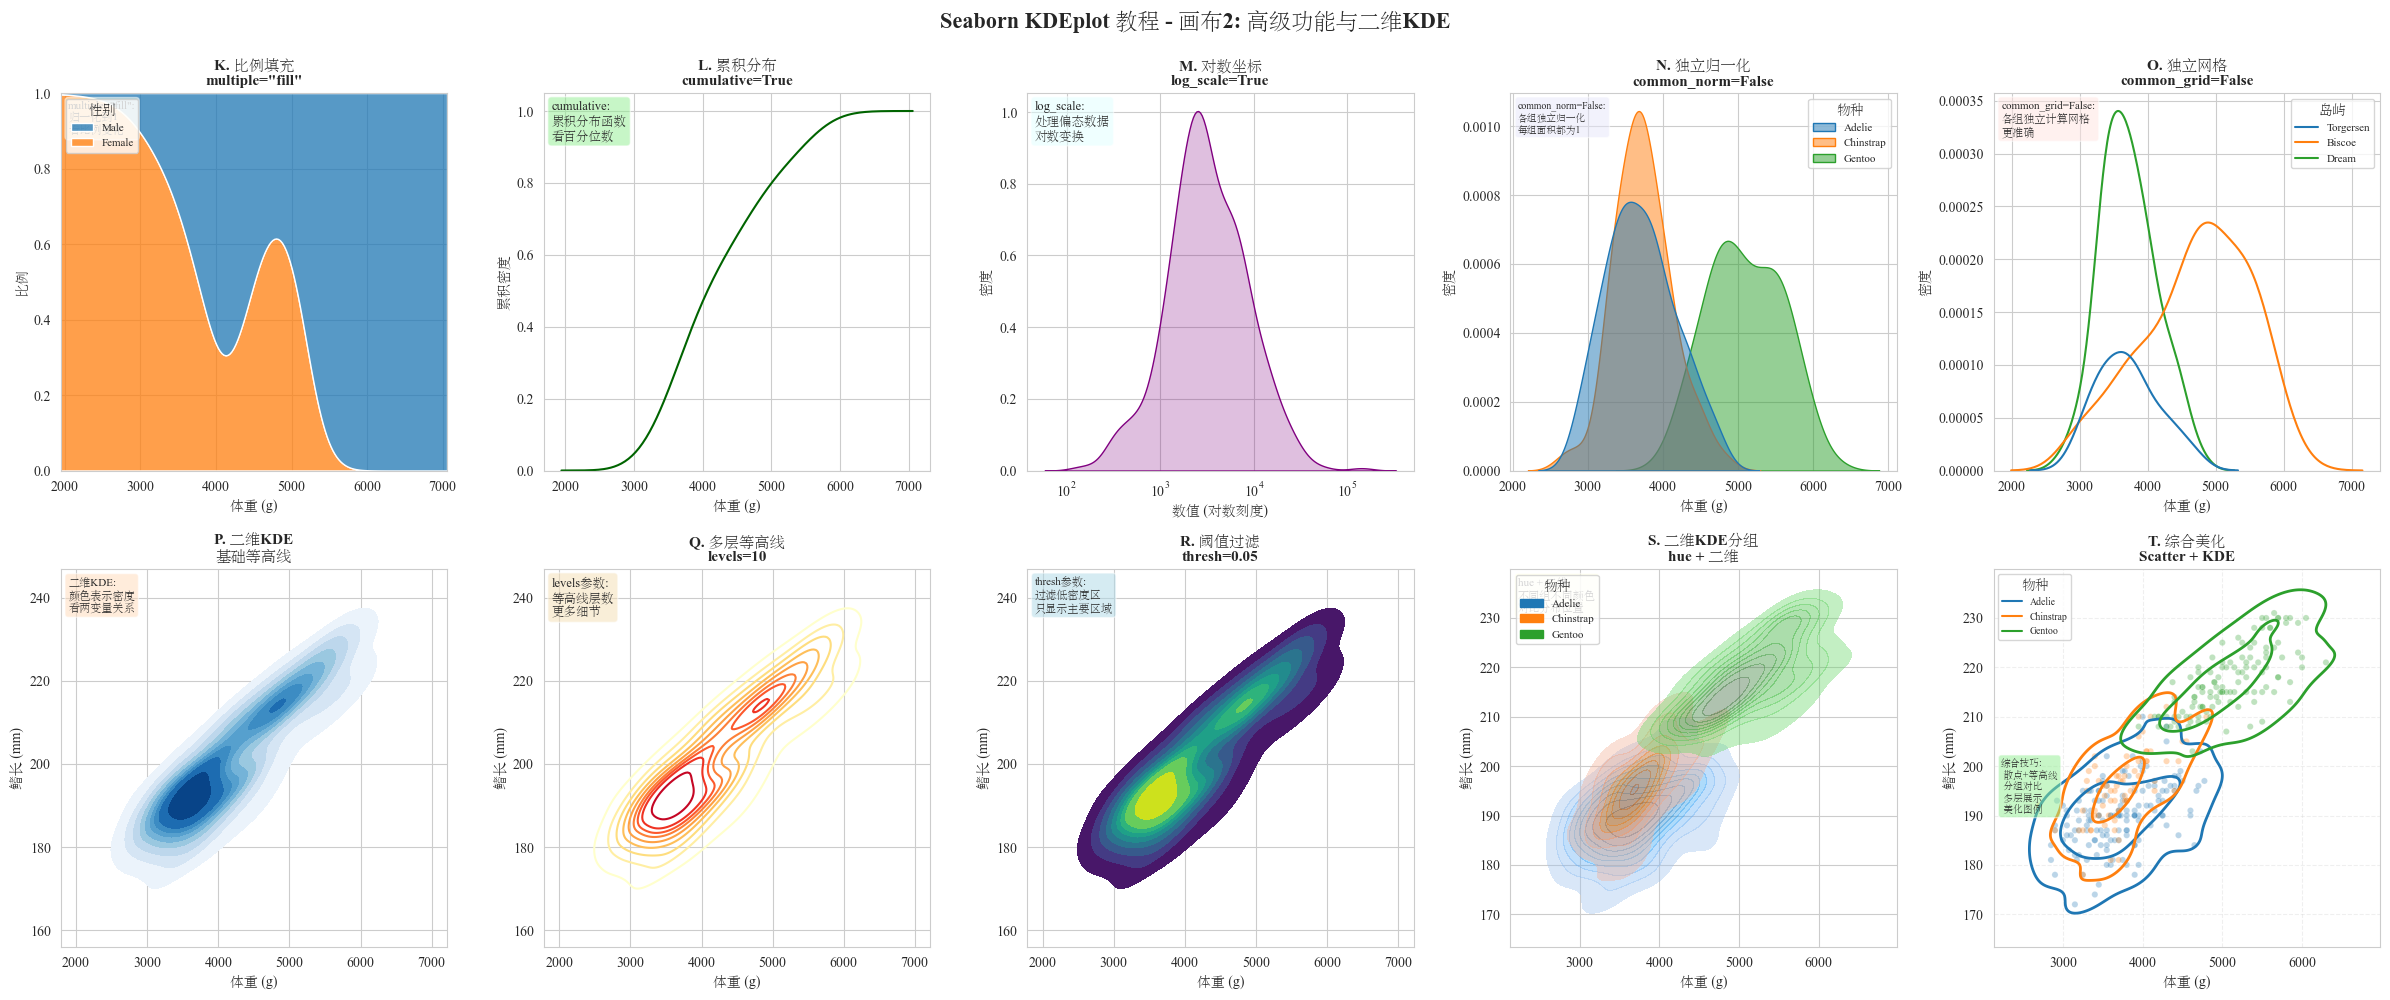

In [10]:
# ============================================================
# 画布 2: 高级功能和二维KDE
# ============================================================
fig2, axes2 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2x5子图画布，尺寸为24x10英寸
fig2.suptitle('Seaborn KDEplot 教程 - 画布2: 高级功能与二维KDE', fontsize=16, fontweight='bold', y=0.995)  # 设置画布总标题，字体大小16，加粗，y轴位置0.995

# ========== 子图 K：multiple='fill' ==========
ax = axes2[0, 0]  # 选择第1行第1列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            hue='sex',  # 按性别分组
            fill=True,  # 填充曲线下区域
            multiple='fill',  # 归一化比例填充，y轴总和为1
            ax=ax)  # 指定子图
ax.set_title('K. 比例填充\nmultiple="fill"', fontsize=11, fontweight='bold')  # 设置标题，说明比例填充效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('比例', fontsize=10)  # 设置y轴标签为“比例”，字体大小10
sns.move_legend(ax, loc='upper left', fontsize=8, title='性别')  # 移动图例到左上角，字体大小8，标题为“性别”
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'multiple="fill":\n归一化到1\n看比例变化',  # 说明multiple=fill的比例归一化效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5

# ========== 子图 L：cumulative累积分布 ==========
ax = axes2[0, 1]  # 选择第1行第2列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            cumulative=True,  # 绘制累积密度分布函数
            ax=ax,  # 指定子图
            color='darkgreen')  # 设置颜色为深绿色
ax.set_title('L. 累积分布\ncumulative=True', fontsize=11, fontweight='bold')  # 设置标题，说明累积分布效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('累积密度', fontsize=10)  # 设置y轴标签为“累积密度”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'cumulative:\n累积分布函数\n看百分位数',  # 说明cumulative=True的累积分布效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 圆角背景框，浅绿色，透明度0.5

# ========== 子图 M：log_scale对数坐标 ==========
ax = axes2[0, 2]  # 选择第1行第3列子图
# 创建偏态数据
skewed_data = np.random.lognormal(mean=8, sigma=1, size=500)  # 生成500个对数正态分布的偏态数据，均值8，标准差1
sns.kdeplot(x=skewed_data, log_scale=True, fill=True, ax=ax, color='purple')  # 绘制偏态数据KDE曲线，x轴对数刻度，填充曲线，颜色为紫色
ax.set_title('M. 对数坐标\nlog_scale=True', fontsize=11, fontweight='bold')  # 设置标题，说明对数坐标效果，字体大小11，加粗
ax.set_xlabel('数值 (对数刻度)', fontsize=10)  # 设置x轴标签为“数值 (对数刻度)”，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'log_scale:\n处理偏态数据\n对数变换',  # 说明log_scale处理偏态数据的效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 圆角背景框，浅青色，透明度0.5

# ========== 子图 N：common_norm参数 ==========
ax = axes2[0, 3]  # 选择第1行第4列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            hue='species',  # 按物种分组
            fill=True,  # 填充曲线下区域
            common_norm=False,  # 各组独立归一化，每组面积为1
            alpha=0.5,  # 设置透明度0.5
            ax=ax)  # 指定子图
ax.set_title('N. 独立归一化\ncommon_norm=False', fontsize=11, fontweight='bold')  # 设置标题，说明独立归一化效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
sns.move_legend(ax, loc='upper right', fontsize=8, title='物种')  # 移动图例到右上角，字体大小8，标题为“物种”
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'common_norm=False:\n各组独立归一化\n每组面积都为1',  # 说明common_norm=False的独立归一化效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=7,  # 字体大小7
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 圆角背景框，淡紫色，透明度0.5

# ========== 子图 O：common_grid参数 ==========
ax = axes2[0, 4]  # 选择第1行第5列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            hue='island',  # 按岛屿分组
            common_grid=False,  # 各组使用独立网格计算KDE
            ax=ax)  # 指定子图
ax.set_title('O. 独立网格\ncommon_grid=False', fontsize=11, fontweight='bold')  # 设置标题，说明独立网格效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
sns.move_legend(ax, loc='upper right', fontsize=8, title='岛屿')  # 移动图例到右上角，字体大小8，标题为“岛屿”
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'common_grid=False:\n各组独立计算网格\n更准确',  # 说明common_grid=False的独立网格效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 圆角背景框，薄雾玫瑰色，透明度0.5

# ========== 子图 P：二维KDE - 基础 ==========
ax = axes2[1, 0]  # 选择第2行第1列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            y='flipper_length_mm',  # y轴为鳍长，绘制二维KDE
            fill=True,  # 填充等高线区域
            cmap='Blues',  # 使用蓝色渐变色图
            ax=ax)  # 指定子图
ax.set_title('P. 二维KDE\n基础等高线', fontsize=11, fontweight='bold')  # 设置标题，说明基础二维KDE效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # 设置y轴标签为“鳍长 (mm)”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        '二维KDE:\n颜色表示密度\n看两变量关系',  # 说明二维KDE显示变量密度关系
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 圆角背景框，桃色，透明度0.5

# ========== 子图 Q：二维KDE + levels ==========
ax = axes2[1, 1]  # 选择第2行第2列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            y='flipper_length_mm',  # y轴为鳍长
            levels=10,  # 设置10层等高线
            cmap='YlOrRd',  # 使用黄橙红渐变色图
            ax=ax)  # 指定子图
ax.set_title('Q. 多层等高线\nlevels=10', fontsize=11, fontweight='bold')  # 设置标题，说明多层等高线效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # 设置y轴标签为“鳍长 (mm)”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'levels参数:\n等高线层数\n更多细节',  # 说明levels参数增加等高线细节
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角背景框，小麦色，透明度0.5

# ========== 子图 R：二维KDE + thresh ==========
ax = axes2[1, 2]  # 选择第2行第3列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            y='flipper_length_mm',  # y轴为鳍长
            fill=True,  # 填充等高线区域
            thresh=0.05,  # 设置密度阈值0.05，过滤低密度区域
            cmap='viridis',  # 使用viridis渐变色图
            ax=ax)  # 指定子图
ax.set_title('R. 阈值过滤\nthresh=0.05', fontsize=11, fontweight='bold')  # 设置标题，说明阈值过滤效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # 设置y轴标签为“鳍长 (mm)”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'thresh参数:\n过滤低密度区\n只显示主要区域',  # 说明thresh参数过滤低密度效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5

# ========== 子图 S：二维KDE + hue ==========
ax = axes2[1, 3]  # 选择第2行第4列子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            y='flipper_length_mm',  # y轴为鳍长
            hue='species',  # 按物种分组
            fill=True,  # 填充等高线区域
            alpha=0.4,  # 设置透明度0.4
            ax=ax)  # 指定子图
ax.set_title('S. 二维KDE分组\nhue + 二维', fontsize=11, fontweight='bold')  # 设置标题，说明分组二维KDE效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # 设置y轴标签为“鳍长 (mm)”，字体大小10
sns.move_legend(ax, loc='upper left', fontsize=8, title='物种')  # 移动图例到左上角，字体大小8，标题为“物种”
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'hue + 二维:\n不同组不同颜色\n对比分布位置',  # 说明hue参数在二维KDE的对比效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5

# ========== 子图 T：综合美化案例 ==========
ax = axes2[1, 4]  # 选择第2行第5列子图
# 结合scatter和KDE
sns.scatterplot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                y='flipper_length_mm',  # y轴为鳍长
                hue='species',  # 按物种分组
                alpha=0.3,  # 设置散点透明度0.3
                s=20,  # 设置散点大小为20
                ax=ax)  # 指定子图
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            y='flipper_length_mm',  # y轴为鳍长
            hue='species',  # 按物种分组
            levels=3,  # 设置3层等高线
            linewidths=2,  # 设置等高线宽度为2
            ax=ax)  # 指定子图
ax.set_title('T. 综合美化\nScatter + KDE', fontsize=11, fontweight='bold')  # 设置标题，说明散点与KDE组合效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # 设置y轴标签为“鳍长 (mm)”，字体大小10
sns.move_legend(ax, loc='upper left', fontsize=7, title='物种')  # 移动图例到左上角，字体大小7，标题为“物种”
ax.grid(alpha=0.3, linestyle='--')  # 添加网格线，透明度0.3，虚线样式
ax.text(0.02,  # 在子图左中部添加文本框，x坐标0.02
        0.50,  # y坐标0.50，顶部对齐
        '综合技巧:\n 散点+等高线\n 分组对比\n 多层展示\n 美化图例',  # 说明散点与KDE的综合美化效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=7,  # 字体大小7
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 圆角背景框，浅绿色，透明度0.5

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示整个画布


额外演示: KDE vs Histogram 对比


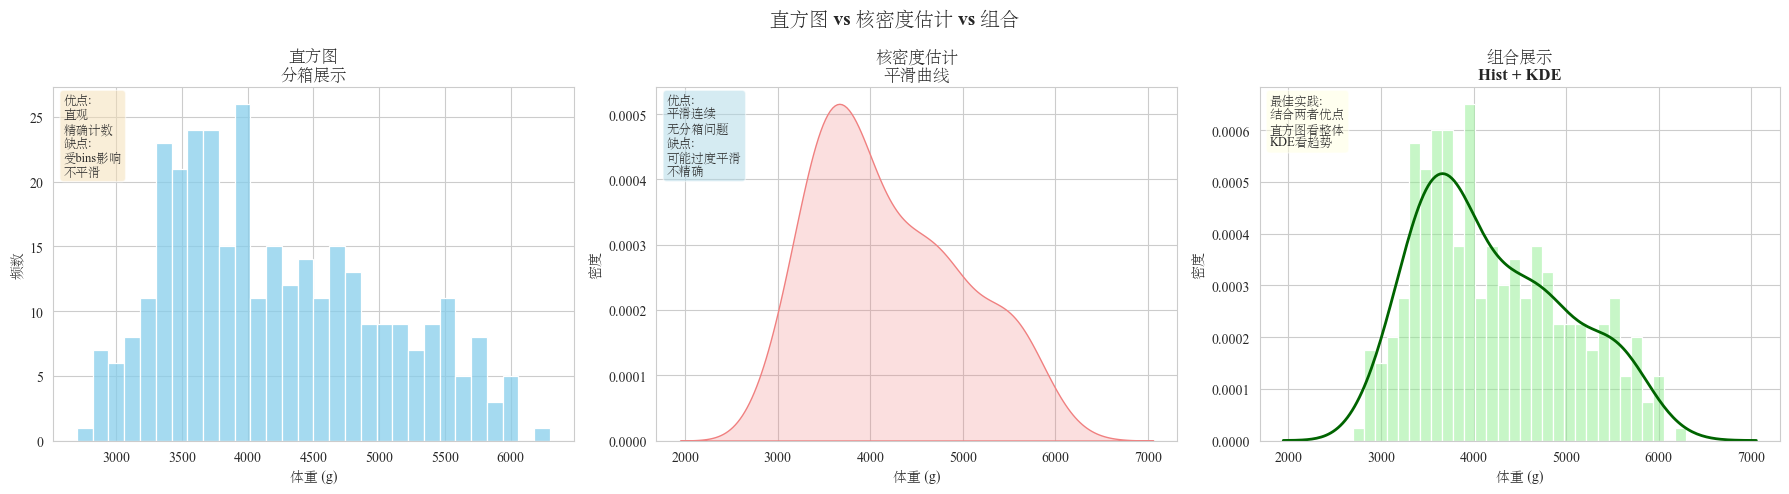

In [11]:
# ============================================================
# 额外演示：KDE vs Hist对比
# ============================================================
print("\n" + "=" * 60)  # 打印60个等号作为分隔线，前面加换行符
print("额外演示: KDE vs Histogram 对比")  # 打印说明，介绍直方图与核密度估计的对比
print("=" * 60)  # 打印60个等号作为分隔线

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))  # 创建1x3子图画布，尺寸为18x5英寸
fig3.suptitle('直方图 vs 核密度估计 vs 组合', fontsize=14,
              fontweight='bold')  # 设置画布总标题，字体大小14，加粗

# 纯直方图
ax = axes3[0]  # 选择第1个子图（左图）
sns.histplot(data=penguins, x='body_mass_g', bins=30, ax=ax,
             color='skyblue')  # 绘制企鹅体重直方图，分30箱，颜色为天蓝色
ax.set_title('直方图\n分箱展示', fontsize=12,
             fontweight='bold')  # 设置标题，说明直方图分箱效果，字体大小12，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('频数', fontsize=10)  # 设置y轴标签为“频数”，字体大小10
ax.text(
    0.02,
    0.98,
    '优点:\n直观\n精确计数\n缺点:\n受bins影响\n不平滑',  # 添加文本框，说明直方图优缺点
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',  # 使用子图相对坐标，字体大小9，顶部对齐
    bbox=dict(boxstyle='round', facecolor='wheat',
              alpha=0.5))  # 圆角背景框，小麦色，透明度0.5

# 纯KDE
ax = axes3[1]  # 选择第2个子图（中图）
sns.kdeplot(data=penguins,
            x='body_mass_g',
            fill=True,
            ax=ax,
            color='lightcoral')  # 绘制体重KDE曲线，填充曲线下区域，颜色为浅珊瑚色
ax.set_title('核密度估计\n平滑曲线', fontsize=12,
             fontweight='bold')  # 设置标题，说明KDE平滑效果，字体大小12，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
ax.text(
    0.02,
    0.98,
    '优点:\n平滑连续\n无分箱问题\n缺点:\n可能过度平滑\n不精确',  # 添加文本框，说明KDE优缺点
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',  # 使用子图相对坐标，字体大小9，顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightblue',
              alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5

# 组合
ax = axes3[2]  # 选择第3个子图（右图）
sns.histplot(
    data=penguins,
    x='body_mass_g',
    stat='density',  # 绘制体重直方图，y轴为密度，分30箱
    bins=30,
    ax=ax,
    color='lightgreen',
    alpha=0.5)  # 颜色为浅绿色，透明度0.5
sns.kdeplot(
    data=penguins,
    x='body_mass_g',
    ax=ax,  # 在同一子图绘制KDE曲线
    color='darkgreen',
    linewidth=2)  # 颜色为深绿色，线宽2
ax.set_title('组合展示\nHist + KDE', fontsize=12,
             fontweight='bold')  # 设置标题，说明直方图与KDE组合，字体大小12，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('密度', fontsize=10)  # 设置y轴标签为“密度”，字体大小10
ax.text(
    0.02,
    0.98,
    '最佳实践:\n结合两者优点\n直方图看整体\nKDE看趋势',  # 添加文本框，说明组合展示的优点
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',  # 使用子图相对坐标，字体大小9，顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightyellow',
              alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示整个画布


额外演示: bw_adjust参数的影响


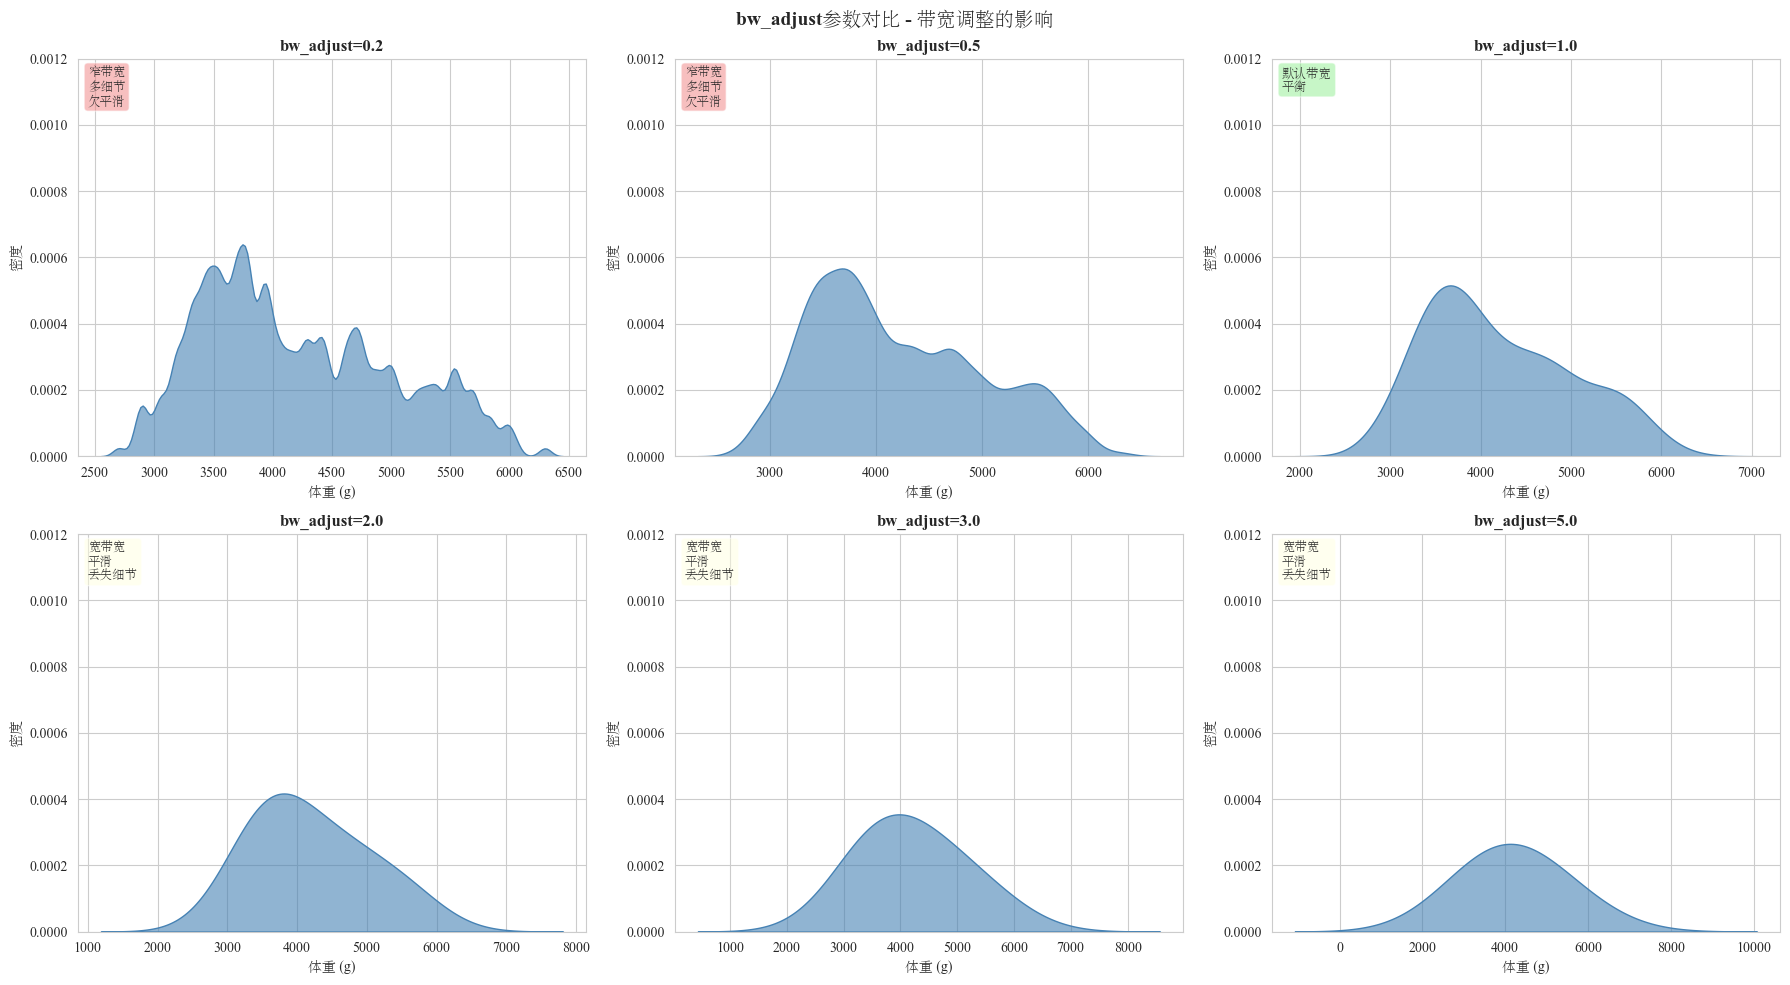

In [15]:
# ============================================================
# 额外演示：不同bw_adjust对比
# ============================================================
print("\n" + "="*60)
print("额外演示: bw_adjust参数的影响")
print("="*60)

fig4, axes4 = plt.subplots(2, 3, figsize=(18, 10))
fig4.suptitle('bw_adjust参数对比 - 带宽调整的影响', fontsize=14, fontweight='bold')

bw_values = [0.2, 0.5, 1.0, 2.0, 3.0, 5.0]
for idx, bw in enumerate(bw_values):
    ax = axes4.flat[idx]
    sns.kdeplot(data=penguins, x='body_mass_g', bw_adjust=bw,
                fill=True, ax=ax, color='steelblue', alpha=0.6)
    ax.set_title(f'bw_adjust={bw}', fontsize=12, fontweight='bold')
    ax.set_xlabel('体重 (g)', fontsize=10)
    ax.set_ylabel('密度', fontsize=10)
    ax.set_ylim(0, 0.0012)  # 统一Y轴便于对比
    
    if bw < 1:
        desc = '窄带宽\n多细节\n欠平滑'
        color = 'lightcoral'
    elif bw == 1:
        desc = '默认带宽\n平衡'
        color = 'lightgreen'
    else:
        desc = '宽带宽\n平滑\n丢失细节'
        color = 'lightyellow'
    
    ax.text(0.02, 0.98, desc, transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.5))

plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# 打印重要参数总结
# ============================================================
print("\n" + "="*60)
print("Seaborn kdeplot 核心参数总结 (v0.13.2+)")
print("="*60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x: 数值变量(一维KDE)
   - y: 第二个数值变量(二维KDE)
   - hue: 分组变量

2. 带宽控制: ⭐⭐⭐
   - bw_adjust: 带宽调整因子(默认1.0)
     * <1: 窄带宽，更多细节，不够平滑
     * =1: 默认带宽(Scott法则)
     * >1: 宽带宽，更平滑，丢失细节
   - bw_method: 带宽计算方法
     * 'scott': Scott法则(默认)
     * 'silverman': Silverman法则
     * 数值: 固定带宽

3. 范围控制:
   - cut: 曲线扩展距离(默认3)
     * 0: 不扩展
     * 正数: 扩展倍数×带宽
   - clip: 裁剪范围(min, max)
     * 限制KDE计算范围
     * 避免不合理的值

4. 填充和样式:
   - fill: 填充曲线下方(True/False)
   - alpha: 透明度(0-1)
   - color: 单一颜色
   - palette: 调色板(配合hue)
   - linewidth: 线宽

5. 多组处理: ⭐⭐⭐
   - multiple: 多个hue组的处理
     * 'layer': 层叠(默认)
     * 'stack': 堆叠
     * 'fill': 比例填充

6. 归一化:
   - common_norm: 共享归一化(True/False，默认True)
     * True: 所有组一起归一化
     * False: 各组独立归一化(各组面积都为1)
   - common_grid: 共享网格(True/False，默认True)
     * True: 所有组共享计算网格
     * False: 各组独立计算

7. 累积分布:
   - cumulative: 累积分布(True/False)
   - complementary: 补累积(True/False)

8. 二维KDE特有: ⭐⭐⭐
   - levels: 等高线层数
     * 整数: 指定层数
     * 列表: 指定具体层级
   - thresh: 密度阈值(0-1)
     * 过滤低密度区域
     * 只显示主要区域
   - cmap: 颜色映射
   - cbar: 显示颜色条(True/False)

9. 坐标轴:
   - log_scale: 对数坐标(True/False或(x_bool, y_bool))
   - weights: 权重数组

10. KDE vs Histogram:
   ┌──────────────┬────────────┬────────────┐
   │   特性       │  Histogram │    KDE     │
   ├──────────────┼────────────┼────────────┤
   │ 平滑度       │  不平滑    │  平滑      │
   │ 分箱依赖     │  依赖bins  │  无分箱    │
   │ 精确度       │  精确      │  近似      │
   │ 视觉效果     │  阶梯状    │  连续曲线  │
   │ 参数敏感     │  bins      │  bw_adjust │
   │ 适用场景     │  快速探索  │  展示报告  │
   └──────────────┴────────────┴────────────┘

11. bw_adjust选择建议:
   - 探索数据细节 → 0.3-0.5
   - 一般展示 → 1.0(默认)
   - 展示整体趋势 → 2.0-3.0
   - 数据量小 → 增大bw_adjust
   - 数据量大 → 可减小bw_adjust

12. 二维KDE使用技巧:
   - thresh过滤噪声
   - levels控制细节
   - 结合scatter展示原始点
   - 使用cmap选择合适配色

13. 使用场景:
   ✓ 展示平滑的分布曲线
   ✓ 对比多组数据的分布形状
   ✓ 识别数据的多峰特征
   ✓ 论文和报告的专业配图
   ✓ 二维KDE看两变量关系
   ✓ 累积分布函数

14. 最佳实践:
   ⭐ 尝试不同bw_adjust找最佳效果
   ⭐ 与直方图结合验证
   ⭐ 使用fill=True增强视觉效果
   ⭐ 多组对比时设置alpha透明度
   ⭐ 二维KDE设置合适的thresh
   ⭐ 注意cut和clip避免超出合理范围

15. 常见组合:
   - histplot + kdeplot: 最常用
   - kdeplot(fill=True, alpha=0.5) + hue: 分组对比
   - 二维kdeplot + scatterplot: 密度+原始点
   - cumulative=True: 累积分布分析
""")


Seaborn kdeplot 核心参数总结 (v0.13.2+)

1. 基础参数:
   - data: 数据源(DataFrame)
   - x: 数值变量(一维KDE)
   - y: 第二个数值变量(二维KDE)
   - hue: 分组变量

2. 带宽控制: ⭐⭐⭐
   - bw_adjust: 带宽调整因子(默认1.0)
     * <1: 窄带宽，更多细节，不够平滑
     * =1: 默认带宽(Scott法则)
     * >1: 宽带宽，更平滑，丢失细节
   - bw_method: 带宽计算方法
     * 'scott': Scott法则(默认)
     * 'silverman': Silverman法则
     * 数值: 固定带宽

3. 范围控制:
   - cut: 曲线扩展距离(默认3)
     * 0: 不扩展
     * 正数: 扩展倍数×带宽
   - clip: 裁剪范围(min, max)
     * 限制KDE计算范围
     * 避免不合理的值

4. 填充和样式:
   - fill: 填充曲线下方(True/False)
   - alpha: 透明度(0-1)
   - color: 单一颜色
   - palette: 调色板(配合hue)
   - linewidth: 线宽

5. 多组处理: ⭐⭐⭐
   - multiple: 多个hue组的处理
     * 'layer': 层叠(默认)
     * 'stack': 堆叠
     * 'fill': 比例填充

6. 归一化:
   - common_norm: 共享归一化(True/False，默认True)
     * True: 所有组一起归一化
     * False: 各组独立归一化(各组面积都为1)
   - common_grid: 共享网格(True/False，默认True)
     * True: 所有组共享计算网格
     * False: 各组独立计算

7. 累积分布:
   - cumulative: 累积分布(True/False)
   - complementary: 补累积(True/False)

8. 二维KDE特有: ⭐⭐⭐
   - levels: 等高线层数


## ecdfplot

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 加载数据集
penguins = sns.load_dataset('penguins').dropna()
tips = sns.load_dataset('tips')

print(f"数据集形状: {penguins.shape}")
print(f"\nECDFplot特点: 经验累积分布函数(ECDF)")
print("适合展示数据的累积概率分布")
print(
    f"\n体重分布范围: {penguins['body_mass_g'].min()} - {penguins['body_mass_g'].max()} g"
)

数据集形状: (333, 7)

ECDFplot特点: 经验累积分布函数(ECDF)
适合展示数据的累积概率分布

体重分布范围: 2700.0 - 6300.0 g


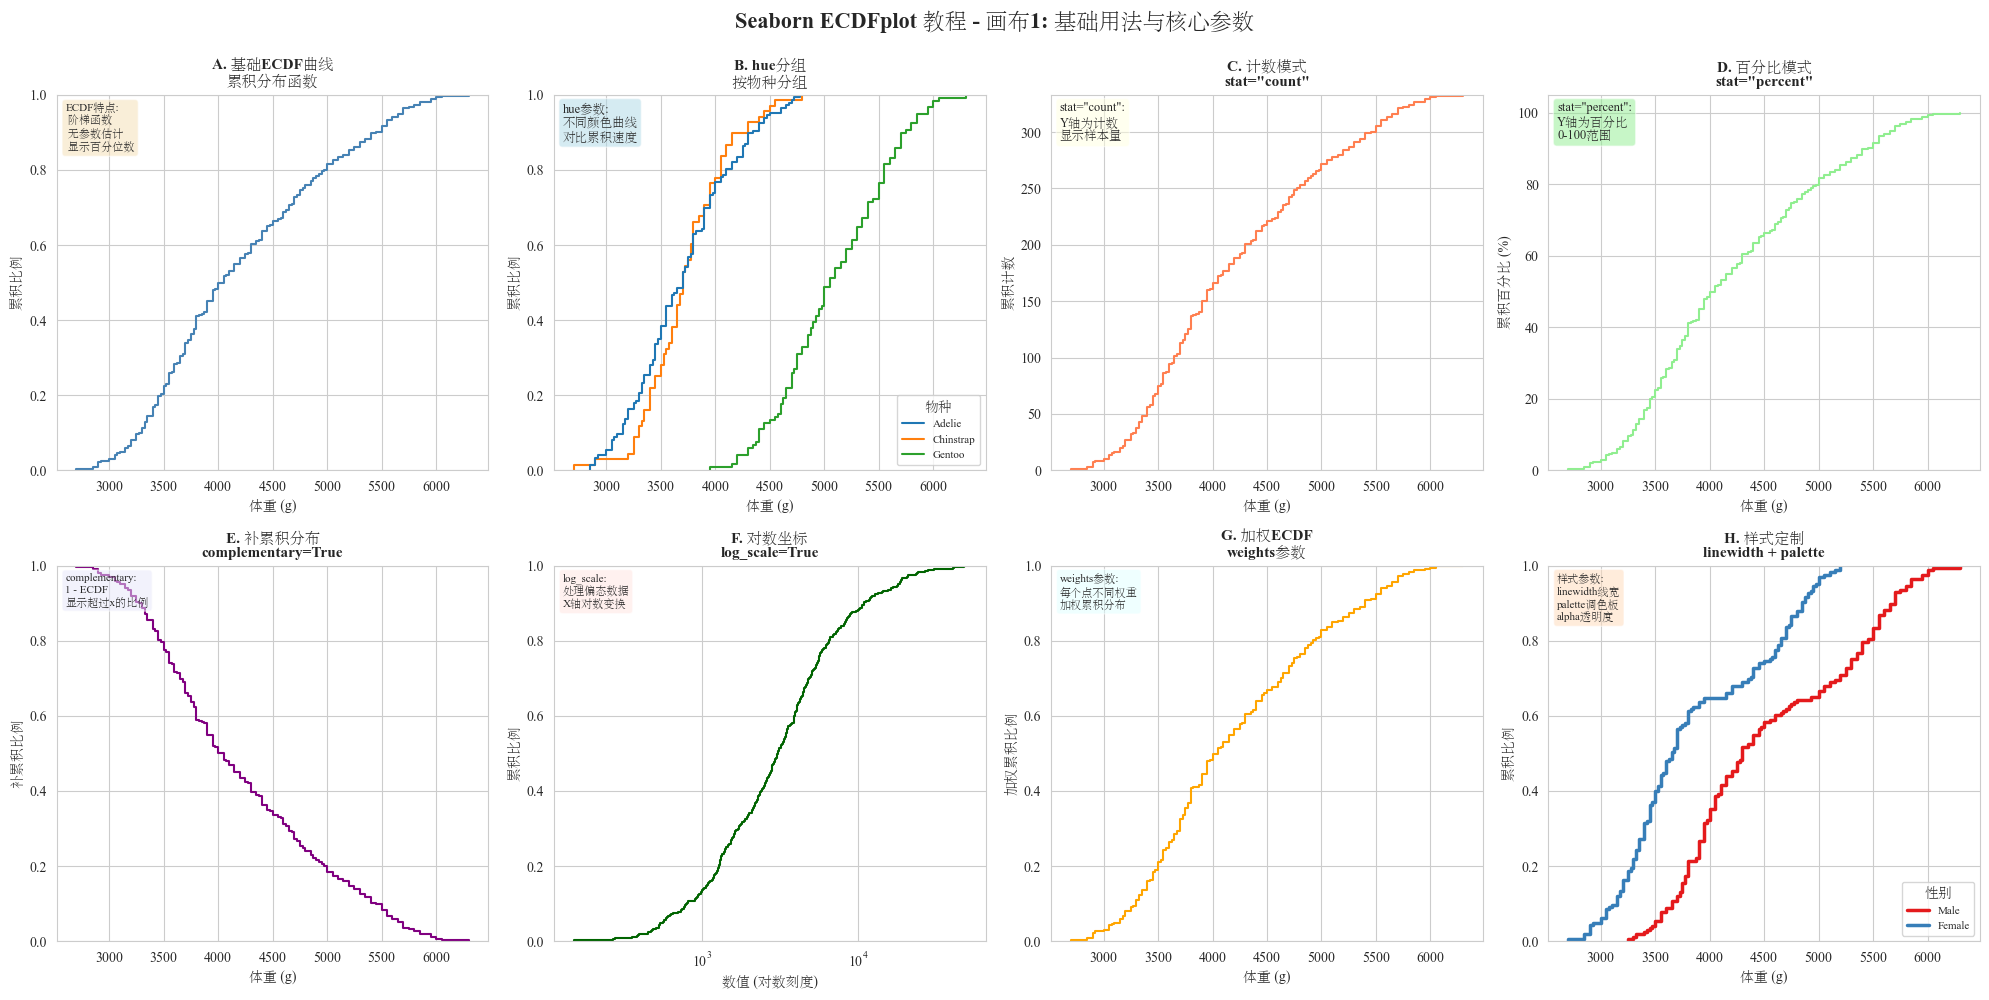

In [15]:
# ============================================================
# 画布 1: 基础用法和核心参数
# ============================================================
fig1, axes1 = plt.subplots(2, 4, figsize=(20, 10))  # 创建2x4子图画布，尺寸为20x10英寸
fig1.suptitle('Seaborn ECDFplot 教程 - 画布1: 基础用法与核心参数', fontsize=16, fontweight='bold', y=0.995)  # 设置画布总标题，字体大小16，加粗，y轴位置0.995

# ========== 子图 A：最基础的ECDF ==========
ax = axes1[0, 0]  # 选择第1行第1列子图
sns.ecdfplot(data=penguins, x='body_mass_g', ax=ax, color='steelblue')  # 绘制企鹅体重ECDF曲线，颜色为钢蓝色
ax.set_title('A. 基础ECDF曲线\n累积分布函数', fontsize=11, fontweight='bold')  # 设置标题，说明基础ECDF效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('累积比例', fontsize=10)  # 设置y轴标签为“累积比例”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'ECDF特点:\n 阶梯函数\n 无参数估计\n 显示百分位数',  # 说明ECDF的阶梯函数特性
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角背景框，小麦色，透明度0.5

# ========== 子图 B：添加hue分组 ==========
ax = axes1[0, 1]  # 选择第1行第2列子图
sns.ecdfplot(data=penguins, x='body_mass_g', hue='species', ax=ax)  # 按物种分组绘制ECDF曲线，自动分配颜色
ax.set_title('B. hue分组\n按物种分组', fontsize=11, fontweight='bold')  # 设置标题，说明hue分组效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('累积比例', fontsize=10)  # 设置y轴标签为“累积比例”，字体大小10
sns.move_legend(ax, loc='lower right', fontsize=8, title='物种')  # 移动图例到右下角，字体大小8，标题为“物种”
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'hue参数:\n不同颜色曲线\n对比累积速度',  # 说明hue参数的分组对比效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5

# ========== 子图 C：stat='count' ==========
ax = axes1[0, 2]  # 选择第1行第3列子图
sns.ecdfplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             stat='count',  # y轴显示累积计数
             ax=ax,  # 指定子图
             color='coral')  # 设置颜色为珊瑚色
ax.set_title('C. 计数模式\nstat="count"', fontsize=11, fontweight='bold')  # 设置标题，说明计数模式效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('累积计数', fontsize=10)  # 设置y轴标签为“累积计数”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'stat="count":\nY轴为计数\n显示样本量',  # 说明stat=count的累积计数效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5

# ========== 子图 D：stat='percent' ==========
ax = axes1[0, 3]  # 选择第1行第4列子图
sns.ecdfplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             stat='percent',  # y轴显示累积百分比
             ax=ax,  # 指定子图
             color='lightgreen')  # 设置颜色为浅绿色
ax.set_title('D. 百分比模式\nstat="percent"', fontsize=11, fontweight='bold')  # 设置标题，说明百分比模式效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('累积百分比 (%)', fontsize=10)  # 设置y轴标签为“累积百分比 (%)”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'stat="percent":\nY轴为百分比\n0-100范围',  # 说明stat=percent的百分比范围效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=9,  # 字体大小9
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 圆角背景框，浅绿色，透明度0.5

# ========== 子图 E：complementary补累积 ==========
ax = axes1[1, 0]  # 选择第2行第1列子图
sns.ecdfplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             complementary=True,  # 绘制补累积分布（1-ECDF）
             ax=ax,  # 指定子图
             color='purple')  # 设置颜色为紫色
ax.set_title('E. 补累积分布\ncomplementary=True', fontsize=11, fontweight='bold')  # 设置标题，说明补累积效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('补累积比例', fontsize=10)  # 设置y轴标签为“补累积比例”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'complementary:\n1 - ECDF\n显示超过x的比例',  # 说明complementary=True的补累积效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 圆角背景框，淡紫色，透明度0.5

# ========== 子图 F：log_scale对数坐标 ==========
ax = axes1[1, 1]  # 选择第2行第2列子图
# 创建偏态数据
skewed_data = np.random.lognormal(mean=8, sigma=1, size=500)  # 生成500个对数正态分布的偏态数据，均值8，标准差1
sns.ecdfplot(x=skewed_data, log_scale=True, ax=ax, color='darkgreen')  # 绘制偏态数据ECDF曲线，x轴对数刻度，颜色为深绿色
ax.set_title('F. 对数坐标\nlog_scale=True', fontsize=11, fontweight='bold')  # 设置标题，说明对数坐标效果，字体大小11，加粗
ax.set_xlabel('数值 (对数刻度)', fontsize=10)  # 设置x轴标签为“数值 (对数刻度)”，字体大小10
ax.set_ylabel('累积比例', fontsize=10)  # 设置y轴标签为“累积比例”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'log_scale:\n处理偏态数据\nX轴对数变换',  # 说明log_scale处理偏态数据的效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 圆角背景框，薄雾玫瑰色，透明度0.5

# ========== 子图 G：weights权重 ==========
ax = axes1[1, 2]  # 选择第2行第3列子图
# 创建权重
weights = np.random.uniform(0.5, 2.0, len(penguins))  # 为企鹅数据集生成随机权重，范围0.5到2.0
sns.ecdfplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             weights=weights,  # 应用权重到每个数据点
             ax=ax,  # 指定子图
             color='orange')  # 设置颜色为橙色
ax.set_title('G. 加权ECDF\nweights参数', fontsize=11, fontweight='bold')  # 设置标题，说明加权ECDF效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('加权累积比例', fontsize=10)  # 设置y轴标签为“加权累积比例”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'weights参数:\n每个点不同权重\n加权累积分布',  # 说明weights参数的加权效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 圆角背景框，浅青色，透明度0.5

# ========== 子图 H：样式定制 ==========
ax = axes1[1, 3]  # 选择第2行第4列子图
sns.ecdfplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             hue='sex',  # 按性别分组
             palette='Set1',  # 使用Set1调色板
             linewidth=2.5,  # 设置曲线宽度为2.5
             ax=ax)  # 指定子图
ax.set_title('H. 样式定制\nlinewidth + palette', fontsize=11, fontweight='bold')  # 设置标题，说明样式定制效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('累积比例', fontsize=10)  # 设置y轴标签为“累积比例”，字体大小10
sns.move_legend(ax, loc='lower right', fontsize=8, title='性别')  # 移动图例到右下角，字体大小8，标题为“性别”
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        '样式参数:\nlinewidth线宽\npalette调色板\nalpha透明度',  # 说明样式参数的定制效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 圆角背景框，桃色，透明度0.5

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示整个画布

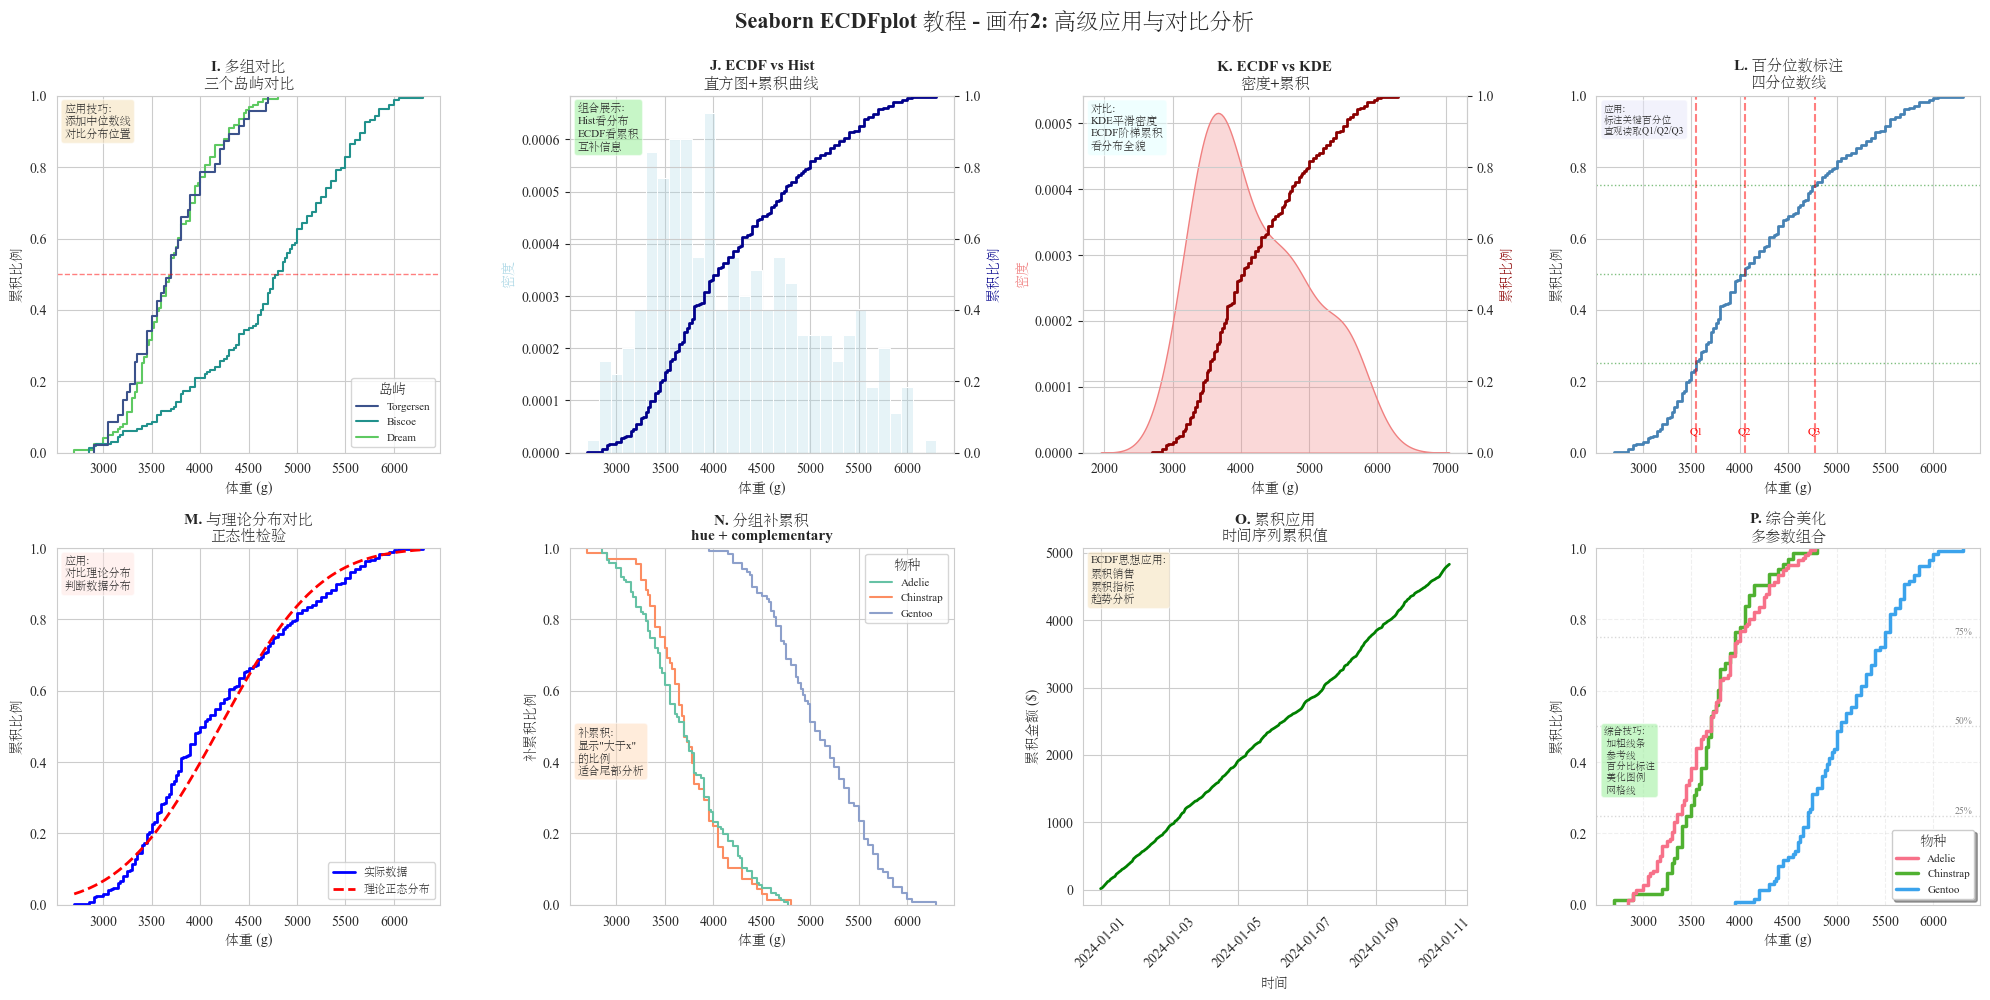

In [16]:
# ============================================================
# 画布 2: 高级应用和对比分析
# ============================================================
fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10))  # 创建2x4子图画布，尺寸为20x10英寸
fig2.suptitle('Seaborn ECDFplot 教程 - 画布2: 高级应用与对比分析', fontsize=16, fontweight='bold', y=0.995)  # 设置画布总标题，字体大小16，加粗，y轴位置0.995

# ========== 子图 I：多变量对比 ==========
ax = axes2[0, 0]  # 选择第1行第1列子图
sns.ecdfplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             hue='island',  # 按岛屿分组
             palette='viridis',  # 使用viridis调色板
             ax=ax)  # 指定子图
ax.set_title('I. 多组对比\n三个岛屿对比', fontsize=11, fontweight='bold')  # 设置标题，说明多组对比效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('累积比例', fontsize=10)  # 设置y轴标签为“累积比例”，字体大小10
sns.move_legend(ax, loc='lower right', fontsize=8, title='岛屿')  # 移动图例到右下角，字体大小8，标题为“岛屿”
# 添加参考线
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, linewidth=1)  # 添加水平中位数线，红色虚线，透明度0.5，线宽1
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        '应用技巧:\n添加中位数线\n对比分布位置',  # 说明中位数线的应用效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角背景框，小麦色，透明度0.5

# ========== 子图 J：ECDF vs Histogram ==========
ax = axes2[0, 1]  # 选择第1行第2列子图
# 使用双Y轴
ax2 = ax.twinx()  # 创建第二个y轴，与主轴共享x轴
sns.histplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             stat='density',  # y轴显示密度，面积和为1
             bins=30,  # 分30箱
             alpha=0.3,  # 设置直方图透明度0.3
             color='lightblue',  # 设置颜色为浅蓝色
             ax=ax)  # 指定主轴绘制直方图
sns.ecdfplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             color='darkblue',  # 设置颜色为深蓝色
             linewidth=2,  # 设置线宽2
             ax=ax2)  # 指定第二轴绘制ECDF
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10, color='lightblue')  # 设置主轴y轴标签为“密度”，颜色匹配直方图
ax2.set_ylabel('累积比例', fontsize=10, color='darkblue')  # 设置第二轴y轴标签为“累积比例”，颜色匹配ECDF
ax.set_title('J. ECDF vs Hist\n直方图+累积曲线', fontsize=11, fontweight='bold')  # 设置标题，说明直方图与ECDF组合，字体大小11，加粗
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        '组合展示:\nHist看分布\nECDF看累积\n互补信息',  # 说明直方图与ECDF的互补效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 圆角背景框，浅绿色，透明度0.5

# ========== 子图 K：ECDF vs KDE ==========
ax = axes2[0, 2]  # 选择第1行第3列子图
ax2 = ax.twinx()  # 创建第二个y轴，与主轴共享x轴
sns.kdeplot(data=penguins,  # 使用企鹅数据集
            x='body_mass_g',  # x轴为体重
            fill=True,  # 填充KDE曲线下区域
            alpha=0.3,  # 设置KDE透明度0.3
            color='lightcoral',  # 设置颜色为浅珊瑚色
            ax=ax)  # 指定主轴绘制KDE
sns.ecdfplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             color='darkred',  # 设置颜色为深红色
             linewidth=2,  # 设置线宽2
             ax=ax2)  # 指定第二轴绘制ECDF
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('密度', fontsize=10, color='lightcoral')  # 设置主轴y轴标签为“密度”，颜色匹配KDE
ax2.set_ylabel('累积比例', fontsize=10, color='darkred')  # 设置第二轴y轴标签为“累积比例”，颜色匹配ECDF
ax.set_title('K. ECDF vs KDE\n密度+累积', fontsize=11, fontweight='bold')  # 设置标题，说明KDE与ECDF组合，字体大小11，加粗
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        '对比:\nKDE平滑密度\nECDF阶梯累积\n看分布全貌',  # 说明KDE与ECDF的对比效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 圆角背景框，浅青色，透明度0.5

# ========== 子图 L：添加百分位数标注 ==========
ax = axes2[0, 3]  # 选择第1行第4列子图
sns.ecdfplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             ax=ax,  # 指定子图
             color='steelblue',  # 设置颜色为钢蓝色
             linewidth=2)  # 设置线宽2
# 添加四分位数线
q25 = penguins['body_mass_g'].quantile(0.25)  # 计算25%分位数
q50 = penguins['body_mass_g'].quantile(0.50)  # 计算50%分位数（中位数）
q75 = penguins['body_mass_g'].quantile(0.75)  # 计算75%分位数
ax.axvline(x=q25, color='red', linestyle='--', alpha=0.5, linewidth=1.5)  # 添加Q1垂直线，红色虚线，透明度0.5，线宽1.5
ax.axvline(x=q50, color='red', linestyle='--', alpha=0.5, linewidth=1.5)  # 添加Q2垂直线，红色虚线，透明度0.5，线宽1.5
ax.axvline(x=q75, color='red', linestyle='--', alpha=0.5, linewidth=1.5)  # 添加Q3垂直线，红色虚线，透明度0.5，线宽1.5
ax.axhline(y=0.25, color='green', linestyle=':', alpha=0.5, linewidth=1)  # 添加25%水平线，绿色点线，透明度0.5，线宽1
ax.axhline(y=0.50, color='green', linestyle=':', alpha=0.5, linewidth=1)  # 添加50%水平线，绿色点线，透明度0.5，线宽1
ax.axhline(y=0.75, color='green', linestyle=':', alpha=0.5, linewidth=1)  # 添加75%水平线，绿色点线，透明度0.5，线宽1
ax.text(q25, 0.05, 'Q1', ha='center', fontsize=8, color='red')  # 在Q1位置标注“Q1”，居中，红色
ax.text(q50, 0.05, 'Q2', ha='center', fontsize=8, color='red')  # 在Q2位置标注“Q2”，居中，红色
ax.text(q75, 0.05, 'Q3', ha='center', fontsize=8, color='red')  # 在Q3位置标注“Q3”，居中，红色
ax.set_title('L. 百分位数标注\n四分位数线', fontsize=11, fontweight='bold')  # 设置标题，说明百分位数标注效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('累积比例', fontsize=10)  # 设置y轴标签为“累积比例”，字体大小10
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        '应用:\n标注关键百分位\n直观读取Q1/Q2/Q3',  # 说明百分位数标注的应用效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=7,  # 字体大小7
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 圆角背景框，淡紫色，透明度0.5

# ========== 子图 M：比较理论分布 ==========
ax = axes2[1, 0]  # 选择第2行第1列子图
# 实际数据
sns.ecdfplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             ax=ax,  # 指定子图
             color='blue',  # 设置颜色为蓝色
             linewidth=2,  # 设置线宽2
             label='实际数据')  # 添加实际数据标签
# 理论正态分布
mean = penguins['body_mass_g'].mean()  # 计算体重均值
std = penguins['body_mass_g'].std()  # 计算体重标准差
x_range = np.linspace(penguins['body_mass_g'].min(), penguins['body_mass_g'].max(), 1000)  # 生成体重范围内的1000个点
from scipy import stats  # 导入scipy.stats模块

theoretical_cdf = stats.norm.cdf(x_range, mean, std)  # 计算理论正态分布的累积分布函数
ax.plot(x_range, theoretical_cdf, 'r--', linewidth=2, label='理论正态分布')  # 绘制理论正态分布曲线，红色虚线，线宽2
ax.set_title('M. 与理论分布对比\n正态性检验', fontsize=11, fontweight='bold')  # 设置标题，说明理论分布对比效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('累积比例', fontsize=10)  # 设置y轴标签为“累积比例”，字体大小10
ax.legend(loc='lower right', fontsize=8)  # 添加图例，位于右下角，字体大小8
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        '应用:\n对比理论分布\n判断数据分布',  # 说明理论分布对比的应用效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))  # 圆角背景框，薄雾玫瑰色，透明度0.5

# ========== 子图 N：分组对比+补累积 ==========
ax = axes2[1, 1]  # 选择第2行第2列子图
sns.ecdfplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             hue='species',  # 按物种分组
             complementary=True,  # 绘制补累积分布（1-ECDF）
             palette='Set2',  # 使用Set2调色板
             ax=ax)  # 指定子图
ax.set_title('N. 分组补累积\nhue + complementary', fontsize=11, fontweight='bold')  # 设置标题，说明分组补累积效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('补累积比例', fontsize=10)  # 设置y轴标签为“补累积比例”，字体大小10
sns.move_legend(ax, loc='upper right', fontsize=8, title='物种')  # 移动图例到右上角，字体大小8，标题为“物种”
ax.text(0.02,  # 在子图左中部添加文本框，x坐标0.02
        0.50,  # y坐标0.50，顶部对齐
        '补累积:\n显示"大于x"\n的比例\n适合尾部分析',  # 说明补累积的应用效果
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))  # 圆角背景框，桃色，透明度0.5

# ========== 子图 O：时间序列累积 ==========
ax = axes2[1, 2]  # 选择第2行第3列子图
# 创建时间序列数据
dates = pd.date_range('2024-01-01', periods=len(tips), freq='h')  # 生成与tips数据集长度相同的每小时时间序列
tips_ts = tips.copy()  # 复制tips数据集
tips_ts['datetime'] = dates  # 添加时间序列列
tips_ts['total_bill_cumsum'] = tips_ts['total_bill'].cumsum()  # 计算消费金额的累积和
# 绘制累积消费
ax.plot(tips_ts['datetime'],  # x轴为时间
        tips_ts['total_bill_cumsum'],  # y轴为累积金额
        color='green',  # 设置颜色为绿色
        linewidth=2)  # 设置线宽2
ax.set_title('O. 累积应用\n时间序列累积值', fontsize=11, fontweight='bold')  # 设置标题，说明时间序列累积效果，字体大小11，加粗
ax.set_xlabel('时间', fontsize=10)  # 设置x轴标签为“时间”，字体大小10
ax.set_ylabel('累积金额 ($)', fontsize=10)  # 设置y轴标签为“累积金额 ($)”，字体大小10
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)  # 旋转x轴标签45度以避免重叠
ax.text(0.02,  # 在子图左上角添加文本框，x坐标0.02
        0.98,  # y坐标0.98，顶部对齐
        'ECDF思想应用:\n累积销售\n累积指标\n趋势分析',  # 说明ECDF思想在时间序列的应用
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=8,  # 字体大小8
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角背景框，小麦色，透明度0.5

# ========== 子图 P：综合美化案例 ==========
ax = axes2[1, 3]  # 选择第2行第4列子图
# 多组对比
sns.ecdfplot(data=penguins,  # 使用企鹅数据集
             x='body_mass_g',  # x轴为体重
             hue='species',  # 按物种分组
             palette='husl',  # 使用husl调色板
             linewidth=2.5,  # 设置线宽2.5
             ax=ax)  # 指定子图
# 添加参考线
for p in [0.25, 0.5, 0.75]:  # 循环添加25%、50%、75%参考线
    ax.axhline(y=p, color='gray', linestyle=':', alpha=0.3, linewidth=1)  # 添加水平参考线，灰色点线，透明度0.3，线宽1
    ax.text(0.98,  # 在y轴比例位置添加百分比标注
            p,  # y坐标为参考线比例
            f'{int(p*100)}%',  # 显示百分比值
            transform=ax.get_yaxis_transform(),  # 使用y轴坐标系
            ha='right',  # 右对齐
            va='bottom',  # 底部对齐
            fontsize=7,  # 字体大小7
            color='gray')  # 颜色为灰色
ax.set_title('P. 综合美化\n多参数组合', fontsize=11, fontweight='bold')  # 设置标题，说明综合美化效果，字体大小11，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签，字体大小10
ax.set_ylabel('累积比例', fontsize=10)  # 设置y轴标签为“累积比例”，字体大小10
sns.move_legend(ax,  # 移动图例
                loc='lower right',  # 位于右下角
                fontsize=8,  # 字体大小8
                title='物种',  # 图例标题为“物种”
                frameon=True,  # 显示图例边框
                fancybox=True,  # 使用圆角边框
                shadow=True)  # 添加图例阴影
ax.grid(alpha=0.3, linestyle='--')  # 添加网格线，透明度0.3，虚线样式
ax.text(0.02,  # 在子图左中部添加文本框，x坐标0.02
        0.50,  # y坐标0.50，顶部对齐
        '综合技巧:\n 加粗线条\n 参考线\n 百分比标注\n 美化图例\n 网格线',  # 说明综合美化技巧
        transform=ax.transAxes,  # 使用子图相对坐标系
        fontsize=7,  # 字体大小7
        verticalalignment='top',  # 文本顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 圆角背景框，浅绿色，透明度0.5

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示整个画布


ECDF原理演示


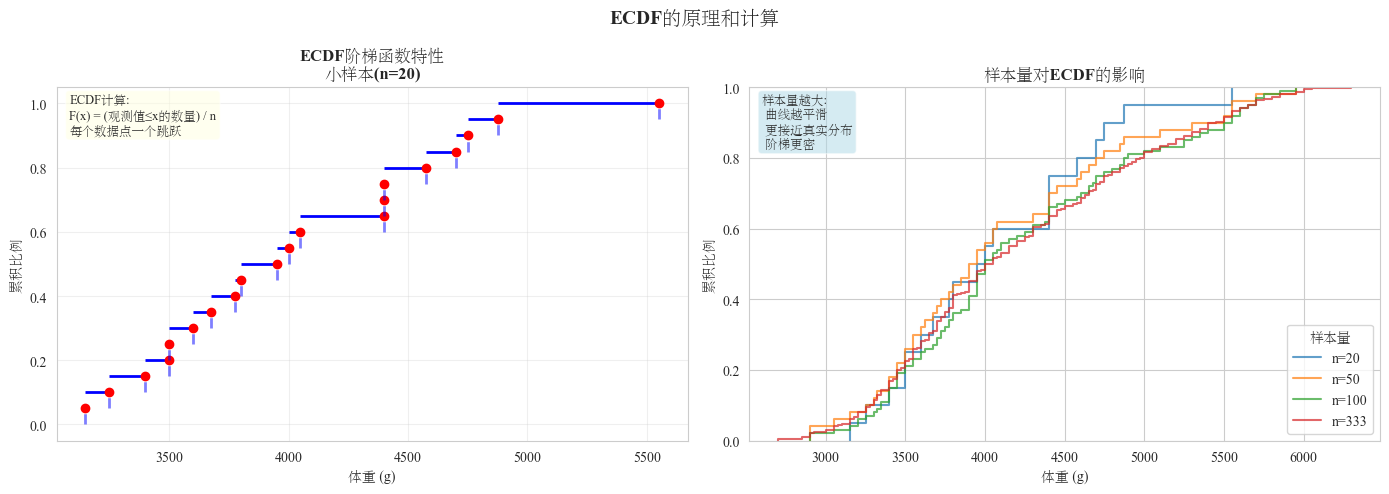

In [17]:
# ============================================================
# 额外演示：ECDF原理和计算
# ============================================================
print("\n" + "=" * 60)  # 打印60个等号作为分隔线，前面加换行符
print("ECDF原理演示")  # 打印说明，介绍ECDF原理演示
print("=" * 60)  # 打印60个等号作为分隔线

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))  # 创建1x2子图画布，尺寸为14x5英寸
fig3.suptitle('ECDF的原理和计算', fontsize=14,
              fontweight='bold')  # 设置画布总标题，字体大小14，加粗

# 左图：小样本展示ECDF的阶梯特性
ax = axes3[0]  # 选择第1个子图（左图）
small_sample = penguins.sample(
    n=20, random_state=42)['body_mass_g'].sort_values()  # 从企鹅数据集随机抽取20个体重样本并排序
# 手动绘制ECDF
for i, value in enumerate(small_sample):  # 遍历样本数据
    proportion = (i + 1) / len(small_sample)  # 计算累积比例，F(x) = (观测值≤x的数量) / n
    if i > 0:  # 对于非第一个点，绘制水平线
        ax.hlines(
            proportion,
            small_sample.iloc[i - 1],
            value,  # 从前一个点到当前点绘制水平线
            colors='blue',
            linewidth=2)  # 蓝色，线宽2
    ax.vlines(
        value,
        (i) / len(small_sample) if i > 0 else 0,  # 绘制垂直虚线，从前一比例到当前比例
        proportion,
        colors='blue',
        linewidth=2,
        linestyles='dashed',
        alpha=0.5)  # 蓝色虚线，透明度0.5
    ax.plot(value, proportion, 'ro', markersize=6)  # 在每个数据点绘制红色圆点，标记跳跃点

ax.set_title('ECDF阶梯函数特性\n小样本(n=20)', fontsize=12,
             fontweight='bold')  # 设置标题，说明ECDF阶梯特性，字体大小12，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('累积比例', fontsize=10)  # 设置y轴标签为“累积比例”，字体大小10
ax.grid(alpha=0.3)  # 添加网格线，透明度0.3
ax.text(
    0.02,
    0.98,
    'ECDF计算:\nF(x) = (观测值≤x的数量) / n\n每个数据点一个跳跃',  # 添加文本框，说明ECDF计算公式
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',  # 使用子图相对坐标，字体大小9，顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightyellow',
              alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5

# 右图：样本量对ECDF的影响
ax = axes3[1]  # 选择第2个子图（右图）
for n in [20, 50, 100, 333]:  # 循环不同样本量
    sample = penguins.sample(n=n, random_state=42)  # 从企鹅数据集随机抽取n个样本，固定随机种子
    sns.ecdfplot(
        data=sample,
        x='body_mass_g',
        ax=ax,  # 绘制体重ECDF曲线
        label=f'n={n}',
        alpha=0.7)  # 添加样本量标签，透明度0.7
ax.set_title('样本量对ECDF的影响', fontsize=12,
             fontweight='bold')  # 设置标题，说明样本量影响，字体大小12，加粗
ax.set_xlabel('体重 (g)', fontsize=10)  # 设置x轴标签为“体重 (g)”，字体大小10
ax.set_ylabel('累积比例', fontsize=10)  # 设置y轴标签为“累积比例”，字体大小10
ax.legend(title='样本量', loc='lower right')  # 添加图例，标题为“样本量”，位于右下角
ax.text(
    0.02,
    0.98,
    '样本量越大:\n 曲线越平滑\n 更接近真实分布\n 阶梯更密',  # 添加文本框，说明样本量对ECDF的影响
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',  # 使用子图相对坐标，字体大小9，顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightblue',
              alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示整个画布


ECDF实用案例


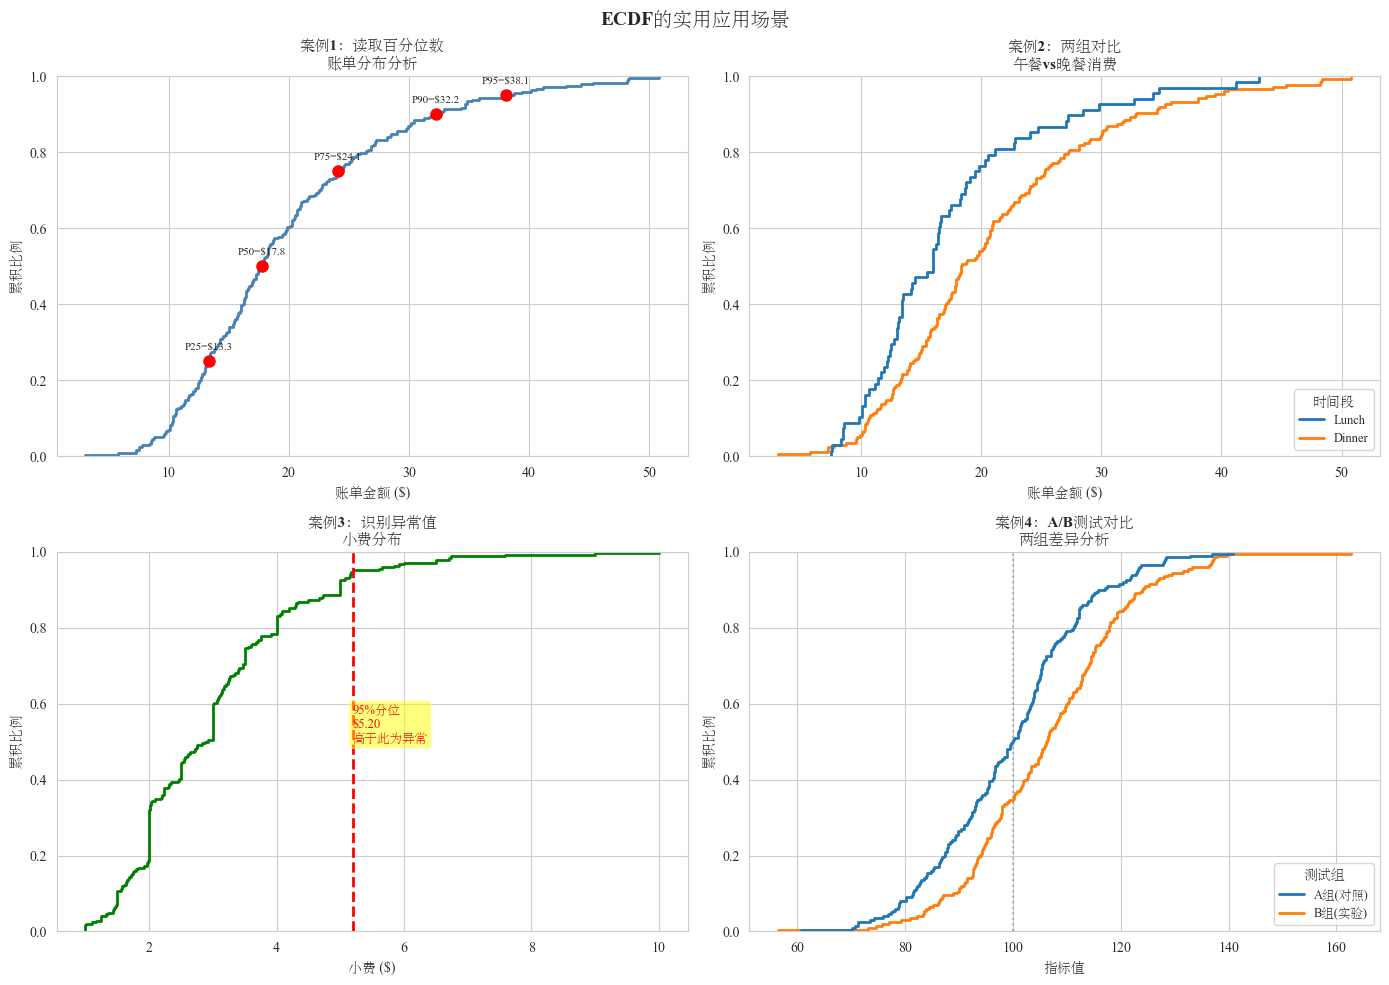

In [23]:
# ============================================================
# ECDF应用案例
# ============================================================
print("\n" + "="*60)
print("ECDF实用案例")
print("="*60)

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))
fig4.suptitle('ECDF的实用应用场景', fontsize=14, fontweight='bold')

# 案例1：读取百分位数
ax = axes4[0, 0]
sns.ecdfplot(data=tips, x='total_bill', ax=ax, color='steelblue', linewidth=2)
# 标注特定百分位
percentiles = [25, 50, 75, 90, 95]
for p in percentiles:
    value = tips['total_bill'].quantile(p/100)
    ax.plot(value, p/100, 'ro', markersize=8)
    ax.text(value, p/100 + 0.03, f'P{p}=${value:.1f}', 
           ha='center', fontsize=8)
ax.set_title('案例1：读取百分位数\n账单分布分析', fontsize=11, fontweight='bold')
ax.set_xlabel('账单金额 ($)', fontsize=10)
ax.set_ylabel('累积比例', fontsize=10)

# 案例2：对比两组
ax = axes4[0, 1]
sns.ecdfplot(data=tips, x='total_bill', hue='time', ax=ax, linewidth=2)
ax.set_title('案例2：两组对比\n午餐vs晚餐消费', fontsize=11, fontweight='bold')
ax.set_xlabel('账单金额 ($)', fontsize=10)
ax.set_ylabel('累积比例', fontsize=10)
sns.move_legend(ax, loc='lower right', fontsize=9, title='时间段')

# 案例3：识别异常值
ax = axes4[1, 0]
sns.ecdfplot(data=tips, x='tip', ax=ax, color='green', linewidth=2)
# 标注极端值
q95 = tips['tip'].quantile(0.95)
ax.axvline(x=q95, color='red', linestyle='--', linewidth=2)
ax.text(q95, 0.5, f'95%分位\n${q95:.2f}\n高于此为异常', 
       ha='left', fontsize=9, color='red',
       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
ax.set_title('案例3：识别异常值\n小费分布', fontsize=11, fontweight='bold')
ax.set_xlabel('小费 ($)', fontsize=10)
ax.set_ylabel('累积比例', fontsize=10)

# 案例4：A/B测试对比
ax = axes4[1, 1]
# 模拟A/B测试数据
np.random.seed(42)
group_a = pd.DataFrame({
    'value': np.random.normal(100, 15, 200),
    'group': 'A组(对照)'
})
group_b = pd.DataFrame({
    'value': np.random.normal(105, 15, 200),
    'group': 'B组(实验)'
})
ab_test = pd.concat([group_a, group_b])
sns.ecdfplot(data=ab_test, x='value', hue='group', ax=ax, linewidth=2)
ax.axvline(x=100, color='gray', linestyle=':', alpha=0.5)
ax.set_title('案例4：A/B测试对比\n两组差异分析', fontsize=11, fontweight='bold')
ax.set_xlabel('指标值', fontsize=10)
ax.set_ylabel('累积比例', fontsize=10)
sns.move_legend(ax, loc='lower right', fontsize=9, title='测试组')

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 打印重要参数总结
# ============================================================
print("\n" + "="*60)
print("Seaborn ecdfplot 核心参数总结 (v0.13.2+)")
print("="*60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x: 数值变量(必需)
   - hue: 分组变量
   - weights: 权重数组

2. 统计类型: ⭐⭐⭐
   - stat: Y轴统计量
     * 'proportion': 比例0-1(默认)
     * 'count': 累积计数
     * 'percent': 百分比0-100

3. 补累积:
   - complementary: 补累积分布(True/False)
     * True: 显示1 - ECDF
     * 显示"大于x"的比例
     * 适合尾部分析

4. 坐标轴:
   - log_scale: 对数坐标(True/False或(x_bool, y_bool))
     * 处理偏态数据

5. 样式参数:
   - color: 单一颜色
   - palette: 调色板(配合hue)
   - linewidth: 线宽
   - linestyle: 线型
   - alpha: 透明度

6. ECDF原理:
   - 经验累积分布函数
   - F(x) = (观测值≤x的数量) / n
   - 阶梯函数，每个观测值一个跳跃
   - 无参数估计，直接从数据计算

7. ECDF vs 其他分布图:
   ┌──────────────┬────────────┬────────────┬────────────┐
   │   特性       │   Hist     │    KDE     │    ECDF    │
   ├──────────────┼────────────┼────────────┼────────────┤
   │ 类型         │  密度图    │  密度图    │  累积图    │
   │ 平滑度       │  不平滑    │  平滑      │  阶梯      │
   │ 参数依赖     │  bins      │  bandwidth │  无        │
   │ 数据保真     │  低        │  中        │  高        │
   │ 读百分位     │  难        │  难        │  容易      │
   │ 直观性       │  高        │  高        │  中        │
   │ 适用场景     │  探索分布  │  展示报告  │  统计分析  │
   └──────────────┴────────────┴────────────┴────────────┘

8. ECDF的优势: ⭐⭐⭐
   ✓ 无参数方法，不依赖bins或bandwidth
   ✓ 完全保留数据信息
   ✓ 易于读取百分位数
   ✓ 对比多组时非常清晰
   ✓ 样本量大小影响小
   ✓ 可直接对比理论分布

9. ECDF的劣势:
   ✗ 不如直方图/KDE直观
   ✗ 阶梯状，视觉不够平滑
   ✗ 不易看出分布的峰
   ✗ 需要一定统计知识理解

10. 实用应用场景: ⭐⭐⭐
   - 百分位数分析
     * 直接读取任意百分位
     * 如中位数、四分位数
   - 多组对比
     * 清晰对比不同组的分布
     * 看哪组"领先"
   - 异常值检测
     * 识别极端值
     * 尾部分析
   - A/B测试
     * 对比实验组和对照组
     * 全面评估差异
   - 正态性检验
     * 与理论分布对比
     * Q-Q图的替代
   - 时间序列分析
     * 累积指标
     * 趋势分析

11. 读取信息技巧:
   - 水平读：给定x，找对应的累积比例
   - 垂直读：给定比例(如0.5)，找对应的x值(中位数)
   - 斜率陡峭：该区域数据密集
   - 斜率平缓：该区域数据稀疏
   - 左移：整体偏小
   - 右移：整体偏大

12. 与其他图表组合:
   - ECDF + Histogram: 累积+分布
   - ECDF + KDE: 累积+密度
   - ECDF + Scatter: 累积+原始点
   - ECDF + 理论分布: 实际vs理论

13. 最佳实践:
   ⭐ 添加参考线(0.25, 0.5, 0.75)便于读取
   ⭐ 多组对比时用不同颜色
   ⭐ 标注关键百分位数
   ⭐ 结合其他图表验证
   ⭐ complementary用于尾部分析
   ⭐ 样本量小(<30)时慎用

14. 常见用途总结:
   快速判断 → 50%在哪里？(中位数)
   对比分组 → 哪组"赢"了？
   异常检测 → 95%分位以上是异常
   分位数 → 直接从图上读取
   正态性 → 与对角线对比
""")


Seaborn ecdfplot 核心参数总结 (v0.13.2+)

1. 基础参数:
   - data: 数据源(DataFrame)
   - x: 数值变量(必需)
   - hue: 分组变量
   - weights: 权重数组

2. 统计类型: ⭐⭐⭐
   - stat: Y轴统计量
     * 'proportion': 比例0-1(默认)
     * 'count': 累积计数
     * 'percent': 百分比0-100

3. 补累积:
   - complementary: 补累积分布(True/False)
     * True: 显示1 - ECDF
     * 显示"大于x"的比例
     * 适合尾部分析

4. 坐标轴:
   - log_scale: 对数坐标(True/False或(x_bool, y_bool))
     * 处理偏态数据

5. 样式参数:
   - color: 单一颜色
   - palette: 调色板(配合hue)
   - linewidth: 线宽
   - linestyle: 线型
   - alpha: 透明度

6. ECDF原理:
   - 经验累积分布函数
   - F(x) = (观测值≤x的数量) / n
   - 阶梯函数，每个观测值一个跳跃
   - 无参数估计，直接从数据计算

7. ECDF vs 其他分布图:
   ┌──────────────┬────────────┬────────────┬────────────┐
   │   特性       │   Hist     │    KDE     │    ECDF    │
   ├──────────────┼────────────┼────────────┼────────────┤
   │ 类型         │  密度图    │  密度图    │  累积图    │
   │ 平滑度       │  不平滑    │  平滑      │  阶梯      │
   │ 参数依赖     │  bins      │  bandwidth │  无        │
   │ 数据保真     │  低        │  中        │  高      

## displot

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# 加载数据集
penguins = sns.load_dataset('penguins').dropna()
tips = sns.load_dataset('tips')

print("="*60)
print("Displot: Seaborn的分布图大师")
print("="*60)
print(f"\nPenguins数据集: {penguins.shape}")
print(f"Tips数据集: {tips.shape}")
print(f"\nDisplot特点:")
print("✓ Figure-level函数，自动创建画布")
print("✓ 支持多种kind类型(hist/kde/ecdf)")
print("✓ 强大的分面功能(col/row)")
print("✓ 可组合多种分布图\n")

Displot: Seaborn的分布图大师

Penguins数据集: (333, 7)
Tips数据集: (244, 7)

Displot特点:
✓ Figure-level函数，自动创建画布
✓ 支持多种kind类型(hist/kde/ecdf)
✓ 强大的分面功能(col/row)
✓ 可组合多种分布图



画布 1: 三种基础图表类型 (kind参数)
------------------------------------------------------------


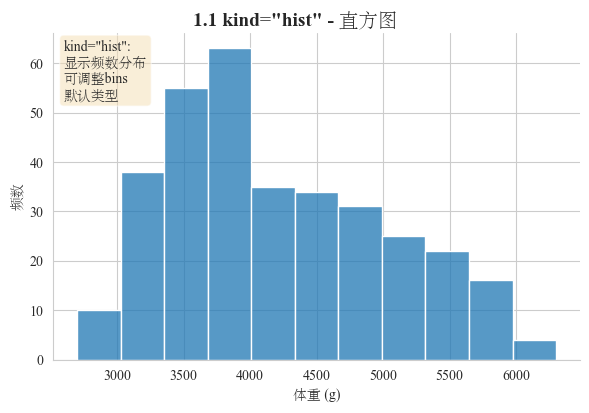

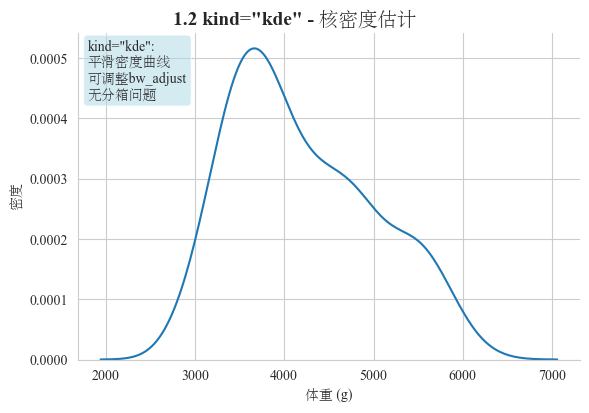

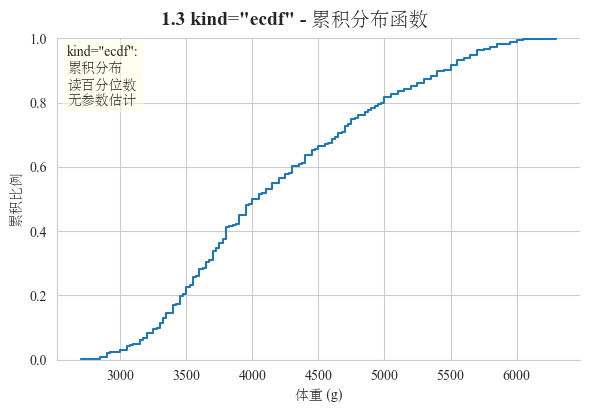

In [20]:
# ============================================================
# 画布 1: kind参数 - 三种基础类型
# ============================================================
print("画布 1: 三种基础图表类型 (kind参数)")  # 打印说明，介绍displot的kind参数功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 1.1 kind='hist' ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                kind='hist',  # 设置图表类型为直方图
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5，宽度为高度的1.5倍
g.fig.suptitle('1.1 kind="hist" - 直方图', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
g.ax.text(0.02,  # 在图表左上角添加文本框，x坐标0.02
          0.98,  # y坐标0.98，顶部对齐
          'kind="hist":\n显示频数分布\n可调整bins\n默认类型',  # 说明kind=hist的直方图特性
          transform=g.ax.transAxes,  # 使用图表相对坐标系
          fontsize=10,  # 字体大小10
          verticalalignment='top',  # 文本顶部对齐
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角背景框，小麦色，透明度0.5
plt.show()  # 显示直方图

# ========== 1.2 kind='kde' ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                kind='kde',  # 设置图表类型为核密度估计
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5
g.fig.suptitle('1.2 kind="kde" - 核密度估计', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '密度')  # 设置x轴标签为“体重 (g)”，y轴标签为“密度”
g.ax.text(0.02,  # 在图表左上角添加文本框，x坐标0.02
          0.98,  # y坐标0.98，顶部对齐
          'kind="kde":\n平滑密度曲线\n可调整bw_adjust\n无分箱问题',  # 说明kind=kde的核密度估计特性
          transform=g.ax.transAxes,  # 使用图表相对坐标系
          fontsize=10,  # 字体大小10
          verticalalignment='top',  # 文本顶部对齐
          bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5
plt.show()  # 显示核密度估计图

# ========== 1.3 kind='ecdf' ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                kind='ecdf',  # 设置图表类型为累积分布函数
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5
g.fig.suptitle('1.3 kind="ecdf" - 累积分布函数', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '累积比例')  # 设置x轴标签为“体重 (g)”，y轴标签为“累积比例”
g.ax.text(0.02,  # 在图表左上角添加文本框，x坐标0.02
          0.98,  # y坐标0.98，顶部对齐
          'kind="ecdf":\n累积分布\n读百分位数\n无参数估计',  # 说明kind=ecdf的累积分布函数特性
          transform=g.ax.transAxes,  # 使用图表相对坐标系
          fontsize=10,  # 字体大小10
          verticalalignment='top',  # 文本顶部对齐
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5
plt.show()  # 显示累积分布函数图


画布 2: hue参数 - 分组展示
------------------------------------------------------------


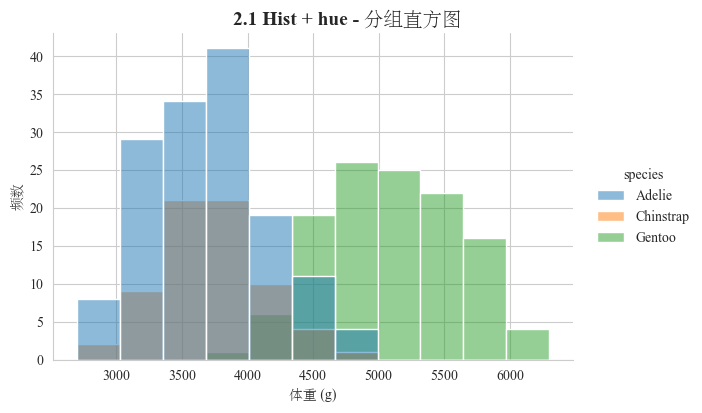

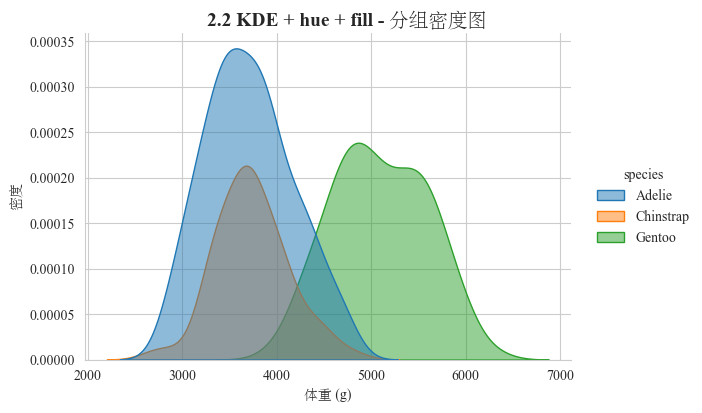

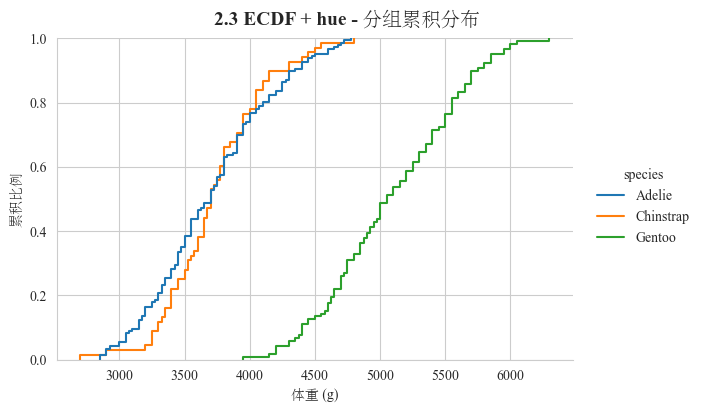

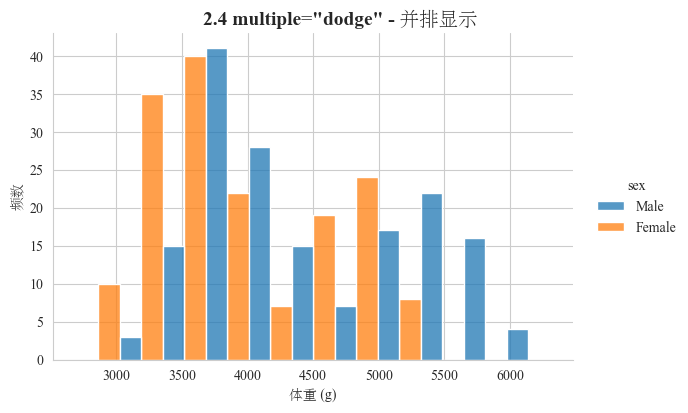

In [21]:
# ============================================================
# 画布 2: hue参数 - 分组展示
# ============================================================
print("\n画布 2: hue参数 - 分组展示")  # 打印说明，介绍hue参数的分组展示功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 2.1 hist + hue ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                hue='species',  # 按物种分组，自动分配不同颜色
                kind='hist',  # 设置图表类型为直方图
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5，宽度为高度的1.5倍
g.fig.suptitle('2.1 Hist + hue - 分组直方图', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明分组直方图效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
plt.show()  # 显示分组直方图

# ========== 2.2 kde + hue + fill ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                hue='species',  # 按物种分组，自动分配不同颜色
                kind='kde',  # 设置图表类型为核密度估计
                fill=True,  # 填充KDE曲线下区域
                alpha=0.5,  # 设置填充透明度为0.5
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5
g.fig.suptitle('2.2 KDE + hue + fill - 分组密度图', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明分组密度图效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '密度')  # 设置x轴标签为“体重 (g)”，y轴标签为“密度”
plt.show()  # 显示分组核密度估计图

# ========== 2.3 ecdf + hue ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                hue='species',  # 按物种分组，自动分配不同颜色
                kind='ecdf',  # 设置图表类型为累积分布函数
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5
g.fig.suptitle('2.3 ECDF + hue - 分组累积分布', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明分组累积分布效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '累积比例')  # 设置x轴标签为“体重 (g)”，y轴标签为“累积比例”
plt.show()  # 显示分组累积分布函数图

# ========== 2.4 multiple参数 ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                hue='sex',  # 按性别分组，自动分配不同颜色
                kind='hist',  # 设置图表类型为直方图
                multiple='dodge',  # 设置分组直方图并排显示
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5
g.fig.suptitle('2.4 multiple="dodge" - 并排显示', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明并排直方图效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
plt.show()  # 显示并排分组直方图


画布 3: col参数 - 列分面
------------------------------------------------------------


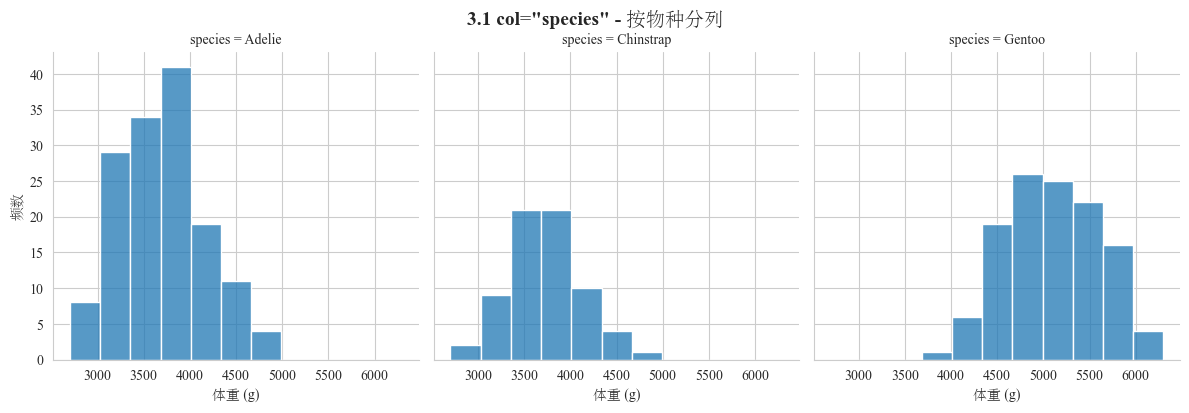

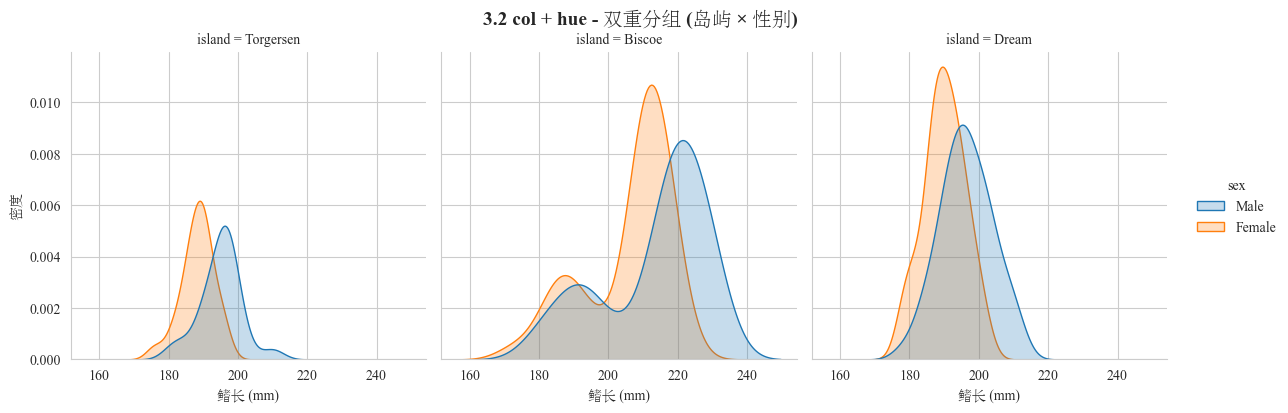

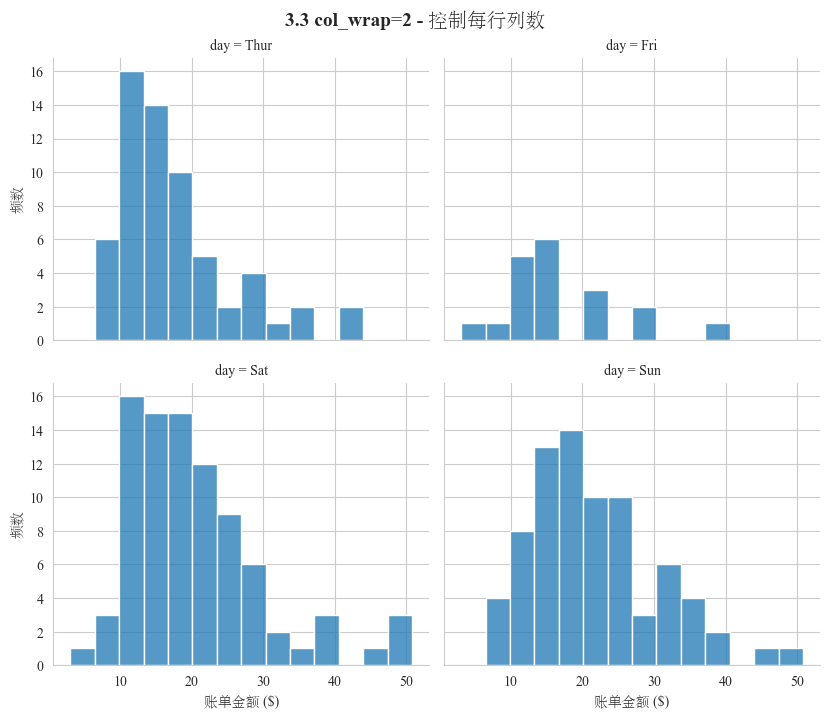

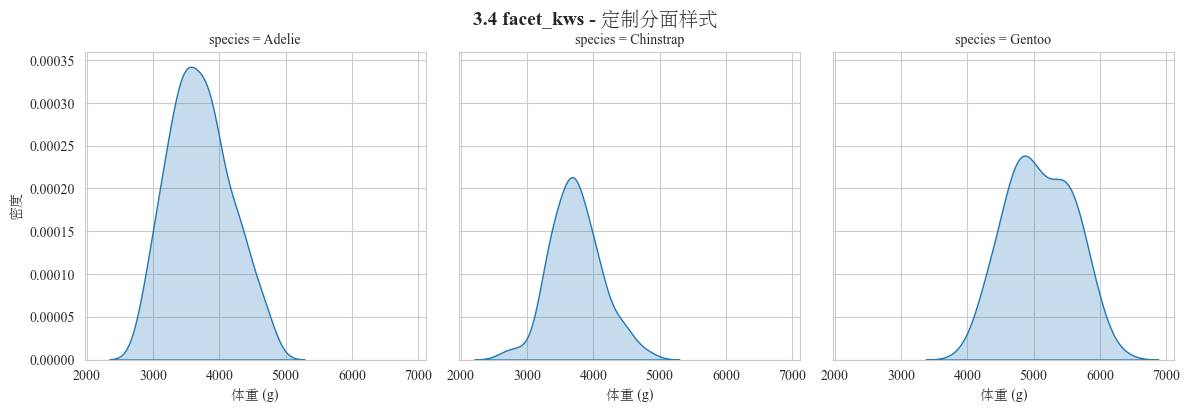

In [22]:
# ============================================================
# 画布 3: col参数 - 列分面
# ============================================================
print("\n画布 3: col参数 - 列分面")  # 打印说明，介绍col参数的分面展示功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 3.1 基础列分面 ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                col='species',  # 按物种分列创建子图
                kind='hist',  # 设置图表类型为直方图
                height=4,  # 设置每个子图高度为4英寸
                aspect=1)  # 设置宽高比为1，子图为正方形
g.fig.suptitle('3.1 col="species" - 按物种分列', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明按物种分列效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
plt.show()  # 显示按物种分列的直方图

# ========== 3.2 col + hue双重分组 ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='flipper_length_mm',  # x轴为鳍长
                col='island',  # 按岛屿分列创建子图
                hue='sex',  # 按性别分组，自动分配不同颜色
                kind='kde',  # 设置图表类型为核密度估计
                fill=True,  # 填充KDE曲线下区域
                height=4,  # 设置每个子图高度为4英寸
                aspect=1)  # 设置宽高比为1，子图为正方形
g.fig.suptitle('3.2 col + hue - 双重分组 (岛屿 × 性别)', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明岛屿和性别双重分组效果，字体大小14，加粗
g.set_axis_labels('鳍长 (mm)', '密度')  # 设置x轴标签为“鳍长 (mm)”，y轴标签为“密度”
plt.show()  # 显示按岛屿分列、性别分组的KDE图

# ========== 3.3 col_wrap控制换行 ==========
g = sns.displot(data=tips,  # 使用tips数据集
                x='total_bill',  # x轴为账单金额
                col='day',  # 按星期分列创建子图
                col_wrap=2,  # 每行显示2个子图，自动换行
                kind='hist',  # 设置图表类型为直方图
                height=3.5,  # 设置每个子图高度为3.5英寸
                aspect=1.2)  # 设置宽高比为1.2，子图略宽
g.fig.suptitle('3.3 col_wrap=2 - 控制每行列数', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明col_wrap控制换行效果，字体大小14，加粗
g.set_axis_labels('账单金额 ($)', '频数')  # 设置x轴标签为“账单金额 ($)”，y轴标签为“频数”
plt.show()  # 显示按星期分列、每行2列的直方图

# ========== 3.4 facet_kws定制分面 ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                col='species',  # 按物种分列创建子图
                kind='kde',  # 设置图表类型为核密度估计
                fill=True,  # 填充KDE曲线下区域
                height=4,  # 设置每个子图高度为4英寸
                aspect=1,  # 设置宽高比为1，子图为正方形
                facet_kws={'despine': False})  # 通过facet_kws设置分面样式，保留子图边框
g.fig.suptitle('3.4 facet_kws - 定制分面样式', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明定制分面样式效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '密度')  # 设置x轴标签为“体重 (g)”，y轴标签为“密度”
plt.show()  # 显示按物种分列、保留边框的KDE图


画布 4: row参数 - 行分面和网格
------------------------------------------------------------


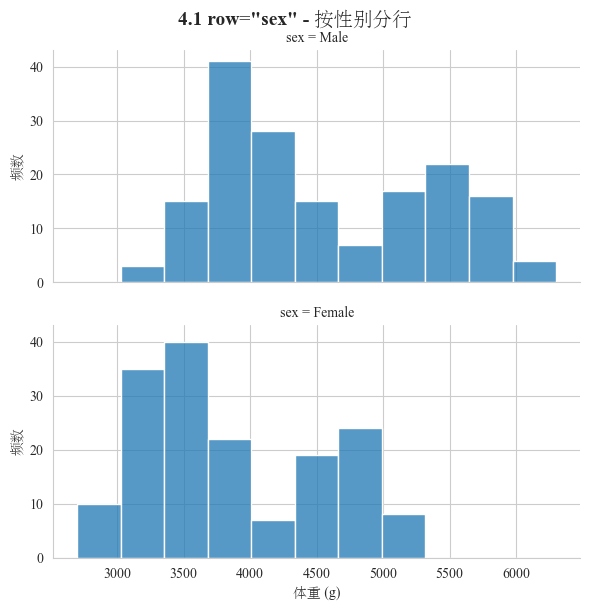

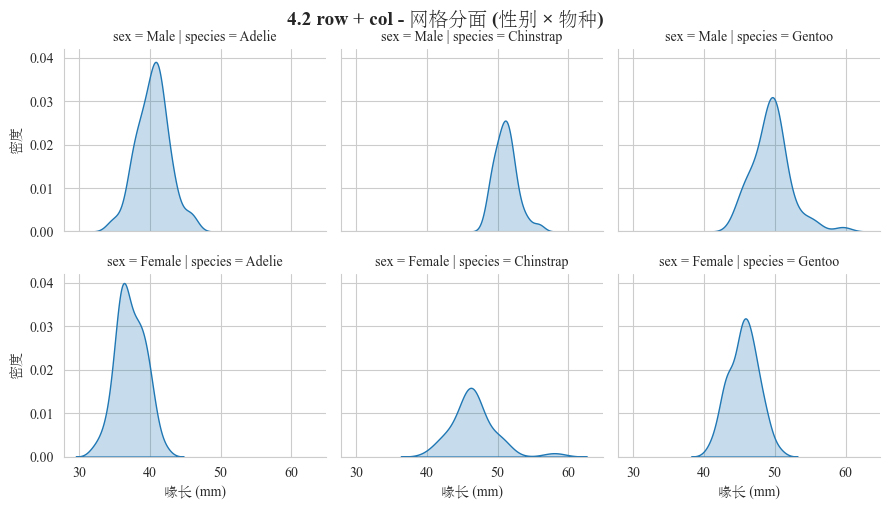


画布 5: rug参数 - 添加数据点标记
------------------------------------------------------------


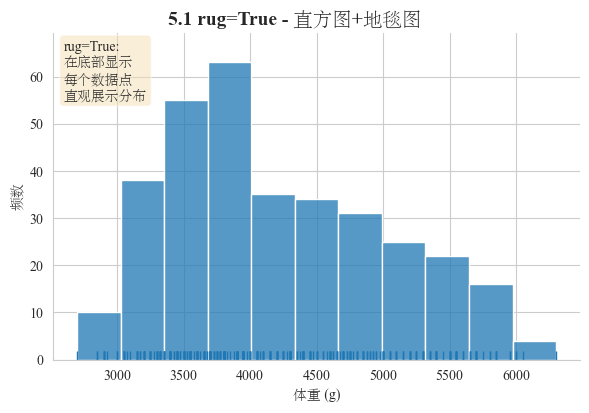

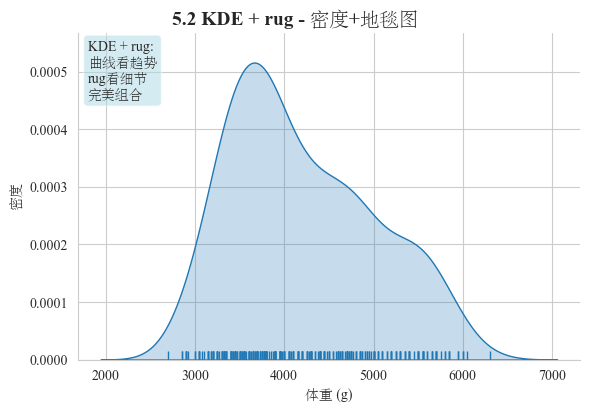

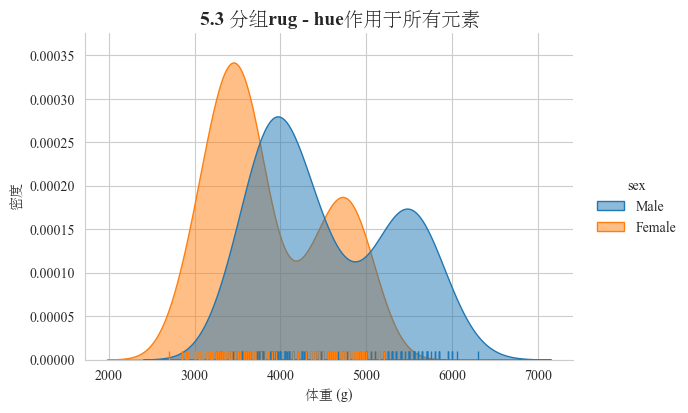

In [23]:
# ============================================================
# 画布 4: row参数 - 行分面和网格
# ============================================================
print("\n画布 4: row参数 - 行分面和网格")  # 打印说明，介绍row参数的行分面和网格展示功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 4.1 基础行分面 ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                row='sex',  # 按性别分行创建子图
                kind='hist',  # 设置图表类型为直方图
                height=3,  # 设置每个子图高度为3英寸
                aspect=2)  # 设置宽高比为2，子图宽度为高度的2倍
g.fig.suptitle('4.1 row="sex" - 按性别分行', fontsize=14, fontweight='bold', y=1.01)  # 设置画布标题，说明按性别分行效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
plt.show()  # 显示按性别分行的直方图

# ========== 4.2 row + col网格分面 ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='bill_length_mm',  # x轴为喙长
                row='sex',  # 按性别分行创建子图
                col='species',  # 按物种分列创建子图，形成网格
                kind='kde',  # 设置图表类型为核密度估计
                fill=True,  # 填充KDE曲线下区域
                height=2.5,  # 设置每个子图高度为2.5英寸
                aspect=1.2)  # 设置宽高比为1.2，子图略宽
g.fig.suptitle('4.2 row + col - 网格分面 (性别 × 物种)', fontsize=14, fontweight='bold', y=1.01)  # 设置画布标题，说明性别和物种网格分面效果，字体大小14，加粗
g.set_axis_labels('喙长 (mm)', '密度')  # 设置x轴标签为“喙长 (mm)”，y轴标签为“密度”
plt.show()  # 显示性别和物种网格分面的KDE图

# ============================================================
# 画布 5: rug参数 - 添加数据点标记
# ============================================================
print("\n画布 5: rug参数 - 添加数据点标记")  # 打印说明，介绍rug参数的数据点标记功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 5.1 hist + rug ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                kind='hist',  # 设置图表类型为直方图
                rug=True,  # 在x轴底部添加地毯图，标记每个数据点
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5，宽度为高度的1.5倍
g.fig.suptitle('5.1 rug=True - 直方图+地毯图', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明直方图与地毯图效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
g.ax.text(0.02,  # 在图表左上角添加文本框，x坐标0.02
          0.98,  # y坐标0.98，顶部对齐
          'rug=True:\n在底部显示\n每个数据点\n直观展示分布',  # 说明rug参数在地毯图中的作用
          transform=g.ax.transAxes,  # 使用图表相对坐标系
          fontsize=10,  # 字体大小10
          verticalalignment='top',  # 文本顶部对齐
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 圆角背景框，小麦色，透明度0.5
plt.show()  # 显示直方图与地毯图组合

# ========== 5.2 kde + rug ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                kind='kde',  # 设置图表类型为核密度估计
                fill=True,  # 填充KDE曲线下区域
                rug=True,  # 在x轴底部添加地毯图，标记每个数据点
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5
g.fig.suptitle('5.2 KDE + rug - 密度+地毯图', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明KDE与地毯图效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '密度')  # 设置x轴标签为“体重 (g)”，y轴标签为“密度”
g.ax.text(0.02,  # 在图表左上角添加文本框，x坐标0.02
          0.98,  # y坐标0.98，顶部对齐
          'KDE + rug:\n曲线看趋势\nrug看细节\n完美组合',  # 说明KDE与地毯图的组合效果
          transform=g.ax.transAxes,  # 使用图表相对坐标系
          fontsize=10,  # 字体大小10
          verticalalignment='top',  # 文本顶部对齐
          bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5
plt.show()  # 显示KDE与地毯图组合

# ========== 5.3 rug + hue ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                hue='sex',  # 按性别分组，自动分配不同颜色
                kind='kde',  # 设置图表类型为核密度估计
                fill=True,  # 填充KDE曲线下区域
                rug=True,  # 在x轴底部添加地毯图，按性别分组显示
                alpha=0.5,  # 设置填充透明度为0.5
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5
g.fig.suptitle('5.3 分组rug - hue作用于所有元素', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明分组地毯图效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '密度')  # 设置x轴标签为“体重 (g)”，y轴标签为“密度”
plt.show()  # 显示分组KDE与分组地毯图组合


画布 6: 组合多种元素
------------------------------------------------------------


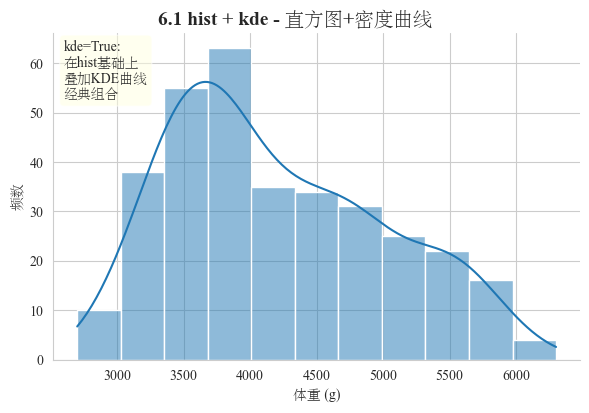

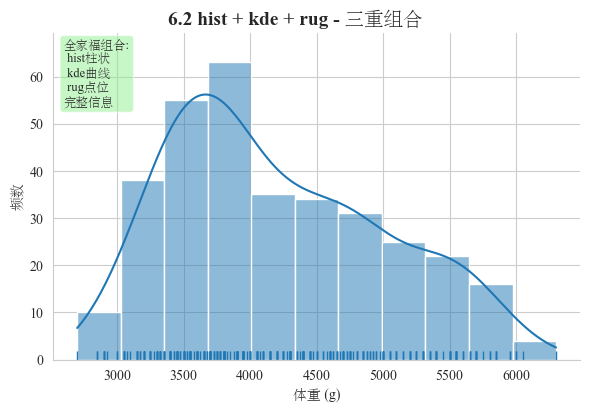

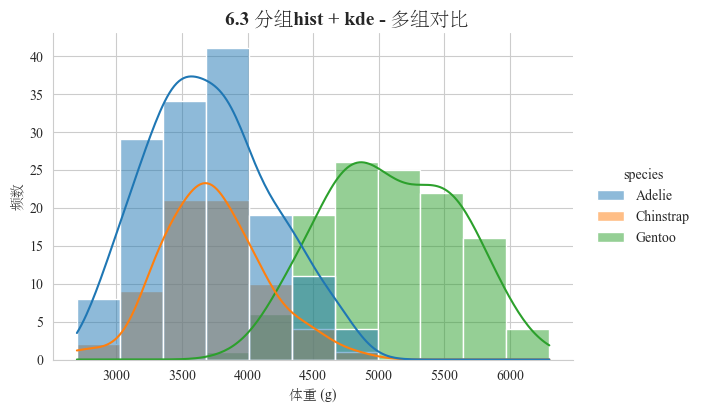

In [24]:
# ============================================================
# 画布 6: 组合多种元素
# ============================================================
print("\n画布 6: 组合多种元素")  # 打印说明，介绍多种元素组合展示功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 6.1 hist + kde组合 ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                kind='hist',  # 设置图表类型为直方图
                kde=True,  # 在直方图上叠加KDE曲线
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5，宽度为高度的1.5倍
g.fig.suptitle('6.1 hist + kde - 直方图+密度曲线', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明直方图与KDE组合效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
g.ax.text(0.02,  # 在图表左上角添加文本框，x坐标0.02
          0.98,  # y坐标0.98，顶部对齐
          'kde=True:\n在hist基础上\n叠加KDE曲线\n经典组合',  # 说明kde=True在直方图上叠加KDE的效果
          transform=g.ax.transAxes,  # 使用图表相对坐标系
          fontsize=10,  # 字体大小10
          verticalalignment='top',  # 文本顶部对齐
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5
plt.show()  # 显示直方图与KDE组合图

# ========== 6.2 hist + kde + rug全家福 ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                kind='hist',  # 设置图表类型为直方图
                kde=True,  # 在直方图上叠加KDE曲线
                rug=True,  # 在x轴底部添加地毯图，标记每个数据点
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5
g.fig.suptitle('6.2 hist + kde + rug - 三重组合', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明直方图、KDE和地毯图三重组合效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
g.ax.text(0.02,  # 在图表左上角添加文本框，x坐标0.02
          0.98,  # y坐标0.98，顶部对齐
          '全家福组合:\n hist柱状\n kde曲线\n rug点位\n完整信息',  # 说明三重组合（直方图、KDE、地毯图）的效果
          transform=g.ax.transAxes,  # 使用图表相对坐标系
          fontsize=9,  # 字体大小9
          verticalalignment='top',  # 文本顶部对齐
          bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 圆角背景框，浅绿色，透明度0.5
plt.show()  # 显示直方图、KDE和地毯图三重组合图

# ========== 6.3 分组全家福 ==========
g = sns.displot(data=penguins,  # 使用企鹅数据集
                x='body_mass_g',  # x轴为体重
                hue='species',  # 按物种分组，自动分配不同颜色
                kind='hist',  # 设置图表类型为直方图
                kde=True,  # 在直方图上叠加KDE曲线
                multiple='layer',  # 设置分组直方图为层叠显示，堆叠不同物种
                alpha=0.5,  # 设置直方图透明度为0.5以显示重叠区域
                height=4,  # 设置图表高度为4英寸
                aspect=1.5)  # 设置宽高比为1.5
g.fig.suptitle('6.3 分组hist + kde - 多组对比', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明分组直方图和KDE的对比效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
plt.show()  # 显示分组直方图与KDE组合图


画布 7: stat和bins参数
------------------------------------------------------------


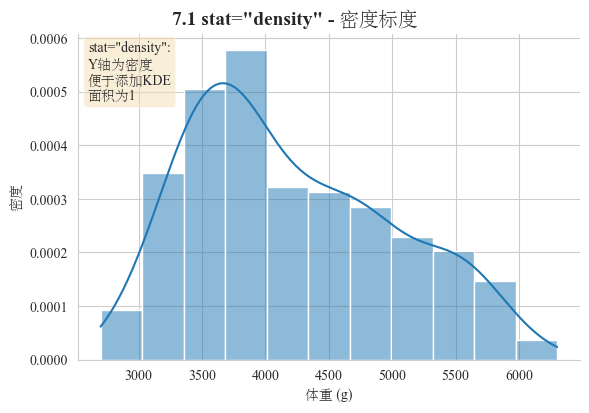

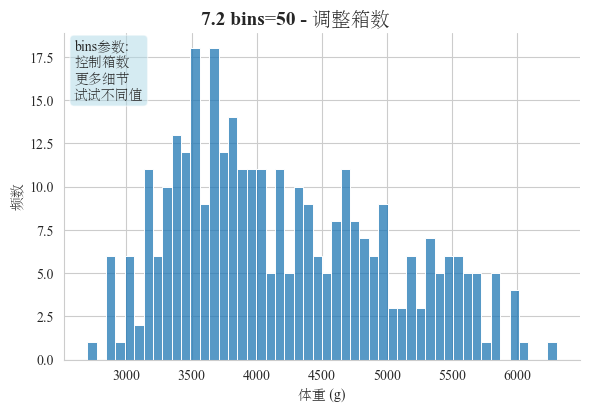

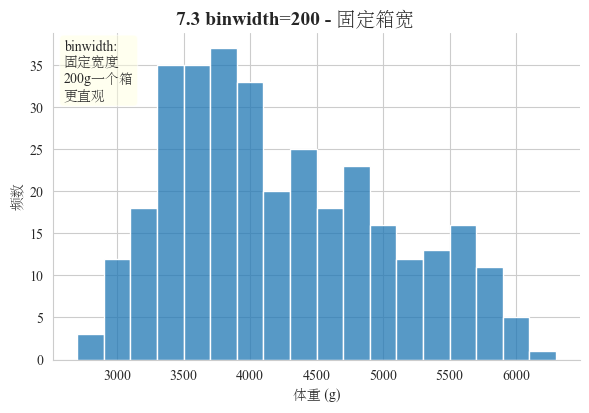

In [25]:
# ============================================================
# 画布 7: stat和bins参数
# ============================================================
print("\n画布 7: stat和bins参数")  # 打印说明，介绍stat和bins参数的功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 7.1 stat='density' ==========
g = sns.displot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    kind='hist',  # 设置图表类型为直方图
    stat='density',  # 设置y轴为密度，柱状图面积和为1
    kde=True,  # 在直方图上叠加KDE曲线
    height=4,  # 设置图表高度为4英寸
    aspect=1.5)  # 设置宽高比为1.5，宽度为高度的1.5倍
g.fig.suptitle('7.1 stat="density" - 密度标度',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明密度标度效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '密度')  # 设置x轴标签为“体重 (g)”，y轴标签为“密度”
g.ax.text(
    0.02,  # 在图表左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'stat="density":\nY轴为密度\n便于添加KDE\n面积为1',  # 说明stat=density的作用，便于与KDE结合
    transform=g.ax.transAxes,  # 使用图表相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='wheat',
              alpha=0.5))  # 圆角背景框，小麦色，透明度0.5
plt.show()  # 显示密度标度的直方图与KDE组合图

# ========== 7.2 bins参数 ==========
g = sns.displot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    kind='hist',  # 设置图表类型为直方图
    bins=50,  # 设置分箱数为50，增加柱状图细节
    height=4,  # 设置图表高度为4英寸
    aspect=1.5)  # 设置宽高比为1.5
g.fig.suptitle('7.2 bins=50 - 调整箱数', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明调整分箱数效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
g.ax.text(
    0.02,  # 在图表左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'bins参数:\n控制箱数\n更多细节\n试试不同值',  # 说明bins参数控制分箱数的效果
    transform=g.ax.transAxes,  # 使用图表相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightblue',
              alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5
plt.show()  # 显示调整分箱数的直方图

# ========== 7.3 binwidth参数 ==========
g = sns.displot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    kind='hist',  # 设置图表类型为直方图
    binwidth=200,  # 设置每个分箱宽度为200克
    height=4,  # 设置图表高度为4英寸
    aspect=1.5)  # 设置宽高比为1.5
g.fig.suptitle('7.3 binwidth=200 - 固定箱宽',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明固定分箱宽度效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
g.ax.text(
    0.02,  # 在图表左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'binwidth:\n固定宽度\n200g一个箱\n更直观',  # 说明binwidth参数固定分箱宽度的效果
    transform=g.ax.transAxes,  # 使用图表相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightyellow',
              alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5
plt.show()  # 显示固定分箱宽度的直方图


画布 8: 二维分布
------------------------------------------------------------


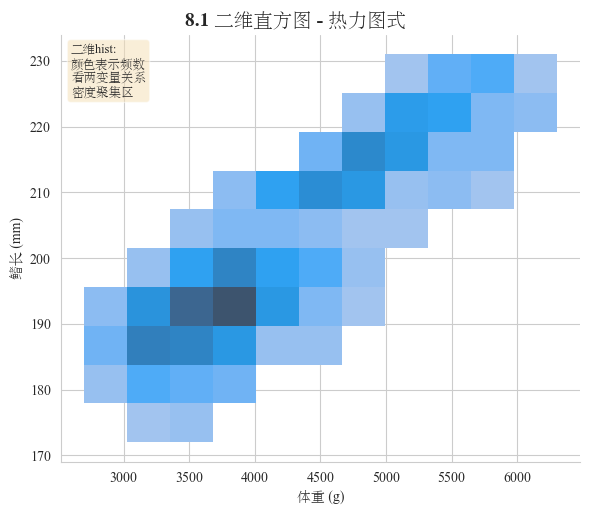

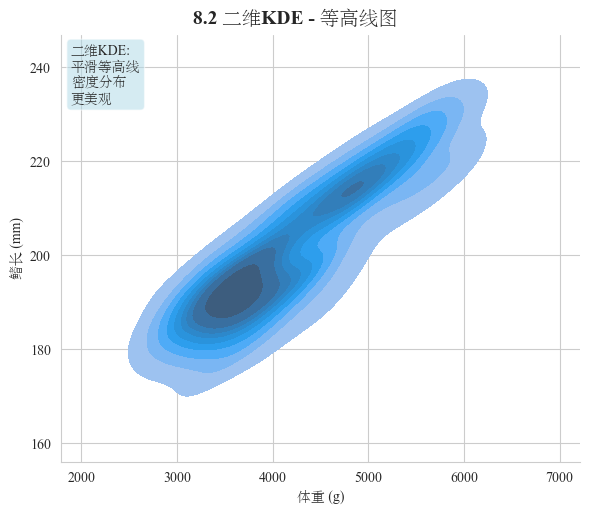

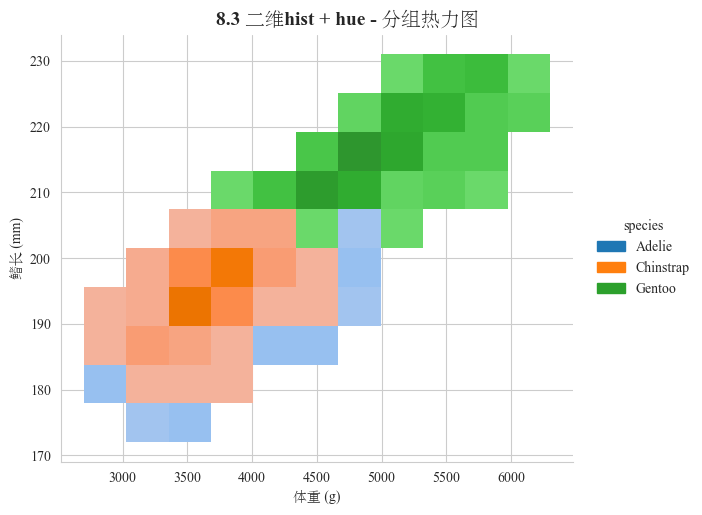

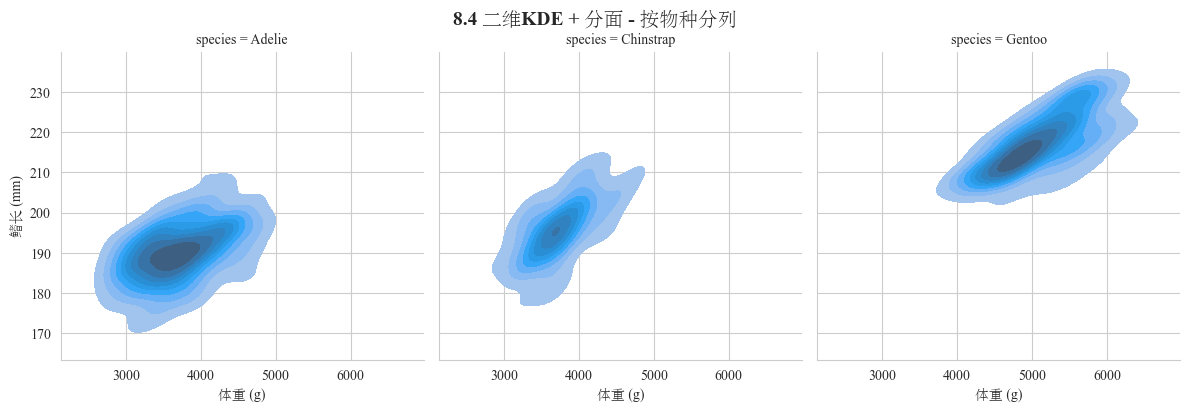

In [26]:
# ============================================================
# 画布 8: 二维分布
# ============================================================
print("\n画布 8: 二维分布")  # 打印说明，介绍二维分布的展示功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 8.1 二维直方图 ==========
g = sns.displot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
    kind='hist',  # 设置图表类型为二维直方图
    height=5,  # 设置图表高度为5英寸
    aspect=1.2)  # 设置宽高比为1.2，宽度略大于高度
g.fig.suptitle('8.1 二维直方图 - 热力图式', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明二维直方图效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax.text(
    0.02,  # 在图表左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    '二维hist:\n颜色表示频数\n看两变量关系\n密度聚集区',  # 说明二维直方图的热力图特性
    transform=g.ax.transAxes,  # 使用图表相对坐标系
    fontsize=9,  # 字体大小9
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='wheat',
              alpha=0.5))  # 圆角背景框，小麦色，透明度0.5
plt.show()  # 显示二维直方图

# ========== 8.2 二维KDE ==========
g = sns.displot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
    kind='kde',  # 设置图表类型为二维核密度估计
    fill=True,  # 填充KDE等高线区域
    height=5,  # 设置图表高度为5英寸
    aspect=1.2)  # 设置宽高比为1.2
g.fig.suptitle('8.2 二维KDE - 等高线图', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明二维KDE等高线效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax.text(
    0.02,  # 在图表左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    '二维KDE:\n平滑等高线\n密度分布\n更美观',  # 说明二维KDE的平滑等高线特性
    transform=g.ax.transAxes,  # 使用图表相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightblue',
              alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5
plt.show()  # 显示二维KDE图

# ========== 8.3 二维hist + hue ==========
g = sns.displot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
    hue='species',  # 按物种分组，自动分配不同颜色
    kind='hist',  # 设置图表类型为二维直方图
    height=5,  # 设置图表高度为5英寸
    aspect=1.2)  # 设置宽高比为1.2
g.fig.suptitle('8.3 二维hist + hue - 分组热力图',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明分组二维直方图效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
plt.show()  # 显示分组二维直方图

# ========== 8.4 二维KDE + 分面 ==========
g = sns.displot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
    col='species',  # 按物种分列创建子图
    kind='kde',  # 设置图表类型为二维核密度估计
    fill=True,  # 填充KDE等高线区域
    height=4,  # 设置每个子图高度为4英寸
    aspect=1)  # 设置宽高比为1，子图为正方形
g.fig.suptitle('8.4 二维KDE + 分面 - 按物种分列',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明分面二维KDE效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
plt.show()  # 显示按物种分列的二维KDE图


画布 9: height和aspect - 控制图表大小
------------------------------------------------------------


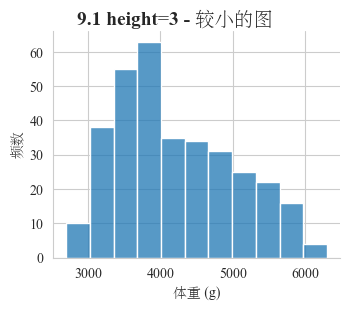

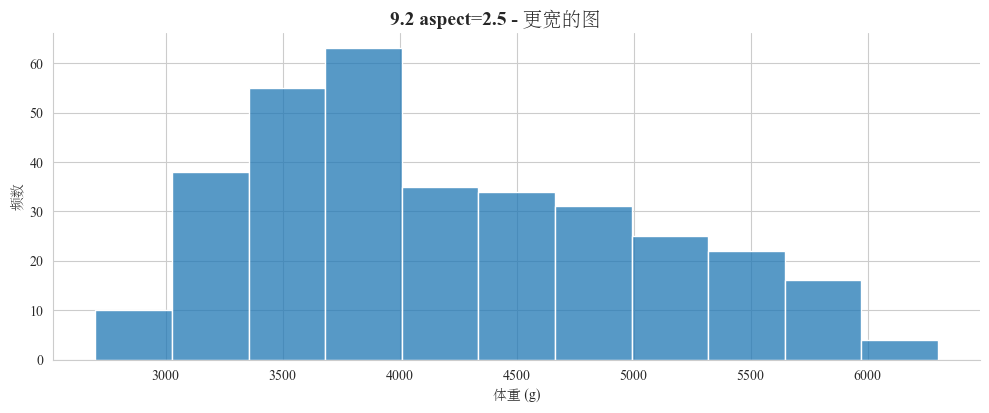

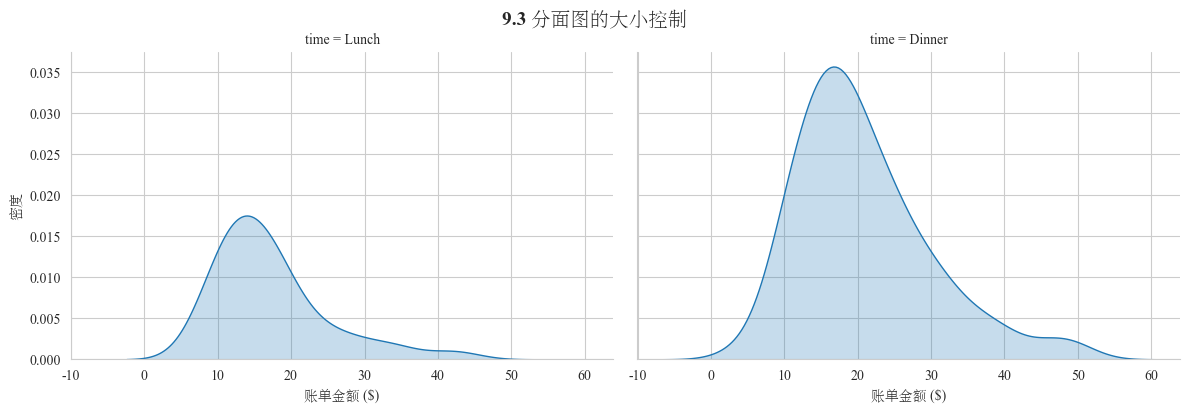

In [27]:
# ============================================================
# 画布 9: height和aspect控制大小
# ============================================================
print("\n画布 9: height和aspect - 控制图表大小")  # 打印说明，介绍height和aspect参数控制图表大小的功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 9.1 小图 ==========
g = sns.displot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    kind='hist',  # 设置图表类型为直方图
    height=3,  # 设置图表高度为3英寸，生成较小的图
    aspect=1.2)  # 设置宽高比为1.2，宽度略大于高度
g.fig.suptitle('9.1 height=3 - 较小的图', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明较小图表效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
plt.show()  # 显示较小的直方图

# ========== 9.2 宽图 ==========
g = sns.displot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    kind='hist',  # 设置图表类型为直方图
    height=4,  # 设置图表高度为4英寸
    aspect=2.5)  # 设置宽高比为2.5，生成较宽的图
g.fig.suptitle('9.2 aspect=2.5 - 更宽的图', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明较宽图表效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '频数')  # 设置x轴标签为“体重 (g)”，y轴标签为“频数”
plt.show()  # 显示较宽的直方图

# ========== 9.3 分面大小控制 ==========
g = sns.displot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴为账单金额
    col='time',  # 按时间（午餐/晚餐）分列创建子图
    kind='kde',  # 设置图表类型为核密度估计
    fill=True,  # 填充KDE曲线下区域
    height=4,  # 设置每个子图高度为4英寸
    aspect=1.5)  # 设置每个子图宽高比为1.5
g.fig.suptitle('9.3 分面图的大小控制', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明分面图大小控制效果，字体大小14，加粗
g.set_axis_labels('账单金额 ($)', '密度')  # 设置x轴标签为“账单金额 ($)”，y轴标签为“密度”
plt.show()  # 显示按时间分列的KDE分面图


画布 10: 综合应用案例
------------------------------------------------------------


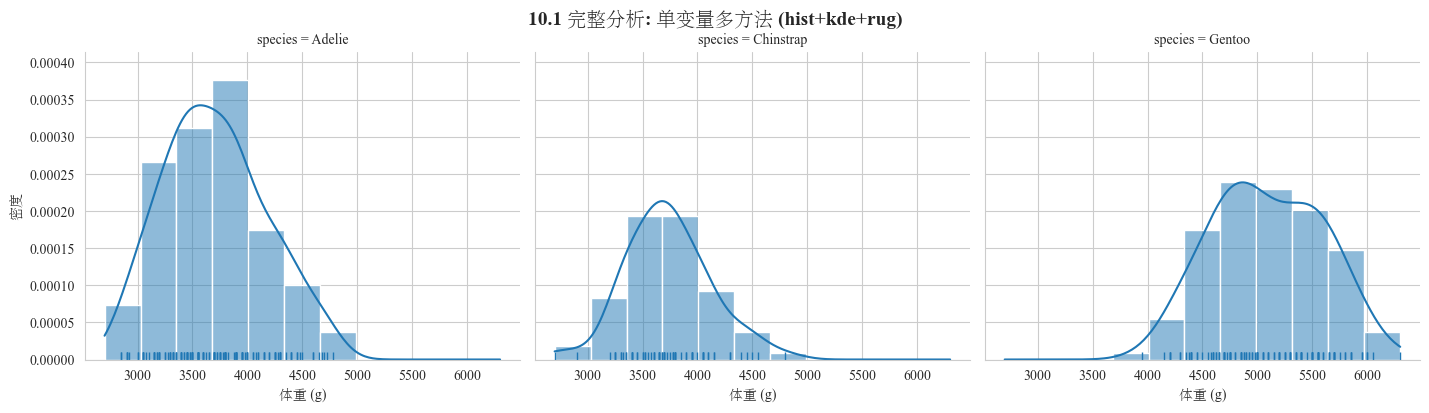

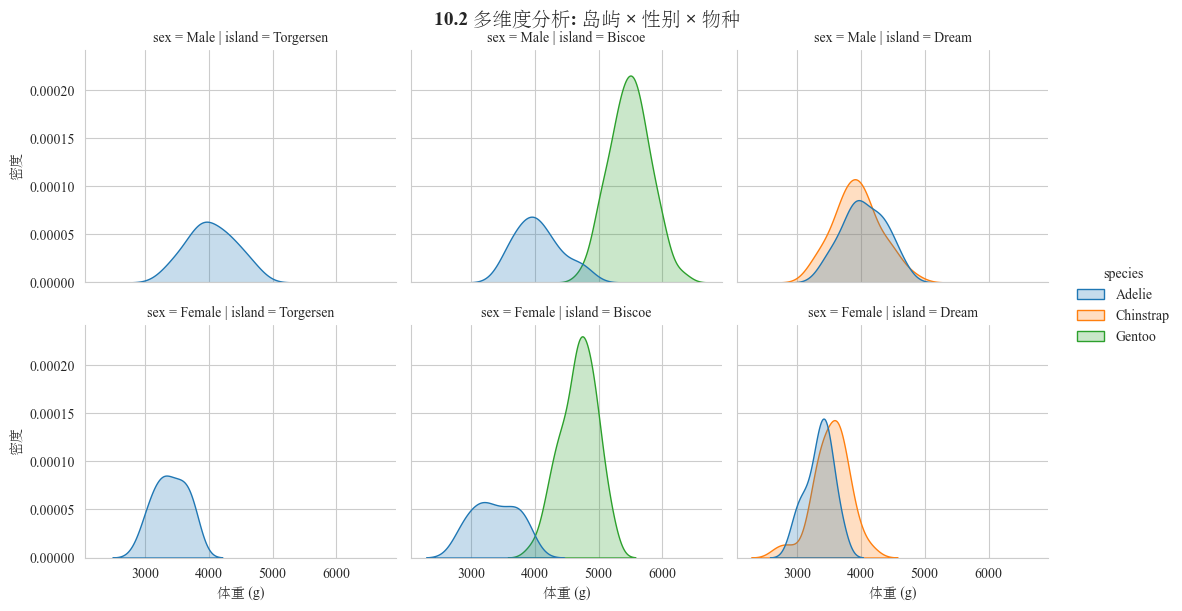

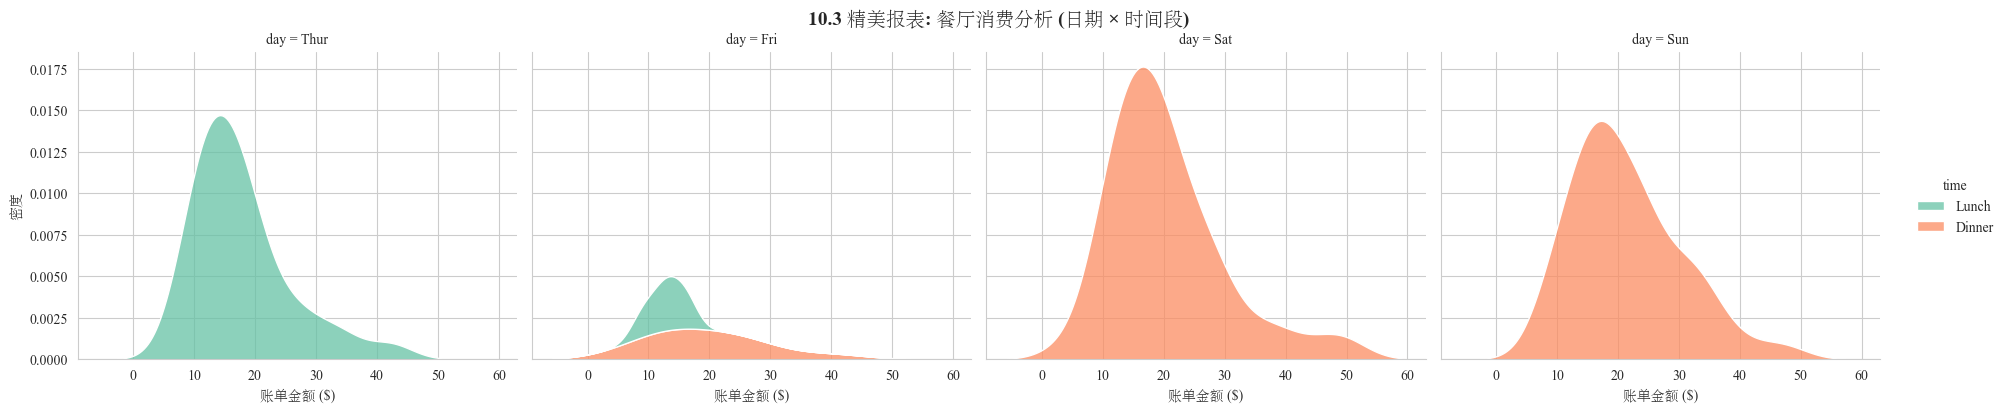

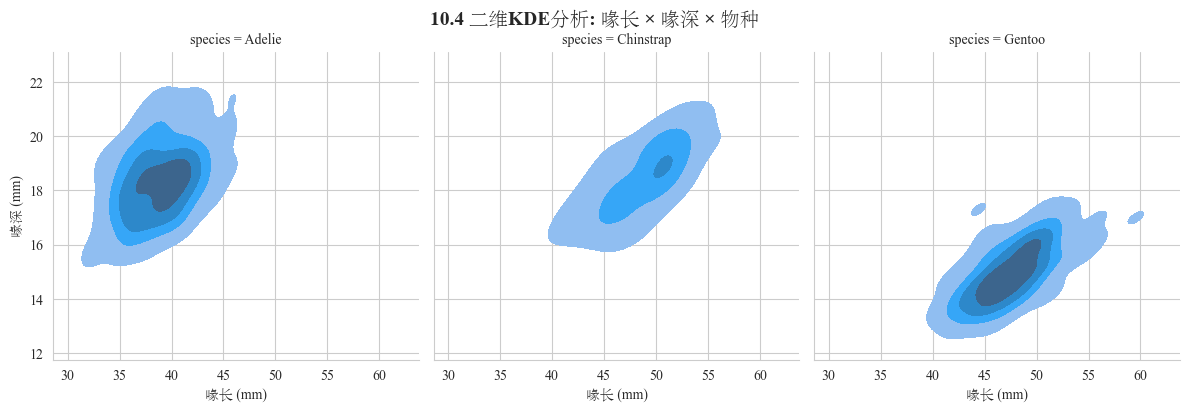


Displot vs 普通函数对比


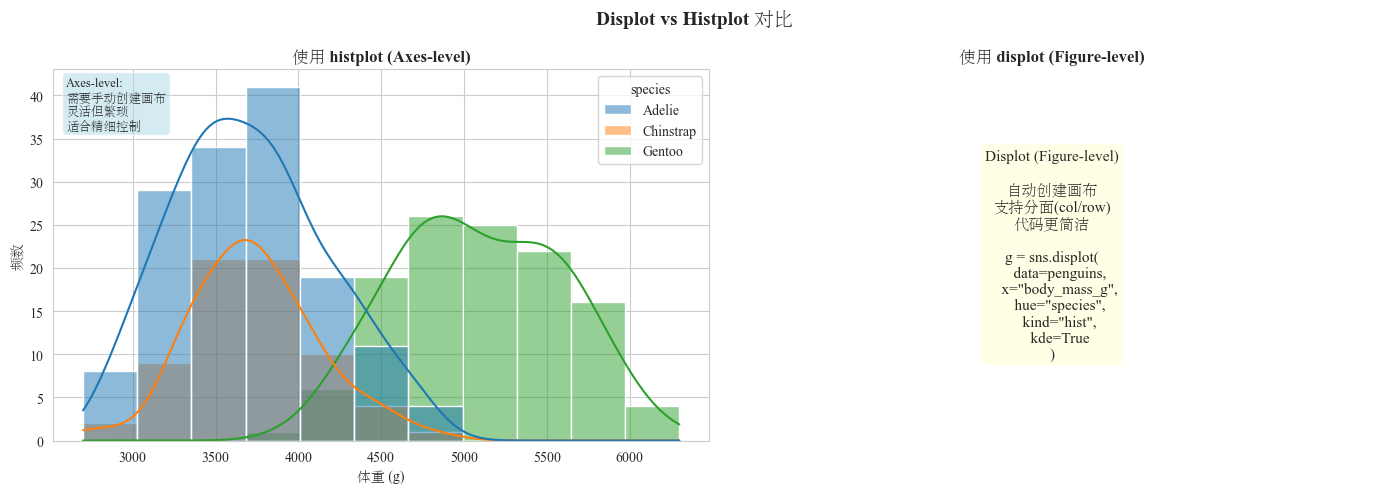

In [28]:
# ============================================================
# 画布 10: 综合应用案例
# ============================================================
print("\n画布 10: 综合应用案例")  # 打印说明，介绍综合应用案例
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 10.1 完整分析 - 单变量 ==========
g = sns.displot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    col='species',  # 按物种分列创建子图
    kind='hist',  # 设置图表类型为直方图
    kde=True,  # 在直方图上叠加KDE曲线
    rug=True,  # 在x轴底部添加地毯图，标记每个数据点
    stat='density',  # 设置y轴为密度，柱状图面积和为1
    height=4,  # 设置每个子图高度为4英寸
    aspect=1.2)  # 设置宽高比为1.2，子图略宽
g.fig.suptitle('10.1 完整分析: 单变量多方法 (hist+kde+rug)',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明单变量多方法组合效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '密度')  # 设置x轴标签为“体重 (g)”，y轴标签为“密度”
plt.show()  # 显示按物种分列的直方图、KDE和地毯图组合

# ========== 10.2 多维度分析 ==========
g = sns.displot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    col='island',  # 按岛屿分列创建子图
    row='sex',  # 按性别分行创建子图，形成网格
    hue='species',  # 按物种分组，自动分配不同颜色
    kind='kde',  # 设置图表类型为核密度估计
    fill=True,  # 填充KDE曲线下区域
    height=3,  # 设置每个子图高度为3英寸
    aspect=1.2)  # 设置宽高比为1.2
g.fig.suptitle('10.2 多维度分析: 岛屿 × 性别 × 物种',
               fontsize=14,
               fontweight='bold',
               y=1.01)  # 设置画布标题，说明多维度分析效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '密度')  # 设置x轴标签为“体重 (g)”，y轴标签为“密度”
plt.show()  # 显示岛屿、性别、物种多维度KDE网格图

# ========== 10.3 精美报表 ==========
g = sns.displot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴为账单金额
    hue='time',  # 按时间（午餐/晚餐）分组，自动分配颜色
    col='day',  # 按星期分列创建子图
    kind='kde',  # 设置图表类型为核密度估计
    fill=True,  # 填充KDE曲线下区域
    multiple='stack',  # 设置分组KDE为堆叠显示
    palette='Set2',  # 使用Set2调色板
    height=4,  # 设置每个子图高度为4英寸
    aspect=1.2,  # 设置宽高比为1.2
    col_order=['Thur', 'Fri', 'Sat', 'Sun'],  # 指定星期列顺序
    warn_singular=False)  # 禁用奇异矩阵警告
g.fig.suptitle('10.3 精美报表: 餐厅消费分析 (日期 × 时间段)',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明餐厅消费分析效果，字体大小14，加粗
g.set_axis_labels('账单金额 ($)', '密度')  # 设置x轴标签为“账单金额 ($)”，y轴标签为“密度”
plt.show()  # 显示按星期分列、时间堆叠的KDE报表

# ========== 10.4 二维+分面综合 ==========
g = sns.displot(
    data=penguins,  # 使用企鹅数据集
    x='bill_length_mm',  # x轴为喙长
    y='bill_depth_mm',  # y轴为喙深，绘制二维分布
    col='species',  # 按物种分列创建子图
    kind='kde',  # 设置图表类型为二维核密度估计
    fill=True,  # 填充KDE等高线区域
    levels=5,  # 设置等高线级别为5
    height=4,  # 设置每个子图高度为4英寸
    aspect=1)  # 设置宽高比为1，子图为正方形
g.fig.suptitle('10.4 二维KDE分析: 喙长 × 喙深 × 物种',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明二维KDE分面分析效果，字体大小14，加粗
g.set_axis_labels('喙长 (mm)', '喙深 (mm)')  # 设置x轴标签为“喙长 (mm)”，y轴标签为“喙深 (mm)”
plt.show()  # 显示按物种分列的二维KDE图

# ============================================================
# 对比：displot vs 普通函数
# ============================================================
print("\n" + "=" * 60)  # 打印60个等号作为分隔线，前面加换行符
print("Displot vs 普通函数对比")  # 打印说明，介绍displot与普通函数的对比
print("=" * 60)  # 打印60个等号作为分隔线

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 创建1x2子图画布，尺寸为14x5英寸
fig.suptitle('Displot vs Histplot 对比', fontsize=14,
             fontweight='bold')  # 设置画布标题，说明displot与histplot对比效果，字体大小14，加粗

# 左图：使用histplot
ax = axes[0]  # 选择第1个子图（左图）
sns.histplot(data=penguins, x='body_mass_g', hue='species', kde=True,
             ax=ax)  # 使用histplot绘制体重直方图，按物种分组，叠加KDE曲线
ax.set_title('使用 histplot (Axes-level)', fontsize=12,
             fontweight='bold')  # 设置标题，说明histplot的Axes-level特性，字体大小12，加粗
ax.set_xlabel('体重 (g)')  # 设置x轴标签为“体重 (g)”
ax.set_ylabel('频数')  # 设置y轴标签为“频数”
ax.text(
    0.02,  # 在子图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'Axes-level:\n需要手动创建画布\n灵活但繁琐\n适合精细控制',  # 说明histplot的Axes-level特性
    transform=ax.transAxes,  # 使用子图相对坐标系
    fontsize=9,  # 字体大小9
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightblue',
              alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5

# 右图：displot的等效效果（无法直接展示，只说明）
ax = axes[1]  # 选择第2个子图（右图）
ax.text(
    0.5,  # x坐标0.5，水平居中
    0.5,  # y坐标0.5，垂直居中
    'Displot (Figure-level)\n\n自动创建画布\n支持分面(col/row)\n代码更简洁\n\ng = sns.displot(\n    data=penguins,\n    x="body_mass_g",\n    hue="species",\n    kind="hist",\n    kde=True\n)',  # 说明displot的Figure-level特性及等效代码
    transform=ax.transAxes,  # 使用子图相对坐标系
    fontsize=11,  # 字体大小11
    ha='center',  # 水平居中对齐
    va='center',  # 垂直居中对齐
    bbox=dict(boxstyle='round', facecolor='lightyellow',
              alpha=0.8))  # 圆角背景框，浅黄色，透明度0.8
ax.set_title('使用 displot (Figure-level)', fontsize=12,
             fontweight='bold')  # 设置标题，说明displot的Figure-level特性，字体大小12，加粗
ax.axis('off')  # 关闭右图的坐标轴，仅显示文本说明

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示displot与histplot对比图

In [29]:
# ============================================================
# 打印完整参数总结
# ============================================================
print("\n" + "="*60)
print("Seaborn displot 完整参数总结 (v0.13.2+)")
print("="*60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x: 主要变量(必需)
   - y: 第二个变量(可选，创建二维分布)
   - hue: 分组变量
   - kind: 图表类型 ⭐⭐⭐
     * 'hist': 直方图(默认)
     * 'kde': 核密度估计
     * 'ecdf': 累积分布函数

2. 分面参数: ⭐⭐⭐
   - col: 列分面变量
   - row: 行分面变量
   - col_wrap: 控制每行列数(仅col时)
   - col_order, row_order: 分面顺序

3. 大小控制:
   - height: 每个子图高度(英寸)
   - aspect: 宽高比 (宽度 = height × aspect)

4. 组合元素: ⭐⭐⭐
   - rug: 添加地毯图(True/False)
   - kde: 添加KDE曲线(仅kind='hist'时)
   - fill: 填充区域(True/False)

5. 直方图参数(kind='hist'):
   - bins: 箱数量
   - binwidth: 箱宽度
   - binrange: 箱范围
   - stat: 统计量('count'/'frequency'/'density'/'probability'/'percent')
   - multiple: 多组处理('layer'/'dodge'/'stack'/'fill')
   - element: 显示元素('bars'/'step'/'poly')
   - discrete: 离散处理(True/False)

6. KDE参数(kind='kde'):
   - bw_adjust: 带宽调整因子
   - bw_method: 带宽计算方法
   - cut: 曲线扩展距离
   - clip: 裁剪范围
   - levels: 等高线层数(二维)
   - thresh: 密度阈值(二维)

7. ECDF参数(kind='ecdf'):
   - stat: 统计量('proportion'/'count'/'percent')
   - complementary: 补累积(True/False)

8. 样式参数:
   - palette: 调色板
   - color: 单一颜色
   - alpha: 透明度
   - linewidth: 线宽

9. 坐标轴:
   - log_scale: 对数坐标(True/False或(x_bool, y_bool))

10. 其他参数:
   - common_norm: 共享归一化(True/False)
   - common_bins: 共享箱边界(True/False)
   - legend: 图例显示(True/False)
   - facet_kws: FacetGrid参数字典

11. Displot vs 普通函数:
   ┌─────────────┬────────────────┬────────────────┐
   │  特性       │  Figure-level  │  Axes-level    │
   │             │  (displot)     │  (histplot等)  │
   ├─────────────┼────────────────┼────────────────┤
   │  创建画布   │  自动创建      │  需手动创建    │
   │  分面功能   │  内置col/row   │  需手动循环    │
   │  kind切换   │  一个函数      │  多个函数      │
   │  灵活性     │  较低          │  更高          │
   │  易用性     │  更简单        │  需更多代码    │
   │  适用场景   │  快速探索      │  精细控制      │
   │  组合元素   │  内置支持      │  需手动叠加    │
   └─────────────┴────────────────┴────────────────┘

12. 使用建议:
   ✓ 快速数据探索 → displot
   ✓ 需要分面展示 → displot (col/row)
   ✓ 尝试不同类型 → displot (kind)
   ✓ 精细控制布局 → 普通函数
   ✓ 嵌入复杂图表 → 普通函数

13. 常见组合模式:
   - kind='hist' + kde=True: 最常用
   - kind='hist' + rug=True: 完整信息
   - kind='kde' + fill=True: 美观密度
   - col + hue: 双重分组
   - row + col: 网格分面
   - 二维 + col: 多组关系对比

14. 三种kind的选择:
   - kind='hist': 看分布形状、探索数据
   - kind='kde': 展示报告、平滑美观
   - kind='ecdf': 统计分析、百分位数

15. 最佳实践:
   ⭐ 合理设置height和aspect
   ⭐ 使用rug增加信息量
   ⭐ hist + kde组合验证
   ⭐ 分面时注意sharey设置
   ⭐ 二维分布用KDE更美观
   ⭐ 多组对比选择合适的multiple

16. Displot的优势: ⭐⭐⭐
   ✓ 一个函数统一接口
   ✓ 自动创建画布，代码简洁
   ✓ 内置分面，功能强大
   ✓ kind参数快速切换
   ✓ 组合元素方便(rug/kde)
   ✓ 适合探索性数据分析

17. 典型工作流:
   1. displot快速探索数据
   2. 尝试不同kind类型
   3. 添加分面(col/row)
   4. 调整参数(bins/bw_adjust)
   5. 确定最佳展示方式
   6. 如需精细控制，切换到普通函数
""")

print("\n" + "="*60)
print("Displot教程完成！")
print("="*60)
print("✓ 展示了3种kind类型")
print("✓ 演示了所有核心参数")
print("✓ 提供了10组综合应用案例")
print("✓ 包含完整的参数对比表")
print("\nDisplot是探索性数据分析的最佳工具！")


Seaborn displot 完整参数总结 (v0.13.2+)

1. 基础参数:
   - data: 数据源(DataFrame)
   - x: 主要变量(必需)
   - y: 第二个变量(可选，创建二维分布)
   - hue: 分组变量
   - kind: 图表类型 ⭐⭐⭐
     * 'hist': 直方图(默认)
     * 'kde': 核密度估计
     * 'ecdf': 累积分布函数

2. 分面参数: ⭐⭐⭐
   - col: 列分面变量
   - row: 行分面变量
   - col_wrap: 控制每行列数(仅col时)
   - col_order, row_order: 分面顺序

3. 大小控制:
   - height: 每个子图高度(英寸)
   - aspect: 宽高比 (宽度 = height × aspect)

4. 组合元素: ⭐⭐⭐
   - rug: 添加地毯图(True/False)
   - kde: 添加KDE曲线(仅kind='hist'时)
   - fill: 填充区域(True/False)

5. 直方图参数(kind='hist'):
   - bins: 箱数量
   - binwidth: 箱宽度
   - binrange: 箱范围
   - stat: 统计量('count'/'frequency'/'density'/'probability'/'percent')
   - multiple: 多组处理('layer'/'dodge'/'stack'/'fill')
   - element: 显示元素('bars'/'step'/'poly')
   - discrete: 离散处理(True/False)

6. KDE参数(kind='kde'):
   - bw_adjust: 带宽调整因子
   - bw_method: 带宽计算方法
   - cut: 曲线扩展距离
   - clip: 裁剪范围
   - levels: 等高线层数(二维)
   - thresh: 密度阈值(二维)

7. ECDF参数(kind='ecdf'):
   - stat: 统计量('proportion'/'count'/'percent')
   - complem

## jointplot

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 加载数据集
penguins = sns.load_dataset('penguins').dropna()
tips = sns.load_dataset('tips')

print("="*60)
print("Jointplot: 联合分布图大师")
print("="*60)
print(f"\nPenguins数据集: {penguins.shape}")
print(f"\nJointplot特点:")
print("✓ Figure-level函数，自动创建画布")
print("✓ 中心图：两变量关系")
print("✓ 边缘图：各变量分布")
print("✓ 支持多种kind类型\n")

Jointplot: 联合分布图大师

Penguins数据集: (333, 7)

Jointplot特点:
✓ Figure-level函数，自动创建画布
✓ 中心图：两变量关系
✓ 边缘图：各变量分布
✓ 支持多种kind类型



画布 1: 展示6种图表类型 (kind参数)
------------------------------------------------------------


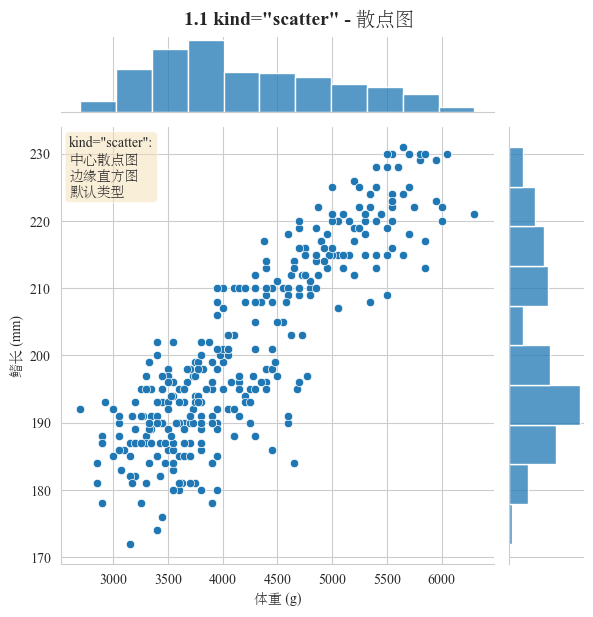

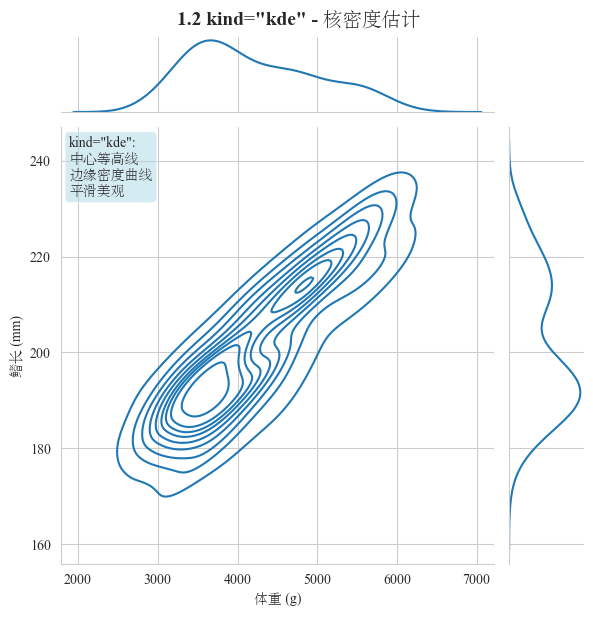

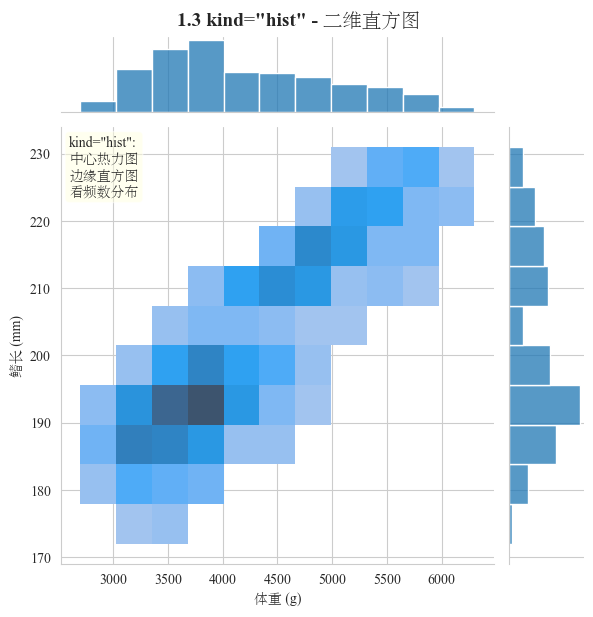

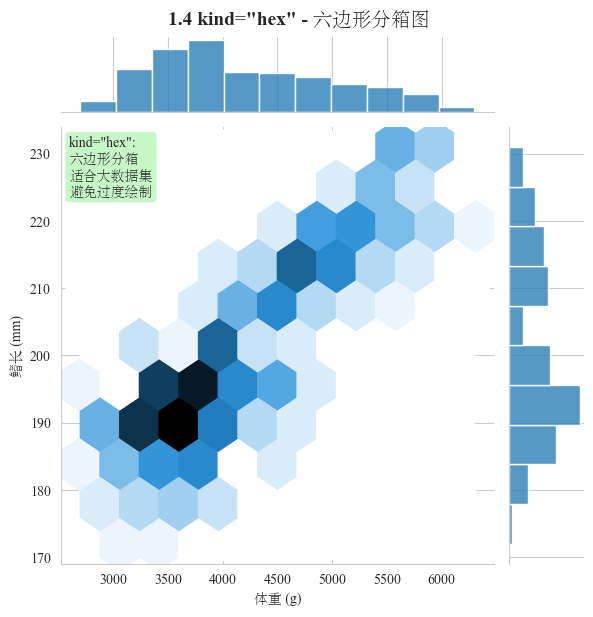

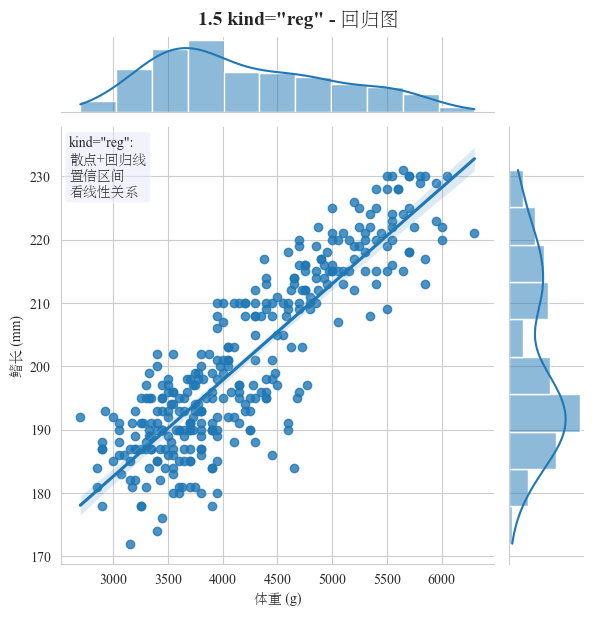

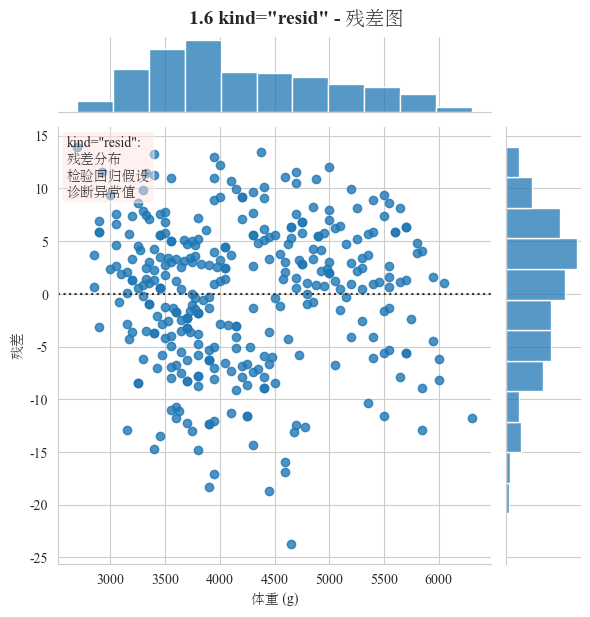

In [31]:
# ============================================================
# 画布 1: 6种kind类型演示
# ============================================================
print("画布 1: 展示6种图表类型 (kind参数)")  # 打印说明，介绍jointplot的kind参数功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 1.1 kind='scatter' ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
    kind='scatter',  # 设置图表类型为散点图
    height=6)  # 设置图表高度为6英寸
g.fig.suptitle('1.1 kind="scatter" - 散点图',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明散点图效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'kind="scatter":\n中心散点图\n边缘直方图\n默认类型',  # 说明kind=scatter的散点图特性，含边缘直方图
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='wheat',
              alpha=0.5))  # 圆角背景框，小麦色，透明度0.5
plt.show()  # 显示散点图及其边缘直方图

# ========== 1.2 kind='kde' ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长
    kind='kde',  # 设置图表类型为核密度估计
    height=6)  # 设置图表高度为6英寸
g.fig.suptitle('1.2 kind="kde" - 核密度估计',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明KDE效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'kind="kde":\n中心等高线\n边缘密度曲线\n平滑美观',  # 说明kind=kde的二维等高线及边缘密度曲线特性
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightblue',
              alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5
plt.show()  # 显示二维KDE图及其边缘密度曲线

# ========== 1.3 kind='hist' ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长
    kind='hist',  # 设置图表类型为二维直方图
    height=6)  # 设置图表高度为6英寸
g.fig.suptitle('1.3 kind="hist" - 二维直方图',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明二维直方图效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'kind="hist":\n中心热力图\n边缘直方图\n看频数分布',  # 说明kind=hist的热力图及边缘直方图特性
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightyellow',
              alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5
plt.show()  # 显示二维直方图及其边缘直方图

# ========== 1.4 kind='hex' ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长
    kind='hex',  # 设置图表类型为六边形分箱图
    height=6)  # 设置图表高度为6英寸
g.fig.suptitle('1.4 kind="hex" - 六边形分箱图',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明六边形分箱图效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'kind="hex":\n六边形分箱\n适合大数据集\n避免过度绘制',  # 说明kind=hex的六边形分箱特性
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightgreen',
              alpha=0.5))  # 圆角背景框，浅绿色，透明度0.5
plt.show()  # 显示六边形分箱图及其边缘直方图

# ========== 1.5 kind='reg' ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长
    kind='reg',  # 设置图表类型为回归图
    height=6)  # 设置图表高度为6英寸
g.fig.suptitle('1.5 kind="reg" - 回归图', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明回归图效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'kind="reg":\n散点+回归线\n置信区间\n看线性关系',  # 说明kind=reg的散点图加回归线及置信区间特性
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lavender',
              alpha=0.5))  # 圆角背景框，淡紫色，透明度0.5
plt.show()  # 显示回归图及其边缘直方图

# ========== 1.6 kind='resid' ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，y轴显示残差
    kind='resid',  # 设置图表类型为残差图
    height=6)  # 设置图表高度为6英寸
g.fig.suptitle('1.6 kind="resid" - 残差图',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明残差图效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '残差')  # 设置x轴标签为“体重 (g)”，y轴标签为“残差”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'kind="resid":\n残差分布\n检验回归假设\n诊断异常值',  # 说明kind=resid的残差图特性
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='mistyrose',
              alpha=0.5))  # 圆角背景框，薄雾玫瑰色，透明度0.5
plt.show()  # 显示残差图及其边缘直方图


画布 2: hue参数 - 分组展示
------------------------------------------------------------


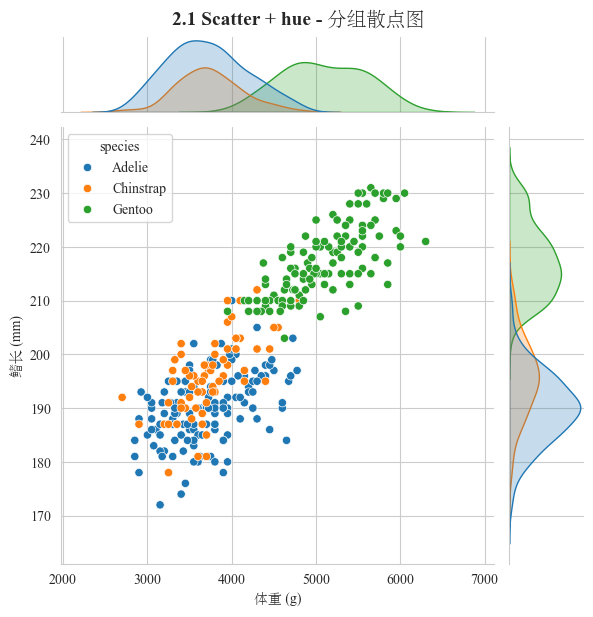

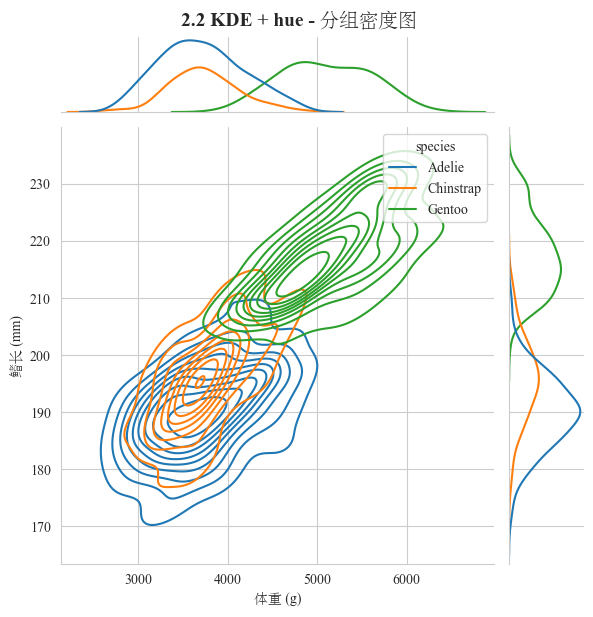

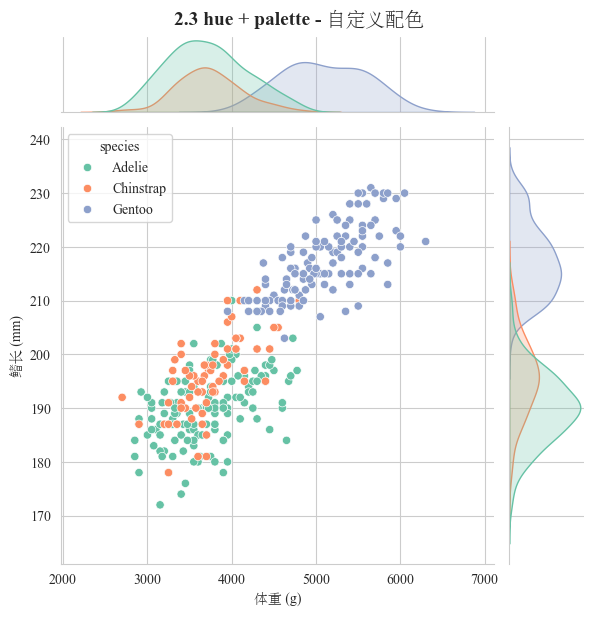

In [33]:
# ============================================================
# 画布 2: hue参数 - 分组展示
# ============================================================
print("\n画布 2: hue参数 - 分组展示")  # 打印说明，介绍hue参数的分组展示功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 2.1 scatter + hue ==========
g = sns.jointplot(data=penguins,  # 使用企鹅数据集
                  x='body_mass_g',  # x轴为体重
                  y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
                  hue='species',  # 按物种分组，自动分配不同颜色
                  kind='scatter',  # 设置图表类型为散点图
                  height=6)  # 设置图表高度为6英寸
g.fig.suptitle('2.1 Scatter + hue - 分组散点图', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明分组散点图效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
plt.show()  # 显示按物种分组的散点图及其边缘直方图

# ========== 2.2 kde + hue ==========
g = sns.jointplot(data=penguins,  # 使用企鹅数据集
                  x='body_mass_g',  # x轴为体重
                  y='flipper_length_mm',  # y轴为鳍长
                  hue='species',  # 按物种分组，自动分配不同颜色
                  kind='kde',  # 设置图表类型为核密度估计
                  height=6)  # 设置图表高度为6英寸
g.fig.suptitle('2.2 KDE + hue - 分组密度图', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明分组密度图效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
plt.show()  # 显示按物种分组的二维KDE图及其边缘密度曲线

# ========== 2.3 hue + palette ==========
g = sns.jointplot(data=penguins,  # 使用企鹅数据集
                  x='body_mass_g',  # x轴为体重
                  y='flipper_length_mm',  # y轴为鳍长
                  hue='species',  # 按物种分组
                  palette='Set2',  # 使用Set2调色板自定义颜色
                  kind='scatter',  # 设置图表类型为散点图
                  height=6)  # 设置图表高度为6英寸
g.fig.suptitle('2.3 hue + palette - 自定义配色', fontsize=14, fontweight='bold', y=1.02)  # 设置画布标题，说明自定义配色效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
plt.show()  # 显示使用自定义配色的分组散点图及其边缘直方图


画布 3: ratio参数 - 调整中心图和边缘图比例
------------------------------------------------------------


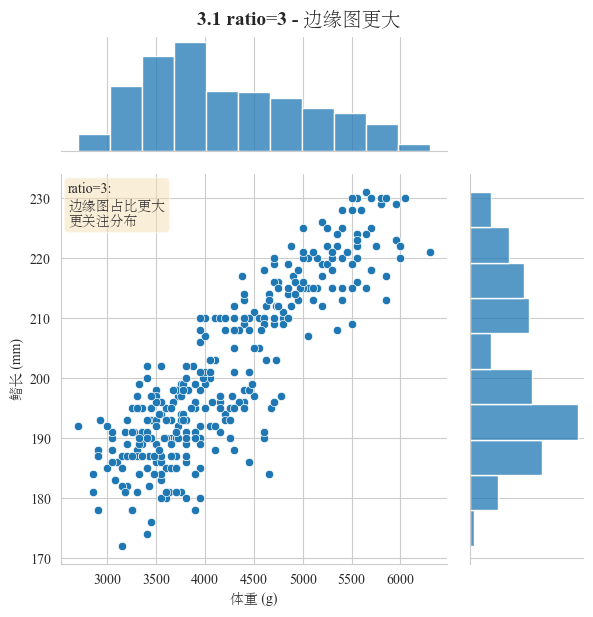

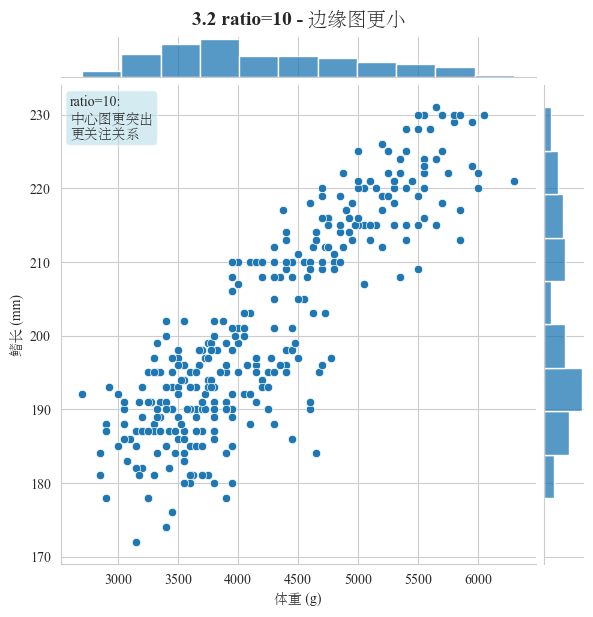

In [34]:
# ============================================================
# 画布 3: ratio参数 - 调整比例
# ============================================================
print("\n画布 3: ratio参数 - 调整中心图和边缘图比例")  # 打印说明，介绍ratio参数调整中心图与边缘图比例的功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 3.1 ratio=3 (默认约5) ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
    ratio=3,  # 设置中心图与边缘图高度比例为3（边缘图相对更大）
    height=6)  # 设置整个图表高度为6英寸
g.fig.suptitle('3.1 ratio=3 - 边缘图更大', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明ratio=3的边缘图放大效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'ratio=3:\n边缘图占比更大\n更关注分布',  # 说明ratio=3使边缘直方图更突出的效果
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='wheat',
              alpha=0.5))  # 圆角背景框，小麦色，透明度0.5
plt.show()  # 显示ratio=3的散点图及其边缘直方图

# ========== 3.2 ratio=10 ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长
    ratio=10,  # 设置中心图与边缘图高度比例为10（中心图更突出）
    height=6)  # 设置整个图表高度为6英寸
g.fig.suptitle('3.2 ratio=10 - 边缘图更小', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明ratio=10的中心图突出效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'ratio=10:\n中心图更突出\n更关注关系',  # 说明ratio=10使中心散点图更突出的效果
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightblue',
              alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5
plt.show()  # 显示ratio=10的散点图及其边缘直方图


画布 4: marginal_kws - 定制边缘图样式
------------------------------------------------------------


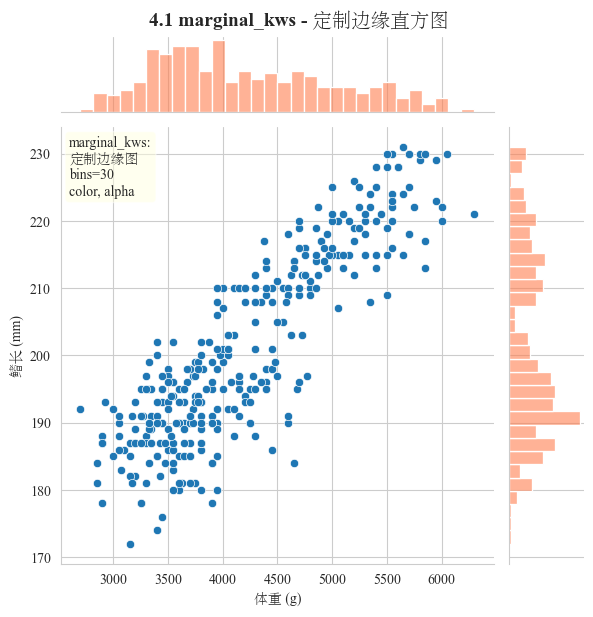

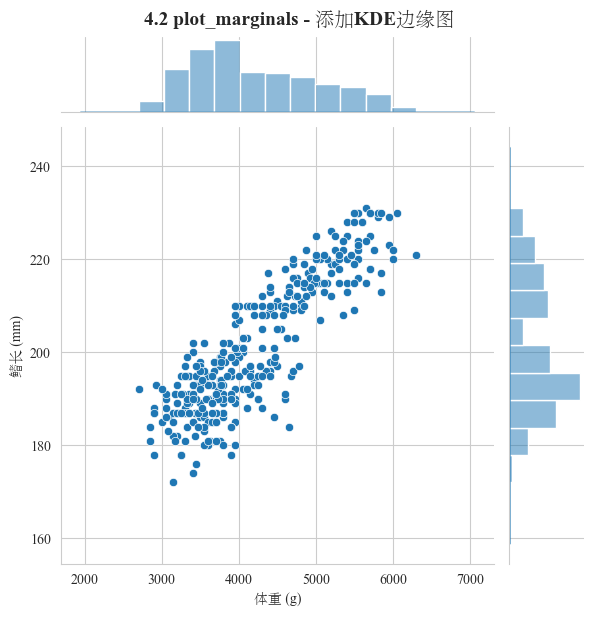

In [36]:
# ============================================================
# 画布 4: marginal_kws - 定制边缘图
# ============================================================
print("\n画布 4: marginal_kws - 定制边缘图样式")  # 打印说明，介绍marginal_kws参数定制边缘图样式的功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 4.1 调整边缘图bins ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
    marginal_kws=dict(bins=30, color='coral',
                      alpha=0.6),  # 定制边缘直方图：30个分箱，珊瑚色，透明度0.6
    height=6)  # 设置整个图表高度为6英寸
g.fig.suptitle('4.1 marginal_kws - 定制边缘直方图',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明定制边缘直方图效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'marginal_kws:\n定制边缘图\nbins=30\ncolor, alpha',  # 说明marginal_kws定制边缘直方图的参数效果
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightyellow',
              alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5
plt.show()  # 显示散点图及定制的边缘直方图

# ========== 4.2 边缘KDE参数 ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长
    kind='scatter',  # 设置图表类型为散点图
    marginal_kws=dict(fill=True, alpha=0.5),  # 定制边缘图为填充样式，透明度0.5
    height=6)  # 设置整个图表高度为6英寸
# 手动添加边缘KDE
g.plot_marginals(sns.kdeplot, fill=True,
                 alpha=0.5)  # 使用plot_marginals添加边缘KDE图，填充曲线区域，透明度0.5
g.fig.suptitle('4.2 plot_marginals - 添加KDE边缘图',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明添加KDE边缘图效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
plt.show()  # 显示散点图及定制的边缘KDE图


画布 5: joint_kws - 定制中心图样式
------------------------------------------------------------


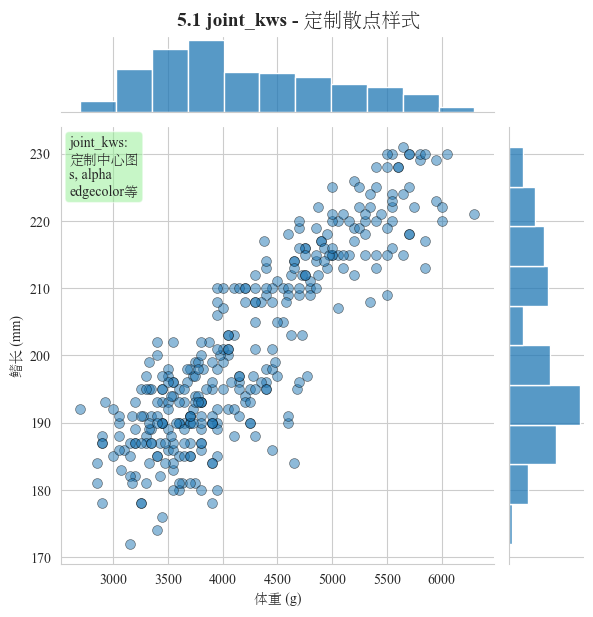

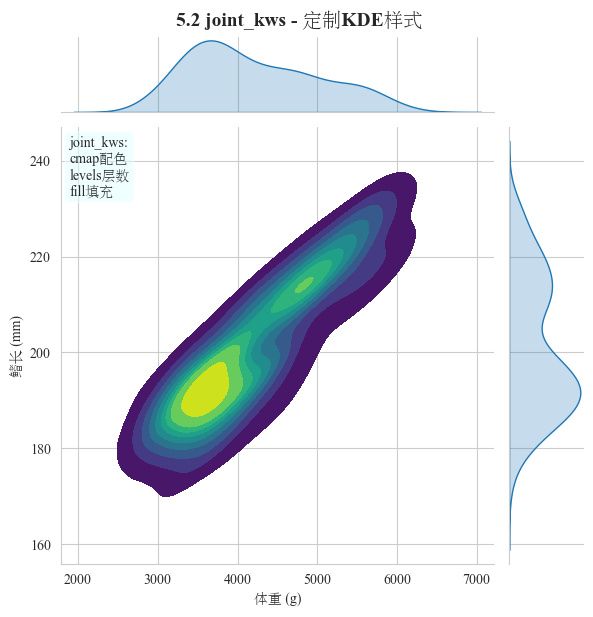

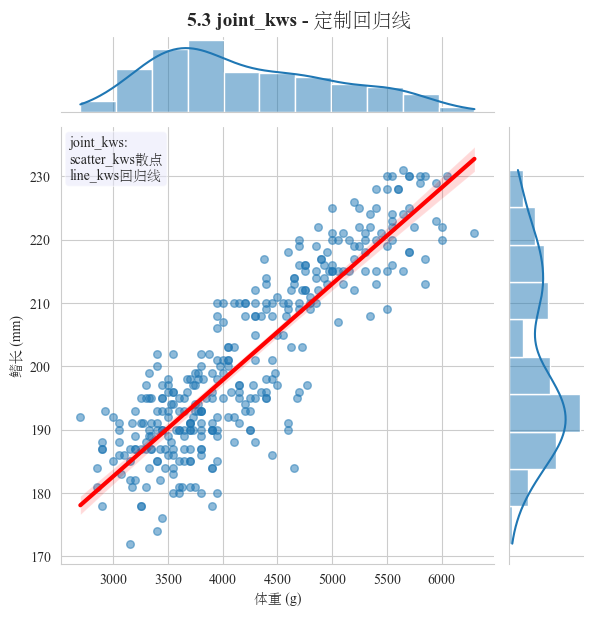

In [37]:
# ============================================================
# 画布 5: joint_kws - 定制中心图
# ============================================================
print("\n画布 5: joint_kws - 定制中心图样式")  # 打印说明，介绍joint_kws参数定制中心图样式的功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 5.1 定制散点样式 ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
    joint_kws=dict(
        s=50,  # 设置散点大小为50
        alpha=0.5,  # 设置散点透明度为0.5
        edgecolor='black',  # 设置散点边框颜色为黑色
        linewidth=0.5),  # 设置散点边框线宽为0.5
    height=6)  # 设置整个图表高度为6英寸
g.fig.suptitle('5.1 joint_kws - 定制散点样式',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明定制散点样式效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'joint_kws:\n定制中心图\ns, alpha\nedgecolor等',  # 说明joint_kws定制散点图参数的效果
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightgreen',
              alpha=0.5))  # 圆角背景框，浅绿色，透明度0.5
plt.show()  # 显示定制散点样式的散点图及其边缘直方图

# ========== 5.2 定制KDE样式 ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长
    kind='kde',  # 设置图表类型为核密度估计
    joint_kws=dict(
        fill=True,  # 填充KDE等高线区域
        cmap='viridis',  # 使用viridis配色方案
        levels=10),  # 设置等高线级别为10
    height=6)  # 设置整个图表高度为6英寸
g.fig.suptitle('5.2 joint_kws - 定制KDE样式',
               fontsize=14,
               fontweight='bold',
               y=1.02)  # 设置画布标题，说明定制KDE样式效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'joint_kws:\ncmap配色\nlevels层数\nfill填充',  # 说明joint_kws定制KDE图参数的效果
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightcyan',
              alpha=0.5))  # 圆角背景框，浅青色，透明度0.5
plt.show()  # 显示定制KDE样式的二维KDE图及其边缘密度曲线

# ========== 5.3 定制回归线样式 ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长
    kind='reg',  # 设置图表类型为回归图
    joint_kws=dict(
        scatter_kws={
            'alpha': 0.5,  # 设置散点透明度为0.5
            's': 30
        },  # 设置散点大小为30
        line_kws={
            'color': 'red',  # 设置回归线颜色为红色
            'linewidth': 3
        }),  # 设置回归线宽度为3
    height=6)  # 设置整个图表高度为6英寸
g.fig.suptitle('5.3 joint_kws - 定制回归线', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明定制回归线效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'joint_kws:\nscatter_kws散点\nline_kws回归线',  # 说明joint_kws定制散点和回归线的参数效果
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lavender',
              alpha=0.5))  # 圆角背景框，淡紫色，透明度0.5
plt.show()  # 显示定制回归线样式的回归图及其边缘直方图


画布 6: 添加统计信息和注释
------------------------------------------------------------


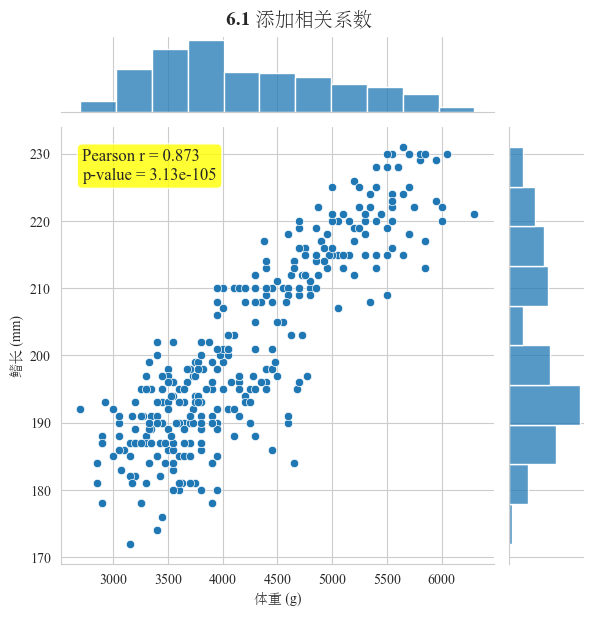

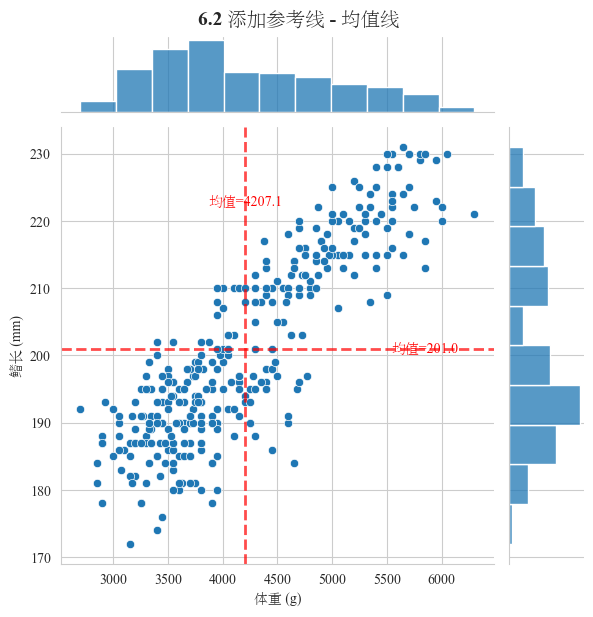

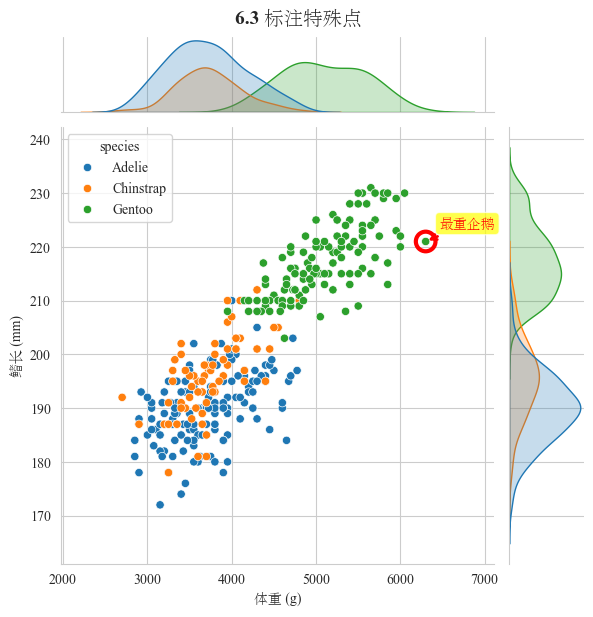

In [38]:
# ============================================================
# 画布 6: 添加统计信息
# ============================================================
print("\n画布 6: 添加统计信息和注释")  # 打印说明，介绍添加统计信息和注释的功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 6.1 添加相关系数 ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
    kind='scatter',  # 设置图表类型为散点图
    height=6)  # 设置整个图表高度为6英寸
# 计算相关系数
from scipy import stats  # 导入scipy.stats模块以计算皮尔逊相关系数

r, p = stats.pearsonr(penguins['body_mass_g'],
                      penguins['flipper_length_mm'])  # 计算体重和鳍长的皮尔逊相关系数r和p值
# 添加文本
g.ax_joint.text(
    0.05,  # 在主图左上角添加文本框，x坐标0.05
    0.95,  # y坐标0.95，接近顶部
    f'Pearson r = {r:.3f}\np-value = {p:.2e}',  # 显示相关系数（保留3位小数）和p值（科学计数法，2位小数）
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=12,  # 字体大小12
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='yellow',
              alpha=0.8))  # 圆角背景框，黄色，透明度0.8
g.fig.suptitle('6.1 添加相关系数', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明添加相关系数效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
plt.show()  # 显示散点图及其边缘直方图，包含相关系数注释

# ========== 6.2 添加参考线 ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长
    kind='scatter',  # 设置图表类型为散点图
    height=6)  # 设置整个图表高度为6英寸
# 添加均值线
mean_x = penguins['body_mass_g'].mean()  # 计算体重的均值
mean_y = penguins['flipper_length_mm'].mean()  # 计算鳍长的均值
g.ax_joint.axvline(
    x=mean_x,  # 绘制垂直均值线
    color='red',  # 线条颜色为红色
    linestyle='--',  # 线条样式为虚线
    linewidth=2,  # 线条宽度为2
    alpha=0.7)  # 线条透明度为0.7
g.ax_joint.axhline(
    y=mean_y,  # 绘制水平均值线
    color='red',  # 线条颜色为红色
    linestyle='--',  # 线条样式为虚线
    linewidth=2,  # 线条宽度为2
    alpha=0.7)  # 线条透明度为0.7
g.ax_joint.text(
    mean_x,  # 在x轴均值线位置添加文本
    g.ax_joint.get_ylim()[1] * 0.95,  # 文本位于y轴范围顶部95%处
    f'均值={mean_x:.1f}',  # 显示x轴均值，保留1位小数
    ha='center',  # 水平居中对齐
    color='red',  # 文本颜色为红色
    fontsize=10)  # 字体大小10
g.ax_joint.text(
    g.ax_joint.get_xlim()[1] * 0.95,  # 在y轴均值线位置添加文本，x坐标为x轴范围95%处
    mean_y,  # 文本位于y轴均值处
    f'均值={mean_y:.1f}',  # 显示y轴均值，保留1位小数
    va='center',  # 垂直居中对齐
    ha='right',  # 水平右对齐
    color='red',  # 文本颜色为红色
    fontsize=10)  # 字体大小10
g.fig.suptitle('6.2 添加参考线 - 均值线', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明添加均值线效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
plt.show()  # 显示散点图及其边缘直方图，包含均值参考线和注释

# ========== 6.3 标注特殊点 ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长
    hue='species',  # 按物种分组，自动分配不同颜色
    height=6)  # 设置整个图表高度为6英寸
# 找到极端值
max_mass_idx = penguins['body_mass_g'].idxmax()  # 找到体重最大值的索引
max_mass_row = penguins.loc[max_mass_idx]  # 获取体重最大值对应的数据行
g.ax_joint.scatter(
    [max_mass_row['body_mass_g']],  # 绘制最重企鹅的标记点
    [max_mass_row['flipper_length_mm']],  # y坐标为对应鳍长
    s=200,  # 标记点大小为200
    facecolors='none',  # 填充颜色为空（空心）
    edgecolors='red',  # 边框颜色为红色
    linewidths=3)  # 边框线宽为3
g.ax_joint.annotate(
    '最重企鹅',  # 添加注释文本“最重企鹅”
    xy=(max_mass_row['body_mass_g'],
        max_mass_row['flipper_length_mm']),  # 注释点坐标
    xytext=(10, 10),  # 文本偏移量（右上10个单位）
    textcoords='offset points',  # 使用偏移坐标系
    fontsize=10,  # 字体大小10
    color='red',  # 文本颜色为红色
    bbox=dict(boxstyle='round', facecolor='yellow',
              alpha=0.7),  # 圆角背景框，黄色，透明度0.7
    arrowprops=dict(arrowstyle='->', color='red', lw=2))  # 设置箭头样式，红色，线宽2
g.fig.suptitle('6.3 标注特殊点', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明标注特殊点效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
plt.show()  # 显示分组散点图及其边缘直方图，包含最重企鹅的标注


画布 7: 不同数据特征的应用
------------------------------------------------------------


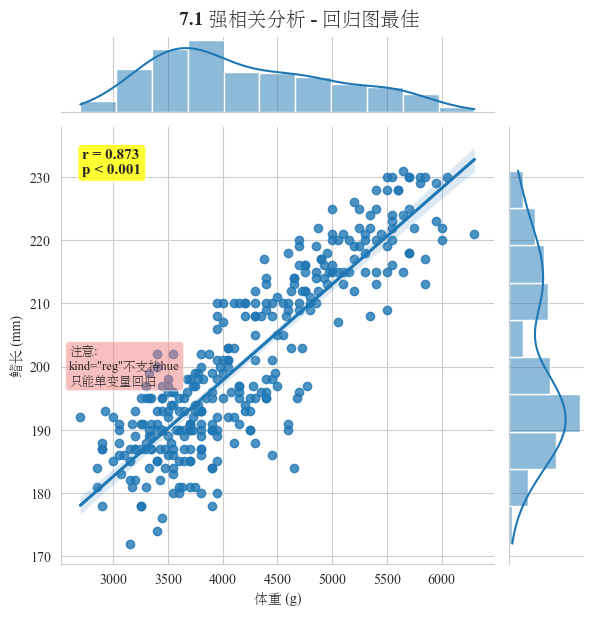

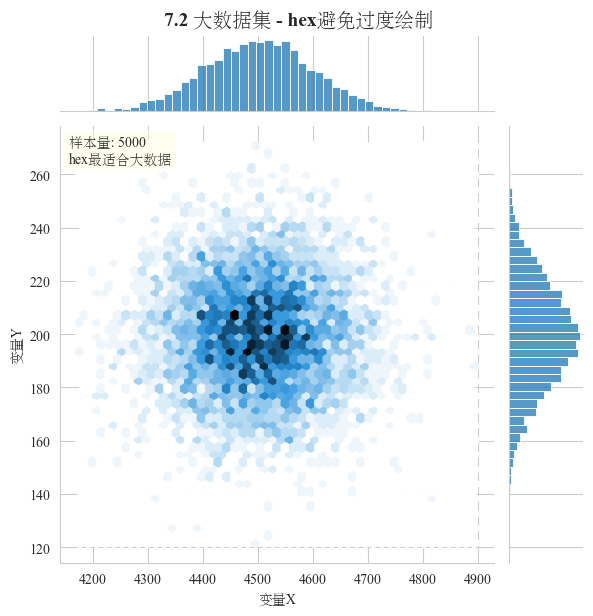

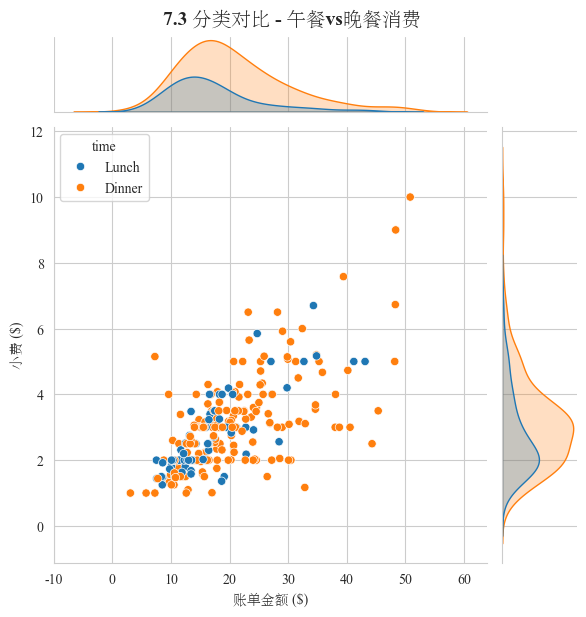

In [39]:
# ============================================================
# 画布 7: 不同数据特征的应用
# ============================================================
print("\n画布 7: 不同数据特征的应用")  # 打印说明，介绍针对不同数据特征的应用
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 7.1 强相关数据 ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
    kind='reg',  # 设置图表类型为回归图
    height=6)  # 设置整个图表高度为6英寸
# 添加相关系数
r, p = stats.pearsonr(penguins['body_mass_g'],
                      penguins['flipper_length_mm'])  # 计算体重和鳍长的皮尔逊相关系数r和p值
g.ax_joint.text(
    0.05,  # 在主图左上角添加文本框，x坐标0.05
    0.95,  # y坐标0.95，接近顶部
    f'r = {r:.3f}\np < 0.001',  # 显示相关系数（保留3位小数）和p值（固定显示<0.001）
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=11,  # 字体大小11
    fontweight='bold',  # 字体加粗
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='yellow',
              alpha=0.8))  # 圆角背景框，黄色，透明度0.8
g.fig.suptitle('7.1 强相关分析 - 回归图最佳', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明回归图适合强相关数据，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左侧添加文本框，x坐标0.02
    0.50,  # y坐标0.50，垂直居中
    '注意:\nkind="reg"不支持hue\n只能单变量回归',  # 说明kind=reg的限制
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=9,  # 字体大小9
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightcoral',
              alpha=0.5))  # 圆角背景框，浅珊瑚色，透明度0.5
plt.show()  # 显示回归图及其边缘直方图，包含相关系数和注意事项注释

# ========== 7.2 大数据集 - hex ==========
# 创建大数据集
np.random.seed(42)  # 设置随机种子以确保结果可重复
large_data = pd.DataFrame({
    'x': np.random.randn(5000) * 100 + 4500,  # 生成5000个x值，标准正态分布缩放后平移
    'y': np.random.randn(5000) * 20 + 200  # 生成5000个y值，标准正态分布缩放后平移
})
g = sns.jointplot(
    data=large_data,  # 使用生成的大数据集
    x='x',  # x轴为变量x
    y='y',  # y轴为变量y
    kind='hex',  # 设置图表类型为六边形分箱图
    height=6)  # 设置整个图表高度为6英寸
g.fig.suptitle('7.2 大数据集 - hex避免过度绘制', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明六边形分箱图适合大数据集，字体大小14，加粗
g.set_axis_labels('变量X', '变量Y')  # 设置x轴标签为“变量X”，y轴标签为“变量Y”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    f'样本量: {len(large_data)}\nhex最适合大数据',  # 显示样本量并说明hex图适合大数据
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightyellow',
              alpha=0.5))  # 圆角背景框，浅黄色，透明度0.5
plt.show()  # 显示六边形分箱图及其边缘直方图

# ========== 7.3 分类对比 ==========
g = sns.jointplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴为账单金额
    y='tip',  # y轴为小费金额
    hue='time',  # 按时间（午餐/晚餐）分组，自动分配不同颜色
    kind='scatter',  # 设置图表类型为散点图
    height=6)  # 设置整个图表高度为6英寸
g.fig.suptitle('7.3 分类对比 - 午餐vs晚餐消费', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明分类对比效果，字体大小14，加粗
g.set_axis_labels('账单金额 ($)', '小费 ($)')  # 设置x轴标签为“账单金额 ($)”，y轴标签为“小费 ($)”
plt.show()  # 显示按时间分组的散点图及其边缘直方图


画布 8: space参数 - 调整中心图和边缘图间距
------------------------------------------------------------


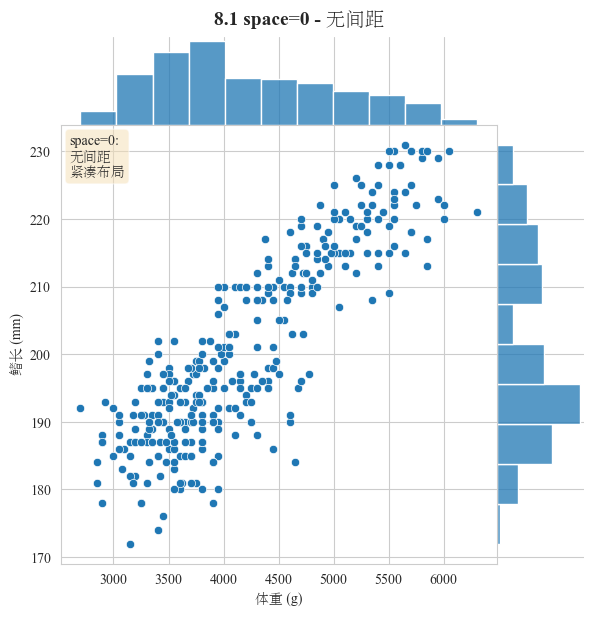

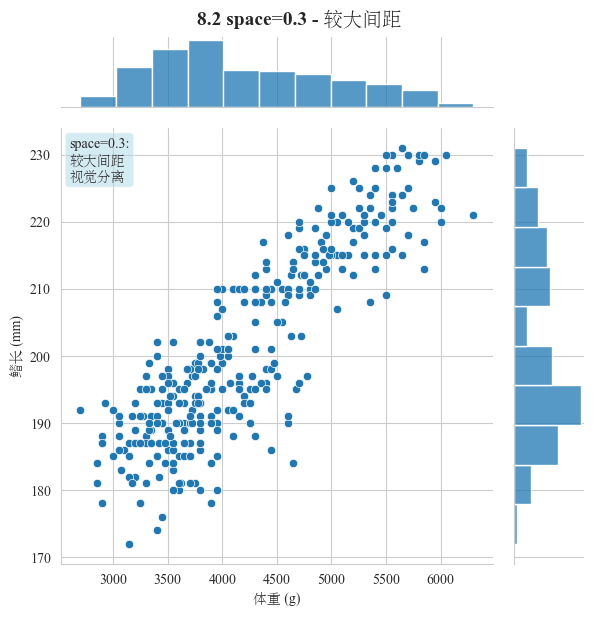

In [40]:
# ============================================================
# 画布 8: space参数 - 调整间距
# ============================================================
print("\n画布 8: space参数 - 调整中心图和边缘图间距")  # 打印说明，介绍space参数调整中心图与边缘图间距的功能
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 8.1 space=0 (无间距) ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
    space=0,  # 设置中心图与边缘图间距为0（无间距）
    height=6)  # 设置整个图表高度为6英寸
g.fig.suptitle('8.1 space=0 - 无间距', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明无间距效果，字体大小14，加粗，标题位置略高于默认
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'space=0:\n无间距\n紧凑布局',  # 说明space=0的紧凑布局效果
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='wheat',
              alpha=0.5))  # 圆角背景框，小麦色，透明度0.5
plt.show()  # 显示无间距的散点图及其边缘直方图

# ========== 8.2 space=0.3 (较大间距) ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长
    space=0.3,  # 设置中心图与边缘图间距为0.3（较大间距）
    height=6)  # 设置整个图表高度为6英寸
g.fig.suptitle('8.2 space=0.3 - 较大间距', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明较大间距效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”
g.ax_joint.text(
    0.02,  # 在主图左上角添加文本框，x坐标0.02
    0.98,  # y坐标0.98，顶部对齐
    'space=0.3:\n较大间距\n视觉分离',  # 说明space=0.3的视觉分离效果
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=10,  # 字体大小10
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightblue',
              alpha=0.5))  # 圆角背景框，浅蓝色，透明度0.5
plt.show()  # 显示较大间距的散点图及其边缘直方图


画布 9: 综合美化案例
------------------------------------------------------------


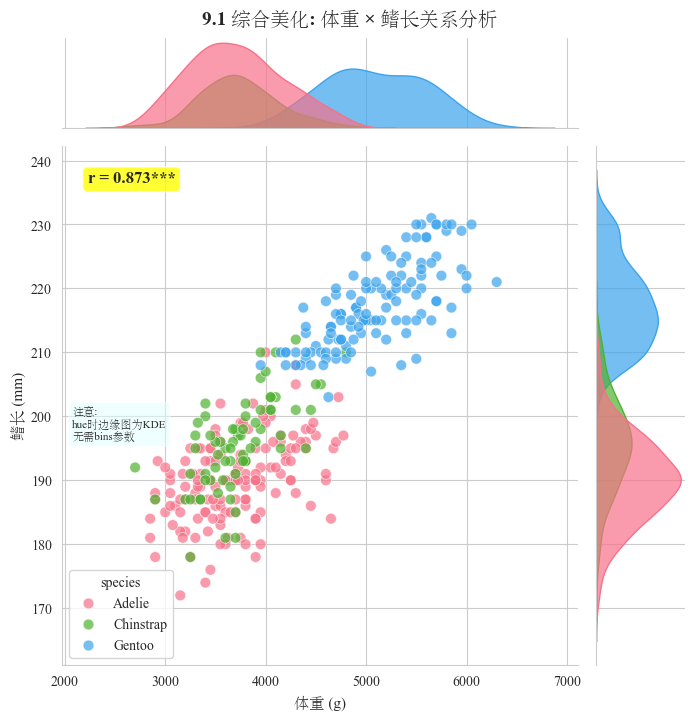

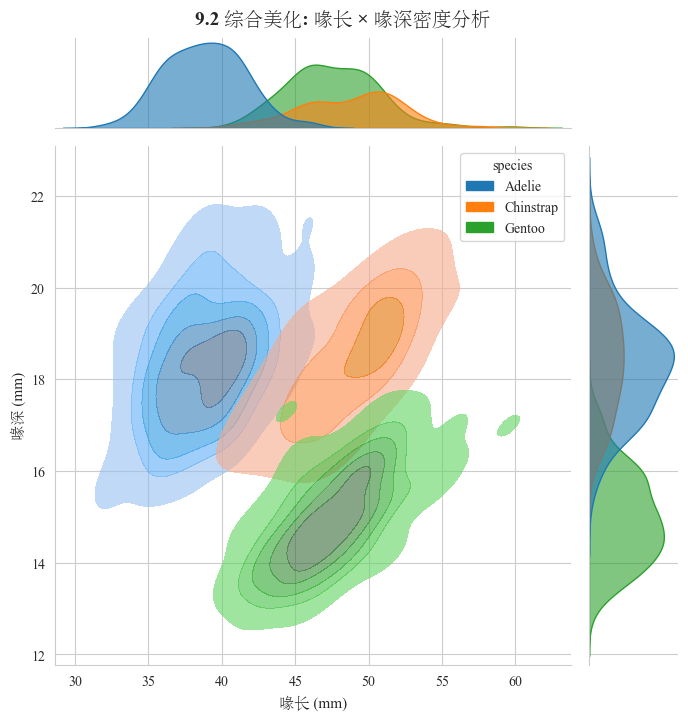

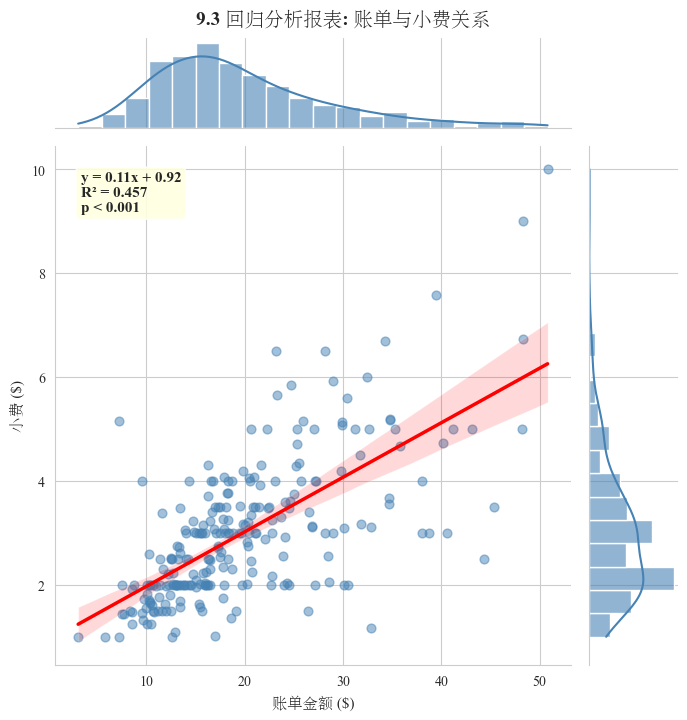

In [42]:
# ============================================================
# 画布 9: 综合美化案例
# ============================================================
print("\n画布 9: 综合美化案例")  # 打印说明，介绍综合美化案例
print("-" * 60)  # 打印60个短横线作为分隔线

# ========== 9.1 精美散点图 ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='body_mass_g',  # x轴为体重
    y='flipper_length_mm',  # y轴为鳍长，绘制二维分布
    hue='species',  # 按物种分组，自动分配不同颜色
    palette='husl',  # 使用husl调色板，色彩柔和且区分度高
    height=7,  # 设置整个图表高度为7英寸
    joint_kws=dict(
        s=60,  # 设置散点大小为60
        alpha=0.7,  # 设置散点透明度为0.7
        edgecolor='white',  # 设置散点边框颜色为白色
        linewidth=0.5),  # 设置散点边框线宽为0.5
    marginal_kws=dict(alpha=0.7, fill=True))  # 定制边缘图为填充KDE，透明度0.7
# 计算相关系数
r, p = stats.pearsonr(penguins['body_mass_g'],
                      penguins['flipper_length_mm'])  # 计算体重和鳍长的皮尔逊相关系数r和p值
g.ax_joint.text(
    0.05,  # 在主图左上角添加文本框，x坐标0.05
    0.95,  # y坐标0.95，接近顶部
    f'r = {r:.3f}***',  # 显示相关系数（保留3位小数），***表示显著性
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=12,  # 字体大小12
    fontweight='bold',  # 字体加粗
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='yellow',
              alpha=0.8))  # 圆角背景框，黄色，透明度0.8
g.fig.suptitle('9.1 综合美化: 体重 × 鳍长关系分析', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明美化散点图效果，字体大小14，加粗
g.set_axis_labels('体重 (g)', '鳍长 (mm)',
                  fontsize=11)  # 设置x轴标签为“体重 (g)”，y轴标签为“鳍长 (mm)”，字体大小11
g.ax_joint.text(
    0.02,  # 在主图左侧添加文本框，x坐标0.02
    0.50,  # y坐标0.50，垂直居中
    '注意:\nhue时边缘图为KDE\n无需bins参数',  # 说明hue参数下边缘图自动为KDE
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=8,  # 字体大小8
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightcyan',
              alpha=0.5))  # 圆角背景框，浅青色，透明度0.5
plt.show()  # 显示美化的分组散点图及边缘KDE图

# ========== 9.2 精美KDE图 ==========
g = sns.jointplot(
    data=penguins,  # 使用企鹅数据集
    x='bill_length_mm',  # x轴为喙长
    y='bill_depth_mm',  # y轴为喙深
    hue='species',  # 按物种分组，自动分配不同颜色
    kind='kde',  # 设置图表类型为核密度估计
    height=7,  # 设置整个图表高度为7英寸
    joint_kws=dict(fill=True, alpha=0.6, levels=6),  # 定制中心KDE：填充，透明度0.6，6条等高线
    marginal_kws=dict(fill=True, alpha=0.6))  # 定制边缘KDE：填充，透明度0.6
g.fig.suptitle('9.2 综合美化: 喙长 × 喙深密度分析', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明美化KDE图效果，字体大小14，加粗
g.set_axis_labels('喙长 (mm)', '喙深 (mm)',
                  fontsize=11)  # 设置x轴标签为“喙长 (mm)”，y轴标签为“喙深 (mm)”，字体大小11
plt.show()  # 显示美化的分组KDE图及边缘KDE图

# ========== 9.3 回归分析报表 ==========
g = sns.jointplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴为账单金额
    y='tip',  # y轴为小费金额
    kind='reg',  # 设置图表类型为回归图
    height=7,  # 设置整个图表高度为7英寸
    joint_kws=dict(
        scatter_kws={
            'alpha': 0.5,  # 设置散点透明度为0.5
            's': 40,  # 设置散点大小为40
            'color': 'steelblue'
        },  # 设置散点颜色为钢蓝色
        line_kws={
            'color': 'red',  # 设置回归线颜色为红色
            'linewidth': 2.5
        }),  # 设置回归线宽度为2.5
    marginal_kws=dict(bins=20, color='steelblue',
                      alpha=0.6))  # 定制边缘直方图：20个分箱，钢蓝色，透明度0.6
# 添加回归方程
from scipy.stats import linregress  # 导入linregress用于线性回归分析

slope, intercept, r_value, p_value, std_err = linregress(
    tips['total_bill'], tips['tip'])  # 计算账单与小费的线性回归参数
g.ax_joint.text(
    0.05,  # 在主图左上角添加文本框，x坐标0.05
    0.95,  # y坐标0.95，接近顶部
    f'y = {slope:.2f}x + {intercept:.2f}\nR² = {r_value**2:.3f}\np < 0.001',  # 显示回归方程（斜率、截距保留2位小数），R²（保留3位小数），p值固定显示<0.001
    transform=g.ax_joint.transAxes,  # 使用主图相对坐标系
    fontsize=11,  # 字体大小11
    fontweight='bold',  # 字体加粗
    verticalalignment='top',  # 文本顶部对齐
    bbox=dict(boxstyle='round', facecolor='lightyellow',
              alpha=0.9))  # 圆角背景框，浅黄色，透明度0.9
g.fig.suptitle('9.3 回归分析报表: 账单与小费关系', fontsize=14, fontweight='bold',
               y=1.02)  # 设置画布标题，说明回归分析报表效果，字体大小14，加粗
g.set_axis_labels('账单金额 ($)', '小费 ($)',
                  fontsize=11)  # 设置x轴标签为“账单金额 ($)”，y轴标签为“小费 ($)”，字体大小11
plt.show()  # 显示美化的回归图及边缘直方图，包含回归方程

In [43]:
# ============================================================
# 打印完整参数总结
# ============================================================
print("\n" + "="*60)
print("Seaborn jointplot 核心参数总结 (v0.13.2+)")
print("="*60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 两个数值变量(必需)
   - hue: 分组变量
   - kind: 图表类型 ⭐⭐⭐
     * 'scatter': 散点图(默认)
     * 'kde': 核密度估计
     * 'hist': 二维直方图
     * 'hex': 六边形分箱图
     * 'reg': 回归图
     * 'resid': 残差图

2. 布局控制: ⭐⭐⭐
   - height: 图表高度(英寸)
   - ratio: 中心图与边缘图的比例(默认5)
     * 小值: 边缘图更大
     * 大值: 中心图更突出
   - space: 中心图和边缘图间距(默认0.2)
     * 0: 无间距
     * >0: 有间距

3. 定制参数: ⭐⭐⭐
   - joint_kws: 中心图参数字典
     * scatter: s, alpha, edgecolor等
     * kde: fill, cmap, levels等
     * reg: scatter_kws, line_kws等
   - marginal_kws: 边缘图参数字典
     * 无hue时: bins, color, alpha等
     * 有hue时: alpha, fill等 (自动用KDE)⭐
     ⚠️ 使用hue时边缘图自动变为KDE，不能用bins参数！

4. 样式参数:
   - color: 单一颜色
   - palette: 调色板(配合hue)
   - alpha: 透明度

5. 其他参数:
   - xlim, ylim: 坐标轴范围
   - dropna: 删除缺失值(True/False，默认False)

6. JointGrid方法:
   - plot(): 绘制图表
   - plot_joint(): 仅绘制中心图
   - plot_marginals(): 仅绘制边缘图
   - set_axis_labels(): 设置轴标签
   - refline(): 添加参考线

7. 六种kind的特点: ⭐⭐⭐
   ┌──────────┬─────────────┬─────────────┬─────────────┬──────────┐
   │  Kind    │  中心图     │  边缘图     │  适用场景   │ 支持hue  │
   ├──────────┼─────────────┼─────────────┼─────────────┼──────────┤
   │ scatter  │  散点       │  直方图     │  通用探索   │    ✓     │
   │ kde      │  等高线     │  密度曲线   │  密度分析   │    ✓     │
   │ hist     │  热力图     │  直方图     │  频数统计   │    ✓     │
   │ hex      │  六边形     │  直方图     │  大数据集   │    ✓     │
   │ reg      │  回归线     │  直方图     │  线性关系   │    ✗     │
   │ resid    │  残差图     │  直方图     │  模型诊断   │    ✗     │
   └──────────┴─────────────┴─────────────┴─────────────┴──────────┘
   
   ⚠️ 重要: kind='reg'和'resid'不支持hue参数！

8. kind选择建议:
   - 探索关系 → scatter(默认)
   - 数据量大(>1000) → hex
   - 密度分析 → kde
   - 线性关系 → reg
   - 频数统计 → hist
   - 回归诊断 → resid

9. ratio参数建议:
   - 关注分布 → 3-4 (边缘图大)
   - 关注关系 → 8-10 (中心图大)
   - 平衡展示 → 5 (默认)

10. 组合使用技巧:
   - scatter + hue: 分组散点
   - kde + hue: 分组密度
   - reg: 自带回归分析
   - plot_marginals(): 自定义边缘图

11. 添加信息技巧: ⭐⭐⭐
   - ax_joint.text(): 添加文本
   - ax_joint.axvline/axhline(): 参考线
   - annotate(): 标注特殊点
   - 计算相关系数显示
   - 添加回归方程

12. 边缘图自动选择: ⭐⭐⭐
   - 无hue参数 → 边缘图为直方图
     * marginal_kws可用: bins, color等
   - 有hue参数 → 边缘图为KDE
     * marginal_kws可用: alpha, fill等
     * 不能用bins参数！

13. Jointplot vs 其他函数:
   优势:
   ✓ 一步生成联合图+边缘图
   ✓ 自动布局，无需手动调整
   ✓ 多种kind快速切换
   ✓ 内置统计功能(reg)
   
   劣势:
   ✗ 灵活性不如手动组合
   ✗ 只能显示两个变量
   ✗ 不支持col/row分面

13. 使用场景: ⭐⭐⭐
   ✓ 探索两变量关系
   ✓ 检查线性相关性
   ✓ 查看联合分布
   ✓ 识别异常值
   ✓ 回归分析可视化
   ✓ 论文配图

14. 最佳实践:
   ⭐ 选择合适的kind
   ⭐ 数据量大用hex
   ⭐ 添加相关系数
   ⭐ 调整ratio突出重点
   ⭐ 使用hue对比分组
   ⭐ joint_kws精细定制
   ⭐ 添加参考线辅助解读

15. 常见组合:
   - scatter + 相关系数: 快速分析
   - kde + hue: 分组密度对比
   - reg + 回归方程: 回归报表
   - hex: 大数据探索
   - resid: 模型诊断

16. 与pairplot对比:
   - jointplot: 单对变量深入分析
   - pairplot: 多对变量概览
   - jointplot更详细，pairplot更全面

17. 典型工作流:
   1. scatter快速查看关系
   2. 添加hue分组对比
   3. 选择合适kind深入分析
   4. 调整ratio和space优化布局
   5. 使用joint_kws精细定制
   6. 添加统计信息(相关系数等)
   7. 完成精美可视化

19. 注意事项:
   ⚠ jointplot会创建新figure，无法用ax参数
   ⚠ 与displot/catplot一样是Figure-level
   ⚠ 只能展示两个变量的关系
   ⚠ hex需要matplotlib支持
   ⚠ kind='reg'和'resid'不支持hue参数！⭐
   ⚠ 如需分组回归，使用lmplot代替
   ⚠ 使用hue时边缘图自动变KDE，marginal_kws不能用bins！⭐⭐
""")

print("\n" + "="*60)
print("Jointplot教程完成！")
print("="*60)
print("✓ 展示了6种kind类型")
print("✓ 演示了所有核心参数")
print("✓ 提供了9组综合应用案例")
print("✓ 包含完整的参数对比表")
print("\nJointplot是两变量关系分析的最佳工具！")
print("\n🎉 恭喜！所有Seaborn教程完成！🎉")


Seaborn jointplot 核心参数总结 (v0.13.2+)

1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 两个数值变量(必需)
   - hue: 分组变量
   - kind: 图表类型 ⭐⭐⭐
     * 'scatter': 散点图(默认)
     * 'kde': 核密度估计
     * 'hist': 二维直方图
     * 'hex': 六边形分箱图
     * 'reg': 回归图
     * 'resid': 残差图

2. 布局控制: ⭐⭐⭐
   - height: 图表高度(英寸)
   - ratio: 中心图与边缘图的比例(默认5)
     * 小值: 边缘图更大
     * 大值: 中心图更突出
   - space: 中心图和边缘图间距(默认0.2)
     * 0: 无间距
     * >0: 有间距

3. 定制参数: ⭐⭐⭐
   - joint_kws: 中心图参数字典
     * scatter: s, alpha, edgecolor等
     * kde: fill, cmap, levels等
     * reg: scatter_kws, line_kws等
   - marginal_kws: 边缘图参数字典
     * 无hue时: bins, color, alpha等
     * 有hue时: alpha, fill等 (自动用KDE)⭐
     ⚠️ 使用hue时边缘图自动变为KDE，不能用bins参数！

4. 样式参数:
   - color: 单一颜色
   - palette: 调色板(配合hue)
   - alpha: 透明度

5. 其他参数:
   - xlim, ylim: 坐标轴范围
   - dropna: 删除缺失值(True/False，默认False)

6. JointGrid方法:
   - plot(): 绘制图表
   - plot_joint(): 仅绘制中心图
   - plot_marginals(): 仅绘制边缘图
   - set_axis_labels(): 设置轴标签
   - refline(): 添加参考线

7. 六种kind的特点: ⭐⭐⭐
   ┌─────